In [1]:
import pathlib, requests
from tqdm import tqdm

def download_url_list(urls, out_dir="okx_raw", chunk=1024*1024):
    out_dir = pathlib.Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    for url in urls:
        url = url.strip()
        if not url:
            continue

        fname = url.split("?")[0].split("/")[-1]
        fpath = out_dir / fname
        if fpath.exists() and fpath.stat().st_size > 0:
            print("skip exists:", fpath.name)
            continue

        with requests.get(url, stream=True, timeout=60) as r:
            r.raise_for_status()
            total = int(r.headers.get("Content-Length", "0"))
            pbar = tqdm(total=total, unit="B", unit_scale=True, desc=fname)
            with open(fpath, "wb") as f:
                for b in r.iter_content(chunk_size=chunk):
                    if b:
                        f.write(b)
                        pbar.update(len(b))
            pbar.close()

# usage
urls = [
    # paste OKX download URLs here
]
download_url_list(urls, out_dir="okx_raw")

In [2]:
import json, time, random
from pathlib import Path

import pandas as pd
import requests

OKX_BASE = "https://www.okx.com"
HIST = "/api/v5/market/history-candles"  # public endpoint  [oai_citation:4‡OKX Europe](https://my.okx.com/docs-v5/en/?utm_source=chatgpt.com)

def _okx_get(session: requests.Session, url: str, params: dict, max_retries=20):
    """GET with OKX-style rate limit + system busy backoff."""
    headers = {
        "User-Agent": "Mozilla/5.0 (data-research; +https://okx.com)",
        "Accept": "application/json",
    }
    backoff = 0.5
    for i in range(max_retries):
        r = session.get(url, params=params, headers=headers, timeout=30)
        # HTTP-level rate limit
        if r.status_code == 429:
            time.sleep(backoff + random.random() * 0.2)
            backoff = min(backoff * 1.8, 10)
            continue

        # Some errors come as 200 but code != "0" (e.g., 50011)
        if r.status_code == 200:
            j = r.json()
            if j.get("code") == "0":
                return j
            if j.get("code") == "50011":  # requests too frequent  [oai_citation:5‡OKX](https://www.okx.com/zh-hant/web3/build/docs/waas/marketplace-error-code?utm_source=chatgpt.com)
                time.sleep(backoff + random.random() * 0.2)
                backoff = min(backoff * 1.8, 10)
                continue
            # Other OKX errors
            raise RuntimeError(f"OKX error code={j.get('code')} msg={j.get('msg')} params={params}")

        # transient server errors
        if 500 <= r.status_code < 600:
            time.sleep(backoff + random.random() * 0.2)
            backoff = min(backoff * 1.8, 10)
            continue

        # hard fail
        r.raise_for_status()

    raise RuntimeError(f"Failed after retries. Last status={r.status_code} text={getattr(r,'text','')[:300]}")

def clean_okx_candles_df(df: pd.DataFrame, tz="Asia/Taipei") -> pd.DataFrame:
    df = df.copy()
    df["ts"] = pd.to_datetime(df["open_time"], unit="ms", utc=True).dt.tz_convert(tz)

    for c in ["open","high","low","close","vol","vol_ccy","vol_quote"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if "confirm" in df.columns:
        df["confirm"] = pd.to_numeric(df["confirm"], errors="coerce").fillna(0).astype(int)
        df = df[df["confirm"] == 1]

    df = df.sort_values("ts").drop_duplicates(subset=["ts"], keep="last").set_index("ts")
    return df

def fetch_okx_history_candles_full_year(
    instId: str,
    bar: str,
    start: str,
    end: str,
    tz="Asia/Taipei",
    out_csv="okx_candles.csv",
    checkpoint="okx_candles_ckpt.json",
    limit=100
) -> pd.DataFrame:
    """
    Downloads [start, end) by paging older data using `after` (returns earlier than ts).  [oai_citation:6‡OKX Europe](https://my.okx.com/docs-v5/en/?utm_source=chatgpt.com)
    Writes incremental CSV + checkpoint so you can resume.
    """
    start_ms = int(pd.Timestamp(start, tz=tz).tz_convert("UTC").timestamp() * 1000)
    end_ms   = int(pd.Timestamp(end,   tz=tz).tz_convert("UTC").timestamp() * 1000)

    out_csv = Path(out_csv)
    ckpt = Path(checkpoint)

    # resume cursor: we page "older than cursor"
    if ckpt.exists():
        state = json.loads(ckpt.read_text())
        cursor = int(state["cursor_ms"])
        print("Resume from cursor_ms:", cursor)
    else:
        cursor = end_ms
        state = {"cursor_ms": cursor, "done": False}

    sess = requests.Session()
    cols = ["open_time","open","high","low","close","vol","vol_ccy","vol_quote","confirm"]

    # If file exists, we append; else create with header
    wrote_header = out_csv.exists()

    while cursor > start_ms and not state.get("done", False):
        params = {
            "instId": instId,
            "bar": bar,
            "after": str(cursor),   # earlier than cursor (older)  [oai_citation:7‡OKX Europe](https://my.okx.com/docs-v5/en/?utm_source=chatgpt.com)
            "limit": str(limit)     # history-candles commonly 100  [oai_citation:8‡OKX Europe](https://my.okx.com/docs-v5/en/?utm_source=chatgpt.com)
        }
        j = _okx_get(sess, OKX_BASE + HIST, params=params)
        data = j.get("data", [])
        if not data:
            # no more data
            state["done"] = True
            ckpt.write_text(json.dumps(state))
            break

        df = pd.DataFrame(data, columns=cols)

        # Update cursor to the oldest ts minus 1ms so next page goes further back
        oldest = int(df["open_time"].iloc[-1])
        cursor = oldest - 1
        state["cursor_ms"] = cursor
        ckpt.write_text(json.dumps(state))

        # Append raw rows to CSV (cheap + safe)
        df.to_csv(out_csv, mode="a", header=not wrote_header, index=False)
        wrote_header = True

    # Load full CSV and clean
    raw = pd.read_csv(out_csv)
    cleaned = clean_okx_candles_df(raw, tz=tz)

    # slice [start,end)
    cleaned_utc_ms = (cleaned.index.tz_convert("UTC").view("int64") // 10**6)
    cleaned = cleaned[(cleaned_utc_ms >= start_ms) & (cleaned_utc_ms < end_ms)]

    return cleaned

# Example:
# df_1m = fetch_okx_history_candles_full_year(
#     instId="BTC-USDT-SWAP", bar="1m",
#     start="2025-01-01", end="2025-12-01",
#     out_csv="BTC-USDT-SWAP_1m_2025_raw.csv",
#     checkpoint="BTC-USDT-SWAP_1m_2025_ckpt.json"
# )
# print(df_1m.shape, df_1m.index.min(), df_1m.index.max())

### BTCUSDT

In [3]:
df_1m = fetch_okx_history_candles_full_year(
    instId="BTC-USDT-SWAP", bar="1m",
    start="2025-01-01", end="2025-12-01",
    out_csv="BTC-USDT-SWAP_1m_2025_raw.csv",
    checkpoint="BTC-USDT-SWAP_1m_2025_ckpt.json"
    )
# print(df_1m.shape, df_1m.index.min(), df_1m.index.max())

Resume from cursor_ms: 1735658399999


In [4]:
import pandas as pd
import numpy as np

def ensure_dt_index_okx_open_time(df: pd.DataFrame, ts_col="open_time") -> pd.DataFrame:
    df = df.copy()
    if ts_col not in df.columns:
        raise ValueError(f"Missing '{ts_col}'. Columns: {df.columns.tolist()[:30]}")

    # open_time is ms epoch
    dt = pd.to_datetime(df[ts_col].astype("int64"), unit="ms", utc=True)
    df = df.drop(columns=[ts_col])
    df.index = dt

    # OKX export often comes newest->oldest; sort ascending
    df = df[~df.index.duplicated(keep="last")].sort_index()
    return df

In [5]:
import pandas as pd, json
state = json.load(open("BTC-USDT-SWAP_1m_2025_ckpt.json"))
print(pd.to_datetime(state["cursor_ms"], unit="ms", utc=True).tz_convert("Asia/Taipei"))

2024-12-31 23:19:59.999000+08:00


In [6]:
df = df_1m.tz_convert("UTC")

In [7]:
df = df.loc["2025-01-01":"2025-11-30 23:59:00"]

In [8]:
df

,open_time,open,high,low,close,vol,vol_ccy,vol_quote,confirm
ts,,,,,,,,,
2025-01-01 00:00:00+00:00,1735689600000,93579.1,93630.0,93552.1,93630.0,3309.90,33.0990,3.097138e+06,1
2025-01-01 00:01:00+00:00,1735689660000,93630.0,93668.0,93609.8,93668.0,1343.60,13.4360,1.258176e+06,1
2025-01-01 00:02:00+00:00,1735689720000,93668.0,93722.0,93650.3,93717.7,6676.90,66.7690,6.256212e+06,1
2025-01-01 00:03:00+00:00,1735689780000,93717.6,93717.7,93661.2,93697.1,1763.80,17.6380,1.652406e+06,1
2025-01-01 00:04:00+00:00,1735689840000,93697.1,93697.1,93666.9,93670.9,1177.00,11.7700,1.102647e+06,1
...,...,...,...,...,...,...,...,...,...
2025-11-30 15:55:00+00:00,1764518100000,91436.8,91436.9,91425.8,91425.9,1359.84,13.5984,1.243324e+06,1
2025-11-30 15:56:00+00:00,1764518160000,91425.9,91425.9,91406.5,91414.7,4037.35,40.3735,3.690838e+06,1
2025-11-30 15:57:00+00:00,1764518220000,91414.7,91430.0,91395.0,91395.0,1132.18,11.3218,1.034947e+06,1


- $P^{OKX}_t$ = OKX BTCUSDT perp close 
- $ P^{CB}_t$ = Coinbase BTC-USD close
- Define “Coinbase premium” : $\text{prem}_t=\log(P^{CB}_t)-\log(P^{OKX}_t)$
- $z_t=\frac{\text{prem}_t-\mu_t}{\sigma_t}$

### Get data from Coinbase

In [9]:
import time
import requests
import numpy as np
import pandas as pd

CB_BASE = "https://api.exchange.coinbase.com"

# --- 1) Make sure df has a UTC datetime index ---
def ensure_dt_index(df: pd.DataFrame, ts_col_candidates=("dt","timestamp","ts","time")) -> pd.DataFrame:
    df = df.copy()
    if isinstance(df.index, pd.DatetimeIndex):
        if df.index.tz is None:
            df.index = df.index.tz_localize("UTC")
        else:
            df.index = df.index.tz_convert("UTC")
        return df.sort_index()

    # otherwise find a timestamp column
    ts_col = None
    for c in ts_col_candidates:
        if c in df.columns:
            ts_col = c
            break
    if ts_col is None:
        raise ValueError("df must have a DatetimeIndex or a timestamp column like dt/timestamp/ts/time")

    s = df[ts_col]
    if np.issubdtype(s.dtype, np.number):
        unit = "ms" if float(s.iloc[0]) > 1e12 else "s"
        dt = pd.to_datetime(s, unit=unit, utc=True)
    else:
        dt = pd.to_datetime(s, utc=True)

    df = df.drop(columns=[ts_col]).copy()
    df.index = dt
    return df.sort_index()


# --- 2) Coinbase candles fetcher (max 300 per request) ---
def fetch_coinbase_candles(product_id: str, start: pd.Timestamp, end: pd.Timestamp, granularity: int) -> pd.DataFrame:
    assert granularity in {60, 300, 900, 3600, 21600, 86400}
    start = pd.Timestamp(start).tz_convert("UTC")
    end = pd.Timestamp(end).tz_convert("UTC")

    step = pd.Timedelta(seconds=granularity * 300)  # 300 candles max
    out = []
    t0 = start
    headers = {"User-Agent": "cb-premium-research"}

    while t0 < end:
        t1 = min(t0 + step, end)
        url = f"{CB_BASE}/products/{product_id}/candles"
        params = {"start": t0.isoformat(), "end": t1.isoformat(), "granularity": str(granularity)}
        r = requests.get(url, params=params, headers=headers, timeout=30)
        if r.status_code != 200:
            raise RuntimeError(f"Coinbase error {r.status_code}: {r.text[:300]}")
        data = r.json()  # rows: [time, low, high, open, close, volume]
        if data:
            out.extend(data)
        time.sleep(0.12)  # be polite
        t0 = t1

    if not out:
        return pd.DataFrame(columns=["close"])

    cdf = pd.DataFrame(out, columns=["time","low","high","open","close","volume"])
    cdf["dt"] = pd.to_datetime(cdf["time"], unit="s", utc=True)
    cdf = cdf.set_index("dt").sort_index()
    cdf["close"] = pd.to_numeric(cdf["close"], errors="coerce")
    cdf = cdf[~cdf.index.duplicated(keep="last")].dropna(subset=["close"])
    return cdf[["close"]]


# --- 3) Concatenate Coinbase premium into your OKX df ---
def concat_coinbase_premium(df_okx: pd.DataFrame,
                            okx_close_col: str = "close",
                            product_id: str = "BTC-USD",
                            cb_granularity_sec: int = 60,
                            tolerance: str = "3min") -> pd.DataFrame:
    df_okx = ensure_dt_index(df_okx)
    if okx_close_col not in df_okx.columns:
        raise ValueError(f"Missing okx_close_col='{okx_close_col}' in df columns: {df_okx.columns.tolist()}")

    start, end = df_okx.index.min(), df_okx.index.max()
    cb = fetch_coinbase_candles(product_id, start, end, cb_granularity_sec).rename(columns={"close": "cb_close"})

    merged = pd.merge_asof(
        df_okx.sort_index(),
        cb.sort_index(),
        left_index=True,
        right_index=True,
        direction="backward",
        tolerance=pd.Timedelta(tolerance)
    )

    merged["okx_close"] = pd.to_numeric(merged[okx_close_col], errors="coerce")
    merged["prem_log"] = np.log(merged["cb_close"]) - np.log(merged["okx_close"])
    merged["prem_pct"] = (merged["cb_close"] / merged["okx_close"]) - 1.0
    return merged


In [10]:
df_okx = ensure_dt_index(df)

start = pd.Timestamp("2025-01-01", tz="UTC")
end   = pd.Timestamp("2025-12-01", tz="UTC")

# slice and resample OKX to 1H
okx_1h = (
    df_okx.loc[start:end, ["close"]]
    .resample("1H", label="right", closed="right")
    .last()
    .dropna()
)

# fetch Coinbase 1H directly
cb_1h = fetch_coinbase_candles(
    product_id="BTC-USD",
    start=okx_1h.index.min(),
    end=okx_1h.index.max(),
    granularity=3600
).rename(columns={"close": "cb_close"})

# merge + premium
df2_1h = pd.merge_asof(
    okx_1h.sort_index(),
    cb_1h.sort_index(),
    left_index=True,
    right_index=True,
    direction="backward",
    tolerance=pd.Timedelta("2H")
).dropna()

df2_1h["okx_close"] = df2_1h["close"].astype(float)
df2_1h["prem_log"] = np.log(df2_1h["cb_close"]) - np.log(df2_1h["okx_close"])
df2_1h["prem_pct"] = (df2_1h["cb_close"] / df2_1h["okx_close"]) - 1.0

/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_12499/819183430.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("1H", label="right", closed="right")
/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_12499/819183430.py:29: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  tolerance=pd.Timedelta("2H")


In [11]:
df.index.min(), df.index.max(), df.shape

(Timestamp('2025-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2025-11-30 15:59:00+0000', tz='UTC'),
 (480480, 9))

### Merge dataframe to OKX BTCUSDT PERP 1min OHLCV

In [12]:
df_okx = ensure_dt_index(df)

# restrict to your exact range (optional; matches what you printed)
start = pd.Timestamp("2025-01-01", tz="UTC")
end   = pd.Timestamp("2025-11-30 15:59:00", tz="UTC")
df_okx = df_okx.loc[start:end].copy()

# 1) fetch Coinbase 1H close (FAST)
cb_1h = fetch_coinbase_candles(
    product_id="BTC-USD",
    start=df_okx.index.min(),
    end=df_okx.index.max(),
    granularity=3600
).rename(columns={"close": "cb_close_1h"}).sort_index()

# 2) merge hourly CB close into 1-minute OKX rows (each minute gets latest hourly close)
df2 = pd.merge_asof(
    df_okx.sort_index(),
    cb_1h.sort_index(),
    left_index=True,
    right_index=True,
    direction="backward",
    tolerance=pd.Timedelta("2H")  # safe for 1H bars
)

# 3) compute premium using OKX minute close + Coinbase hourly close
df2["okx_close"] = pd.to_numeric(df2["close"], errors="coerce")
df2 = df2.dropna(subset=["okx_close", "cb_close_1h"])

df2["prem_log_1h"] = np.log(df2["cb_close_1h"]) - np.log(df2["okx_close"])
df2["prem_pct_1h"] = (df2["cb_close_1h"] / df2["okx_close"]) - 1.0

print(df2[["close","cb_close_1h","prem_log_1h","prem_pct_1h"]].head())

                             close  cb_close_1h  prem_log_1h  prem_pct_1h
ts                                                                       
2025-01-01 00:00:00+00:00  93630.0     94209.02     0.006165     0.006184
2025-01-01 00:01:00+00:00  93668.0     94209.02     0.005759     0.005776
2025-01-01 00:02:00+00:00  93717.7     94209.02     0.005229     0.005243
2025-01-01 00:03:00+00:00  93697.1     94209.02     0.005449     0.005464
2025-01-01 00:04:00+00:00  93670.9     94209.02     0.005728     0.005745


/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_12499/1485309900.py:23: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  tolerance=pd.Timedelta("2H")  # safe for 1H bars


In [15]:
plt.style.use("dark_background")

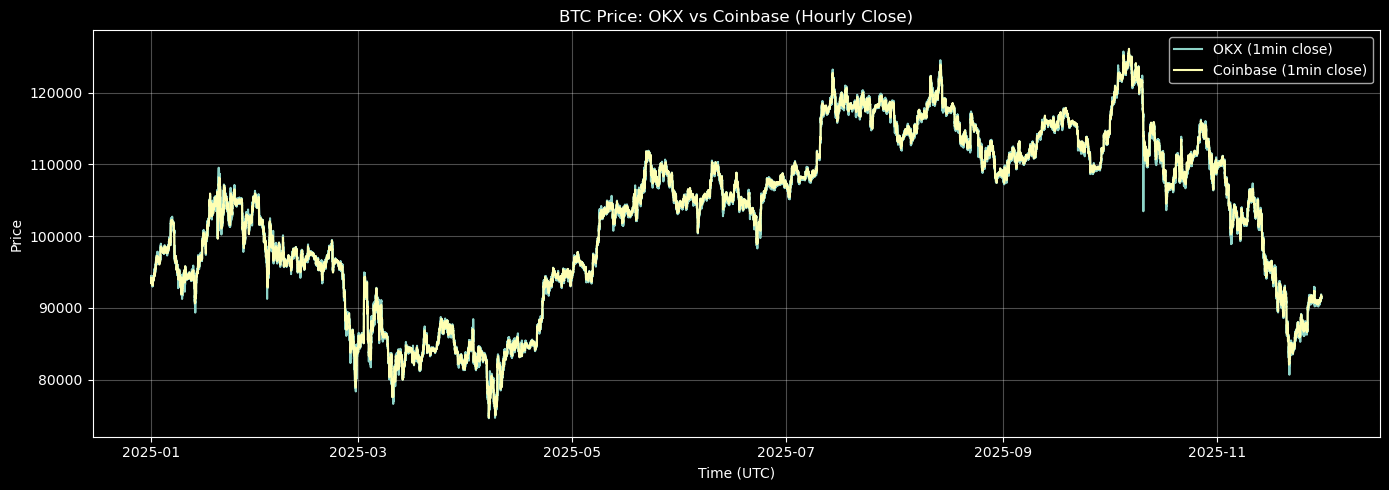

In [20]:
import matplotlib.pyplot as plt

# OKX -> 1H close to match Coinbase 1H close
okx_1h = df2["okx_close"].resample("1min").last()

# Coinbase already 1H; align to OKX hours
cb_1h_aligned = df2["cb_close_1h"].resample("1min").last()

tmp = (pd.concat([okx_1h.rename("OKX (1min close)"),
                  cb_1h_aligned.rename("Coinbase (1min close)")], axis=1)
         .dropna())

plt.figure(figsize=(14,5))
plt.plot(tmp.index, tmp["OKX (1min close)"], label="OKX (1min close)")
plt.plot(tmp.index, tmp["Coinbase (1min close)"], label="Coinbase (1min close)")
plt.title("BTC Price: OKX vs Coinbase (Hourly Close)")
plt.xlabel("Time (UTC)")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

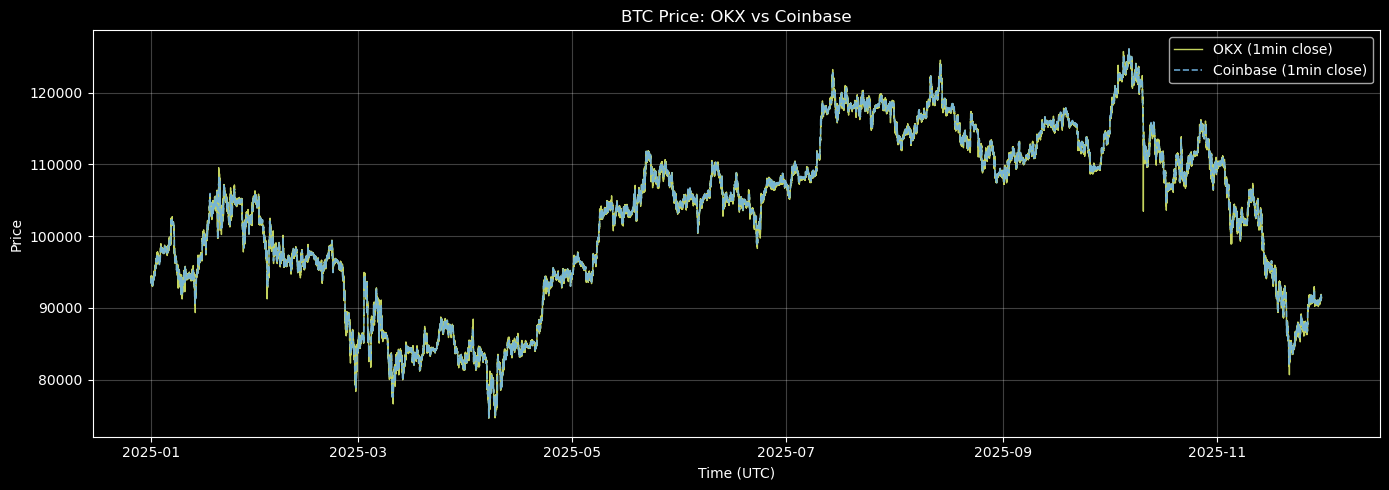

In [25]:
import matplotlib.pyplot as plt

okx_1m = df2["okx_close"].resample("1min").last()
cb_1m  = df2["cb_close_1h"].resample("1min").last()

tmp = (pd.concat([okx_1m.rename("OKX (1min close)"),
                  cb_1m.rename("Coinbase (1min close)")], axis=1)
         .dropna())

plt.figure(figsize=(14,5))

plt.plot(tmp.index, tmp["OKX (1min close)"],
         label="OKX (1min close)", color="#DAEB68", linewidth=1.0, alpha=0.9)

plt.plot(tmp.index, tmp["Coinbase (1min close)"],
         label="Coinbase (1min close)", color="#70B3E0", linewidth=1.2, alpha=0.9, linestyle="--")

plt.title("BTC Price: OKX vs Coinbase")
plt.xlabel("Time (UTC)")
plt.ylabel("Price")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

In [13]:
df2

,open_time,open,high,low,close,vol,vol_ccy,vol_quote,confirm,cb_close_1h,okx_close,prem_log_1h,prem_pct_1h
ts,,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,1735689600000,93579.1,93630.0,93552.1,93630.0,3309.90,33.0990,3.097138e+06,1,94209.02,93630.0,0.006165,0.006184
2025-01-01 00:01:00+00:00,1735689660000,93630.0,93668.0,93609.8,93668.0,1343.60,13.4360,1.258176e+06,1,94209.02,93668.0,0.005759,0.005776
2025-01-01 00:02:00+00:00,1735689720000,93668.0,93722.0,93650.3,93717.7,6676.90,66.7690,6.256212e+06,1,94209.02,93717.7,0.005229,0.005243
2025-01-01 00:03:00+00:00,1735689780000,93717.6,93717.7,93661.2,93697.1,1763.80,17.6380,1.652406e+06,1,94209.02,93697.1,0.005449,0.005464
2025-01-01 00:04:00+00:00,1735689840000,93697.1,93697.1,93666.9,93670.9,1177.00,11.7700,1.102647e+06,1,94209.02,93670.9,0.005728,0.005745
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30 15:55:00+00:00,1764518100000,91436.8,91436.9,91425.8,91425.9,1359.84,13.5984,1.243324e+06,1,91455.99,91425.9,0.000329,0.000329
2025-11-30 15:56:00+00:00,1764518160000,91425.9,91425.9,91406.5,91414.7,4037.35,40.3735,3.690838e+06,1,91455.99,91414.7,0.000452,0.000452
2025-11-30 15:57:00+00:00,1764518220000,91414.7,91430.0,91395.0,91395.0,1132.18,11.3218,1.034947e+06,1,91455.99,91395.0,0.000667,0.000667


#### Resample OKX to 1hr in order to match coinbase data

In [14]:

def build_sig_1h_keep_cols(df_okx_1m: pd.DataFrame,
                           product_id: str = "BTC-USD",
                           start="2025-01-01",
                           end="2025-12-01",
                           shift_1h_for_no_lookahead: bool = True,
                           # map your OKX column names here if different
                           col_open="open", col_high="high", col_low="low", col_close="close",
                           col_vol="vol", col_vol_ccy="vol_ccy", col_vol_quote="vol_quote") -> pd.DataFrame:
    df_okx_1m = ensure_dt_index(df_okx_1m)
    start = pd.Timestamp(start, tz="UTC")
    end   = pd.Timestamp(end, tz="UTC")
    df_okx_1m = df_okx_1m.loc[start:end].copy()

    # 1) Build 1H OHLCV(+ extras) with proper aggregations
    agg = {}
    if col_open in df_okx_1m.columns:  agg[col_open]  = "first"
    if col_high in df_okx_1m.columns:  agg[col_high]  = "max"
    if col_low  in df_okx_1m.columns:  agg[col_low]   = "min"
    if col_close in df_okx_1m.columns: agg[col_close] = "last"

    # volumes should be summed across the hour
    for c in [col_vol, col_vol_ccy, col_vol_quote]:
        if c in df_okx_1m.columns:
            agg[c] = "sum"

    # If you have other fields you want to keep, add them here with an aggregation:
    # e.g. funding_rate: "last", oi: "last"
    # agg["funding_rate"] = "last"

    okx_1h = (
        df_okx_1m.resample("1H", label="right", closed="right")
        .agg(agg)
        .dropna(subset=[col_close] if col_close in df_okx_1m.columns else None)
    ).rename(columns={col_close: "okx_close_1h"})

    # 2) Fetch Coinbase 1H close
    cb_1h = fetch_coinbase_candles(
        product_id=product_id,
        start=okx_1h.index.min(),
        end=okx_1h.index.max(),
        granularity=3600
    ).rename(columns={"close": "cb_close_1h"}).sort_index()

    # 3) Join + compute premium
    sig_1h = okx_1h.join(cb_1h, how="inner").dropna(subset=["okx_close_1h", "cb_close_1h"])

    sig_1h["prem_log_1h"] = np.log(sig_1h["cb_close_1h"]) - np.log(sig_1h["okx_close_1h"])
    sig_1h["prem_pct_1h"] = (sig_1h["cb_close_1h"] / sig_1h["okx_close_1h"]) - 1.0

    # 4) Optional: shift signal to avoid look-ahead
    if shift_1h_for_no_lookahead:
        sig_1h[["prem_log_1h", "prem_pct_1h"]] = sig_1h[["prem_log_1h", "prem_pct_1h"]].shift(1)

    return sig_1h.dropna(subset=["prem_log_1h", "prem_pct_1h"])

In [15]:
sig_1h = build_sig_1h_keep_cols(
    df,
    product_id="BTC-USD",
    start="2025-01-01",
    end="2025-12-01",
    shift_1h_for_no_lookahead=True,
    col_open="open", col_high="high", col_low="low", col_close="close",
    col_vol="vol", col_vol_ccy="vol_ccy", col_vol_quote="vol_quote",
)

print(sig_1h.head())
print(sig_1h.columns)

/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/653997394.py:31: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_okx_1m.resample("1H", label="right", closed="right")


                              open     high      low  okx_close_1h       vol  \
2025-01-01 01:00:00+00:00  93630.0  94500.0  93492.1       94273.3  295100.3   
2025-01-01 02:00:00+00:00  94273.3  94273.3  93570.1       93660.6  217547.3   
2025-01-01 03:00:00+00:00  93660.6  94101.6  93655.9       94033.4  119507.9   
2025-01-01 04:00:00+00:00  94033.4  94056.8  93711.7       93792.9  111393.6   
2025-01-01 05:00:00+00:00  93792.8  93803.2  93525.0       93567.5  125060.4   

                            vol_ccy     vol_quote  cb_close_1h  prem_log_1h  \
2025-01-01 01:00:00+00:00  2951.003  2.773847e+08     93423.47     0.006165   
2025-01-01 02:00:00+00:00  2175.473  2.042948e+08     93882.09    -0.009055   
2025-01-01 03:00:00+00:00  1195.079  1.121970e+08     93635.54     0.002362   
2025-01-01 04:00:00+00:00  1113.936  1.045618e+08     93358.58    -0.004240   
2025-01-01 05:00:00+00:00  1250.604  1.171408e+08     93572.80    -0.004641   

                           prem_pct_1h  
202

In [16]:
sig_1h

,open,high,low,okx_close_1h,vol,vol_ccy,vol_quote,cb_close_1h,prem_log_1h,prem_pct_1h
2025-01-01 01:00:00+00:00,93630.0,94500.0,93492.1,94273.3,295100.30,2951.0030,2.773847e+08,93423.47,0.006165,0.006184
2025-01-01 02:00:00+00:00,94273.3,94273.3,93570.1,93660.6,217547.30,2175.4730,2.042948e+08,93882.09,-0.009055,-0.009015
2025-01-01 03:00:00+00:00,93660.6,94101.6,93655.9,94033.4,119507.90,1195.0790,1.121970e+08,93635.54,0.002362,0.002365
2025-01-01 04:00:00+00:00,94033.4,94056.8,93711.7,93792.9,111393.60,1113.9360,1.045618e+08,93358.58,-0.004240,-0.004231
2025-01-01 05:00:00+00:00,93792.8,93803.2,93525.0,93567.5,125060.40,1250.6040,1.171408e+08,93572.80,-0.004641,-0.004631
...,...,...,...,...,...,...,...,...,...,...
2025-11-30 12:00:00+00:00,91174.2,91357.0,90916.3,91026.1,174348.87,1743.4887,1.588652e+08,91485.87,-0.001261,-0.001260
2025-11-30 13:00:00+00:00,91026.1,91496.9,90960.0,91394.6,193384.07,1933.8407,1.764787e+08,91781.88,0.005038,0.005051
2025-11-30 14:00:00+00:00,91394.7,91935.8,91350.0,91691.1,458766.24,4587.6624,4.207248e+08,91499.72,0.004228,0.004237
2025-11-30 15:00:00+00:00,91691.1,91719.5,91213.0,91400.0,220959.41,2209.5941,2.020645e+08,91455.99,-0.002089,-0.002087


- $\text{CBP}_t=\frac{P^{CB}_t - P^{OKX}_t}{P^{OKX}_t}$

In [18]:
import matplotlib.pyplot as plt

In [19]:
plt.style.use("dark_background")

In [20]:
d = sig_1h.copy().sort_index()

# 1) raw premium (NO log)
d["cbp_raw"] = (d["cb_close_1h"] - d["okx_close_1h"]) / d["okx_close_1h"]

# 2) look-ahead safety if you use it as a trading signal
# (signal computed from hour t should only be used starting t+1)
d["cbp_sig"] = d["cbp_raw"].shift(1)

x = d["cbp_sig"].dropna()

# 3) distribution summary
summary = {
    "n": int(x.shape[0]),
    "mean": float(x.mean()),
    "std": float(x.std(ddof=0)),
    "min": float(x.min()),
    "max": float(x.max()),
    "skew": float(x.skew()),
    "kurtosis": float(x.kurtosis()),
}
print("CBP raw (shifted) summary:", summary)

qs = x.quantile([0.001,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99,0.999])
print("\nQuantiles:\n", qs)

CBP raw (shifted) summary: {'n': 8002, 'mean': 0.0002808594804419862, 'std': 0.004736295318071482, 'min': -0.048708866786289065, 'max': 0.0488643963101175, 'skew': -0.3400222626186851, 'kurtosis': 12.194361012967441}

Quantiles:
 0.001   -0.030128
0.010   -0.014571
0.050   -0.006732
0.100   -0.004320
0.250   -0.001637
0.500    0.000428
0.750    0.002409
0.900    0.004817
0.950    0.006805
0.990    0.012850
0.999    0.027275
Name: cbp_sig, dtype: float64


In [21]:
import matplotlib.pyplot as plt

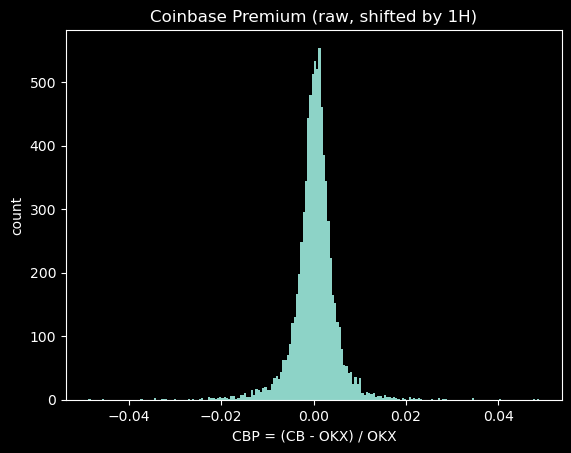

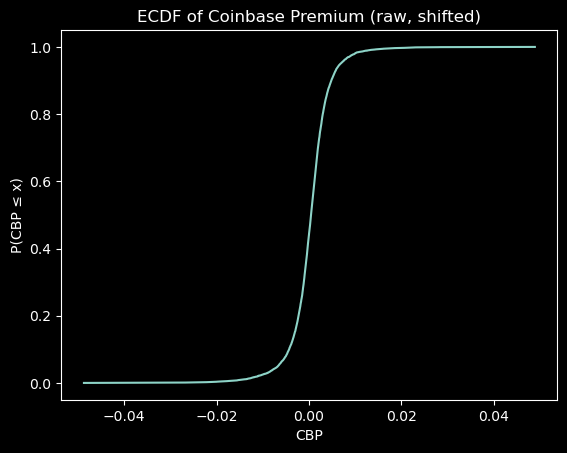


Tail frequencies:
  |CBP|>0.0500%:  P(CBP>+th)=48.96%,  P(CBP<-th)=37.44%,  total=86.40%
  |CBP|>0.1000%:  P(CBP>+th)=42.34%,  P(CBP<-th)=31.58%,  total=73.92%
  |CBP|>0.1500%:  P(CBP>+th)=35.23%,  P(CBP<-th)=25.99%,  total=61.22%
  |CBP|>0.2000%:  P(CBP>+th)=29.24%,  P(CBP<-th)=21.92%,  total=51.16%
  |CBP|>0.3000%:  P(CBP>+th)=19.77%,  P(CBP<-th)=15.36%,  total=35.13%
  |CBP|>0.5000%:  P(CBP>+th)=9.42%,  P(CBP<-th)=8.00%,  total=17.42%


In [22]:
plt.figure()
plt.hist(x.values, bins=200)
plt.title("Coinbase Premium (raw, shifted by 1H)")
plt.xlabel("CBP = (CB - OKX) / OKX")
plt.ylabel("count")
plt.show()

# 5) ECDF (helps pick thresholds)
xs = np.sort(x.values)
ys = np.arange(1, len(xs)+1) / len(xs)
plt.figure()
plt.plot(xs, ys)
plt.title("ECDF of Coinbase Premium (raw, shifted)")
plt.xlabel("CBP")
plt.ylabel("P(CBP ≤ x)")
plt.show()

# 6) tail frequencies for candidate trading thresholds
# (use these to see how often you'll trade)
thresholds = [0.0005, 0.0010, 0.0015, 0.0020, 0.0030, 0.0050]  # 5bp,10bp,15bp,20bp,30bp,50bp
print("\nTail frequencies:")
for th in thresholds:
    p_pos = (x > th).mean()
    p_neg = (x < -th).mean()
    print(f"  |CBP|>{th:.4%}:  P(CBP>+th)={p_pos:.2%},  P(CBP<-th)={p_neg:.2%},  total={p_pos+p_neg:.2%}")

### $\text{CBP\_excess}_t=\text{CBP}_t-\text{rolling mean}(\text{CBP})$
- removes slow drift / USD–USDT basis bias and makes the tails more interpretable.


CBP raw summary:
{'n': 8003, 'mean': 0.0002814382616436065, 'std': 0.0047362823924315765, 'min': -0.048708866786289065, 'max': 0.0488643963101175, 'skew': -0.3402323239591136, 'kurtosis': 12.192907768727915}
quantiles:
 0.001   -0.030125
0.010   -0.014570
0.050   -0.006732
0.100   -0.004320
0.250   -0.001637
0.500    0.000428
0.750    0.002411
0.900    0.004823
0.950    0.006804
0.990    0.012850
0.999    0.027274
Name: cbp_raw, dtype: float64

CBP_excess (shifted) summary:
{'n': 7835, 'mean': 1.3790403259047332e-05, 'std': 0.004716805062234821, 'min': -0.04819689180806261, 'max': 0.04983579961447219, 'skew': -0.11851319199446887, 'kurtosis': 12.239153989451534}
quantiles:
 0.001   -0.029348
0.010   -0.014197
0.050   -0.006844
0.100   -0.004478
0.250   -0.001952
0.500    0.000060
0.750    0.002091
0.900    0.004531
0.950    0.006667
0.990    0.012963
0.999    0.027099
Name: cbp_excess_sig, dtype: float64


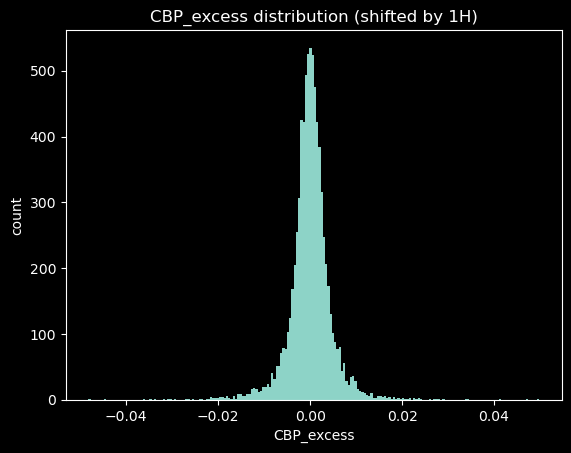

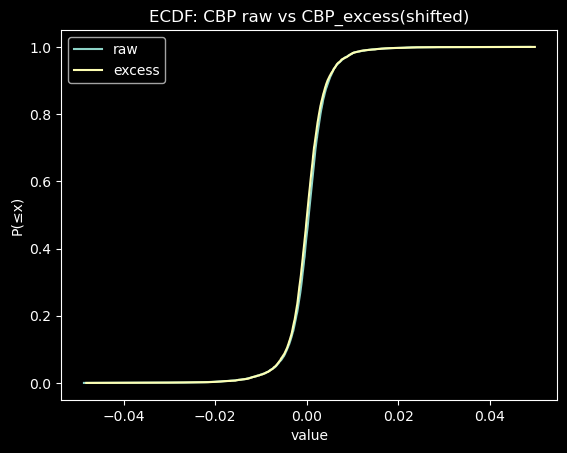


Tail frequencies (CBP_excess shifted):
|excess|>0.10%:  P(>+th)=37.20%,  P(<-th)=35.81%, total=73.02%
|excess|>0.20%:  P(>+th)=25.91%,  P(<-th)=24.39%, total=50.30%
|excess|>0.30%:  P(>+th)=17.47%,  P(<-th)=16.78%, total=34.26%
|excess|>0.50%:  P(>+th)=8.68%,  P(<-th)=8.47%, total=17.15%
|excess|>0.75%:  P(>+th)=3.94%,  P(<-th)=4.20%, total=8.14%
|excess|>1.00%:  P(>+th)=1.86%,  P(<-th)=2.45%, total=4.31%


In [23]:
d = sig_1h.copy().sort_index()

# Raw CBP (no log)
d["cbp_raw"] = (d["cb_close_1h"] - d["okx_close_1h"]) / d["okx_close_1h"]

# Rolling mean removal (choose L = 7d, 14d, 30d)
L = 24 * 7
d["cbp_mu"] = d["cbp_raw"].rolling(L).mean()
d["cbp_excess"] = d["cbp_raw"] - d["cbp_mu"]

# Look-ahead safe trading signal uses past value
d["cbp_excess_sig"] = d["cbp_excess"].shift(1)

x_raw = d["cbp_raw"].dropna()
x_exc = d["cbp_excess_sig"].dropna()

# --- Distribution summary ---
def summarize(x, name):
    qs = x.quantile([0.001,0.01,0.05,0.10,0.25,0.50,0.75,0.90,0.95,0.99,0.999])
    print(f"\n{name} summary:")
    print({
        "n": int(x.shape[0]),
        "mean": float(x.mean()),
        "std": float(x.std(ddof=0)),
        "min": float(x.min()),
        "max": float(x.max()),
        "skew": float(x.skew()),
        "kurtosis": float(x.kurtosis())
    })
    print("quantiles:\n", qs)

summarize(x_raw, "CBP raw")
summarize(x_exc, "CBP_excess (shifted)")

# --- Histograms --

plt.figure()
plt.hist(x_exc.values, bins=200)
plt.title("CBP_excess distribution (shifted by 1H)")
plt.xlabel("CBP_excess"); plt.ylabel("count")
plt.show()

# --- ECDF overlay ---
def ecdf(x):
    xs = np.sort(x)
    ys = np.arange(1, len(xs)+1)/len(xs)
    return xs, ys

xs1, ys1 = ecdf(x_raw.values)
xs2, ys2 = ecdf(x_exc.values)

plt.figure()
plt.plot(xs1, ys1)
plt.plot(xs2, ys2)
plt.title("ECDF: CBP raw vs CBP_excess(shifted)")
plt.xlabel("value"); plt.ylabel("P(≤x)")
plt.legend(["raw","excess"])
plt.show()

# --- Tail frequencies (use bps thresholds) ---
thresholds = [0.001,0.002,0.003,0.005,0.0075,0.01]  # 10,20,30,50,75,100 bps
print("\nTail frequencies (CBP_excess shifted):")
for th in thresholds:
    p_pos = (x_exc > th).mean()
    p_neg = (x_exc < -th).mean()
    print(f"|excess|>{th:.2%}:  P(>+th)={p_pos:.2%},  P(<-th)={p_neg:.2%}, total={p_pos+p_neg:.2%}")

### Hull Exponential Moving Average
- $\text{WMA}n(t)=\frac{\sum{i=1}^{n} i\cdot P_{t-n+i}}{\sum_{i=1}^{n} i}$
- $\text{WMA}_n(t) (slow)$
- $\text{WMA}_{n/2}(t) (fast)$
- $ D(t)=2\cdot \text{WMA}_{n/2}(t)-\text{WMA}_n(t)$
- $\text{HMA}n(t)=\text{WMA}{\sqrt{n}}(D(t))$
- $\boxed{\text{HMA}n(t)=\text{WMA}{\sqrt{n}}\Big(2\cdot \text{WMA}_{n/2}(t)-\text{WMA}_n(t)\Big)
}$

In [39]:


def wma(x: pd.Series, n: int) -> pd.Series:
    n = int(n)
    w = np.arange(1, n+1, dtype=float)
    return x.rolling(n).apply(lambda v: np.dot(v, w)/w.sum(), raw=True)

def hma(x: pd.Series, n: int) -> pd.Series:
    n = int(n)
    half = max(1, n//2)
    sqrt_n = max(1, int(np.sqrt(n)))
    return wma(2*wma(x, half) - wma(x, n), sqrt_n)

def build_pos_hma_cbp_excess(sig_1h, n_fast=19, n_slow=44, tau=0.003, L=24*7,
                             hma_source="okx_close_1h", mode="mean_revert"):
    d = sig_1h.copy().sort_index()

    # CBP excess
    d["cbp_raw"] = (d["cb_close_1h"] - d["okx_close_1h"]) / d["okx_close_1h"]
    d["cbp_excess"] = d["cbp_raw"] - d["cbp_raw"].rolling(L).mean()
    d["cbp_sig"] = d["cbp_excess"].shift(1)

    # HMA trend on chosen source
    src = pd.to_numeric(d[hma_source], errors="coerce")
    d["hma_fast"] = hma(src, n_fast)
    d["hma_slow"] = hma(src, n_slow)
    d["trend"] = np.sign(d["hma_fast"] - d["hma_slow"]).replace(0, np.nan).ffill().fillna(0.0)

    # Combine
    if mode == "confirm_trend":
        long_cond  = (d["trend"] > 0) & (d["cbp_sig"] > +tau)
        short_cond = (d["trend"] < 0) & (d["cbp_sig"] < -tau)
    elif mode == "mean_revert":
        long_cond  = (d["trend"] > 0) & (d["cbp_sig"] < -tau)
        short_cond = (d["trend"] < 0) & (d["cbp_sig"] > +tau)
    else:
        raise ValueError("mode must be confirm_trend or mean_revert")

    d["pos"] = 0.0
    d.loc[long_cond, "pos"] = +1.0
    d.loc[short_cond, "pos"] = -1.0
    return d

def backtest_simple_1h(d, fee_taker=0.0004):
    bt = d.copy()
    bt["ret_1h"] = np.log(bt["okx_close_1h"]).diff()
    bt["pos_lag"] = bt["pos"].shift(1).fillna(0.0)
    bt["dpos"] = (bt["pos"] - bt["pos_lag"]).abs()
    bt["cost"] = fee_taker * bt["dpos"]
    bt["strat_ret"] = bt["pos_lag"] * bt["ret_1h"] - bt["cost"]
    bt["equity"] = (1 + bt["strat_ret"].fillna(0)).cumprod()
    return bt

# Sweep thresholds quickly
fee = 0.0004
taus = [0.002,0.003,0.005,0.0075,0.01]  # 20..100 bps

for mode in ["confirm_trend", "mean_revert"]:
    rows=[]
    for tau in taus:
        dpos = build_pos_hma_cbp_excess(sig_1h, tau=tau, L=24*7, mode=mode)
        bt = backtest_simple_1h(dpos, fee_taker=fee)
        rows.append([mode, tau, float((dpos["pos"]!=0).mean()), float(bt["equity"].dropna().iloc[-1])])
    print(pd.DataFrame(rows, columns=["mode","tau","freq_in_pos","final_equity"]).sort_values("final_equity", ascending=False))

            mode     tau  freq_in_pos  final_equity
4  confirm_trend  0.0100     0.025490      0.815863
3  confirm_trend  0.0075     0.045858      0.696894
2  confirm_trend  0.0050     0.090966      0.553238
1  confirm_trend  0.0030     0.173810      0.408348
0  confirm_trend  0.0020     0.250281      0.321556
          mode     tau  freq_in_pos  final_equity
4  mean_revert  0.0100     0.016744      0.929628
3  mean_revert  0.0075     0.033862      0.769316
2  mean_revert  0.0050     0.076971      0.638518
1  mean_revert  0.0030     0.161564      0.447629
0  mean_revert  0.0020     0.242159      0.318635


#### Resample the 1hr timeframe into 4hr timeframe to reduce noise

In [24]:
import numpy as np
import pandas as pd

def build_4h_okx_cbp_excess(
    df_okx_1m: pd.DataFrame,
    start="2025-01-01",
    end="2025-12-01",
    okx_cols=("open","high","low","close"),
    vol_cols=("vol","vol_ccy","vol_quote"),
    cb_product="BTC-USD",
    cb_granularity_sec=3600,     # fetch Coinbase 1H
    roll_L_4h=42,                # rolling mean window in 4H bars (e.g. 42=7 days if 6 bars/day)
    shift_1bar=True              # shift CBP_excess by 1 bar to avoid lookahead
) -> pd.DataFrame:
    # 0) OKX index to UTC + slice
    d1m = ensure_dt_index(df_okx_1m).sort_index()
    start = pd.Timestamp(start, tz="UTC")
    end   = pd.Timestamp(end, tz="UTC")
    d1m = d1m.loc[start:end].copy()

    o,h,l,c = okx_cols

    # 1) OKX 1m -> 4H OHLCV
    agg = {}
    for col, fn in [(o,"first"), (h,"max"), (l,"min"), (c,"last")]:
        if col in d1m.columns:
            agg[col] = fn
        else:
            raise ValueError(f"Missing OKX column '{col}' in df. Available: {d1m.columns.tolist()}")

    for vc in vol_cols:
        if vc in d1m.columns:
            agg[vc] = "sum"   # volumes sum across the 4H window

    okx_4h = (
        d1m.resample("4H", label="right", closed="right")
        .agg(agg)
        .dropna(subset=[c])
        .rename(columns={c: "okx_close_4h"})
    )

    # 2) Coinbase 1H close over same window
    cb_1h = fetch_coinbase_candles(
        product_id=cb_product,
        start=okx_4h.index.min(),
        end=okx_4h.index.max(),
        granularity=cb_granularity_sec
    ).rename(columns={"close":"cb_close_1h"}).sort_index()

    # 3) Coinbase 1H -> 4H close (last close in each 4H bin)
    cb_4h = (
        cb_1h["cb_close_1h"]
        .resample("4H", label="right", closed="right")
        .last()
        .dropna()
        .to_frame("cb_close_4h")
    )

    # 4) Join OKX 4H + Coinbase 4H
    panel_4h = okx_4h.join(cb_4h, how="inner").dropna(subset=["okx_close_4h","cb_close_4h"])

    # 5) CBP raw on 4H (no log)
    panel_4h["cbp_raw_4h"] = (panel_4h["cb_close_4h"] - panel_4h["okx_close_4h"]) / panel_4h["okx_close_4h"]

    # 6) CBP excess on 4H (rolling mean computed on 4H)
    panel_4h["cbp_mu_4h"] = panel_4h["cbp_raw_4h"].rolling(roll_L_4h).mean()
    panel_4h["cbp_excess_4h"] = panel_4h["cbp_raw_4h"] - panel_4h["cbp_mu_4h"]

    # 7) Trading-safe signal (use last completed 4H bar)
    if shift_1bar:
        panel_4h["cbp_excess_sig_4h"] = panel_4h["cbp_excess_4h"].shift(1)
        panel_4h["cbp_raw_sig_4h"] = panel_4h["cbp_raw_4h"].shift(1)
    else:
        panel_4h["cbp_excess_sig_4h"] = panel_4h["cbp_excess_4h"]
        panel_4h["cbp_raw_sig_4h"] = panel_4h["cbp_raw_4h"]

    return panel_4h.dropna(subset=["cbp_excess_sig_4h"])


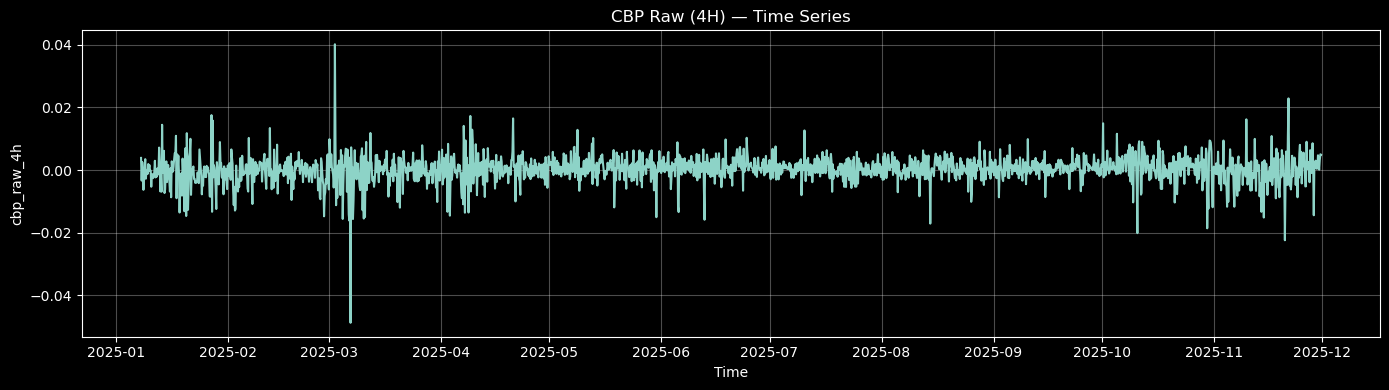

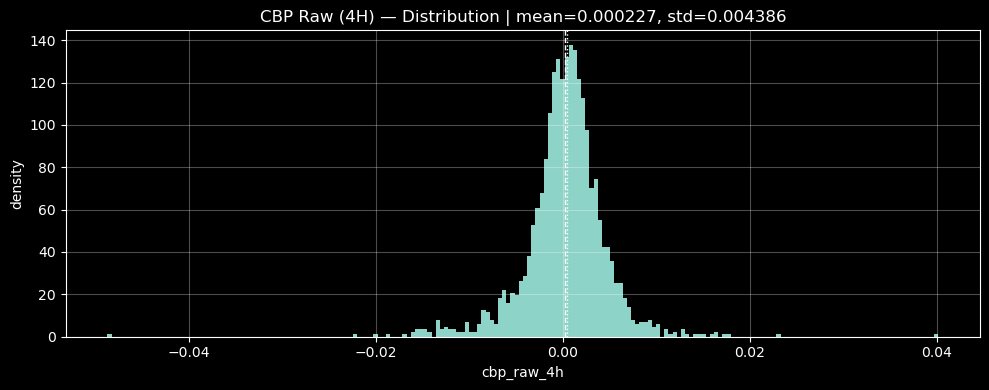

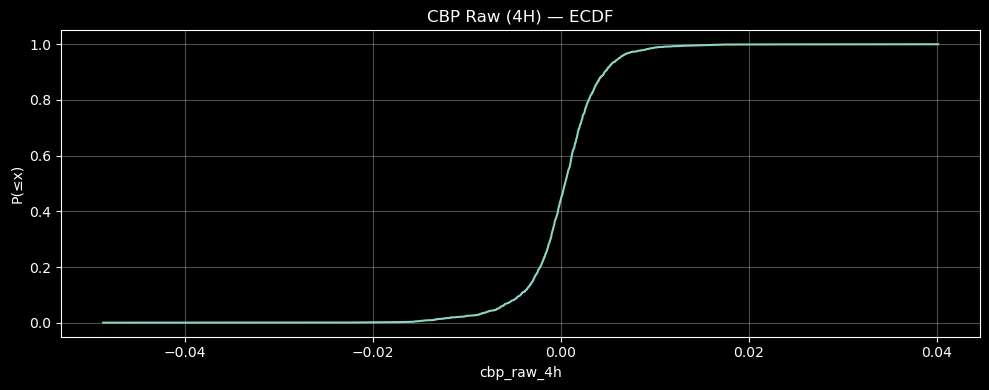

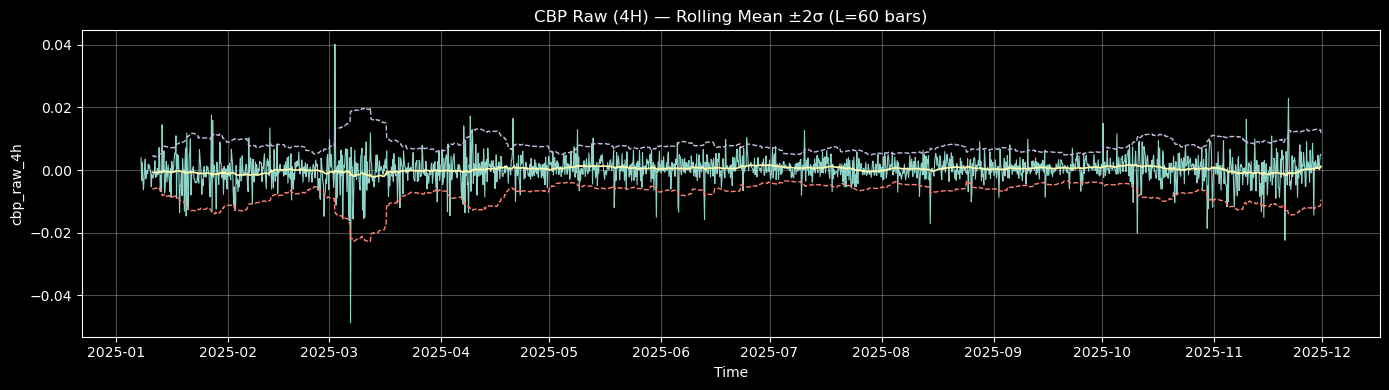

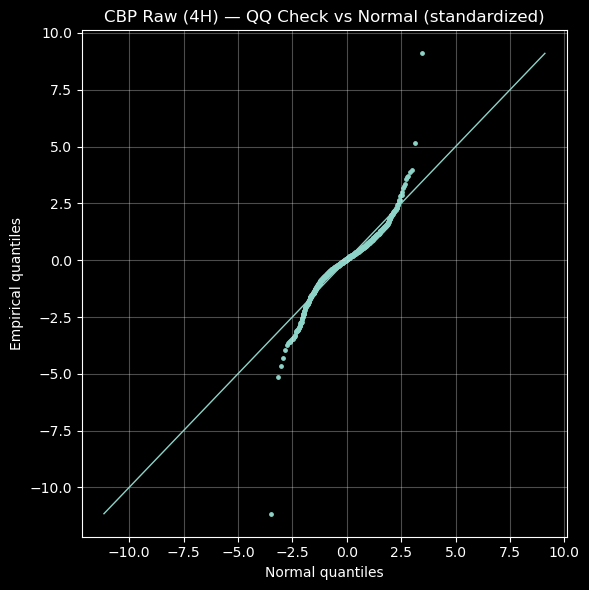

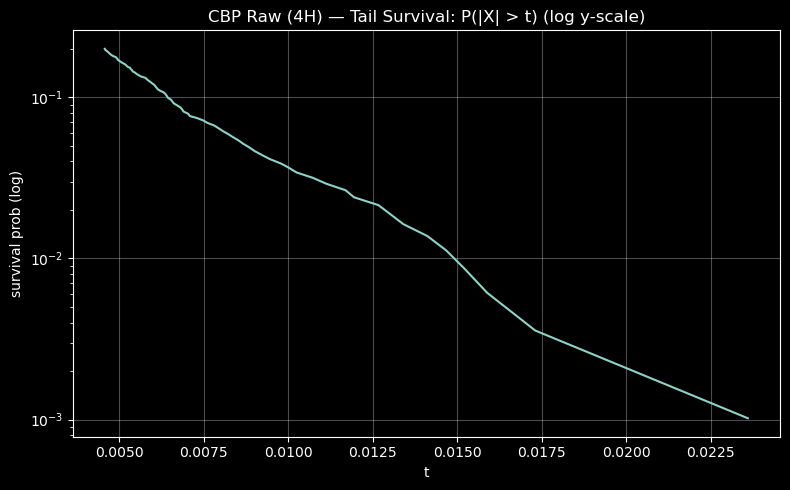

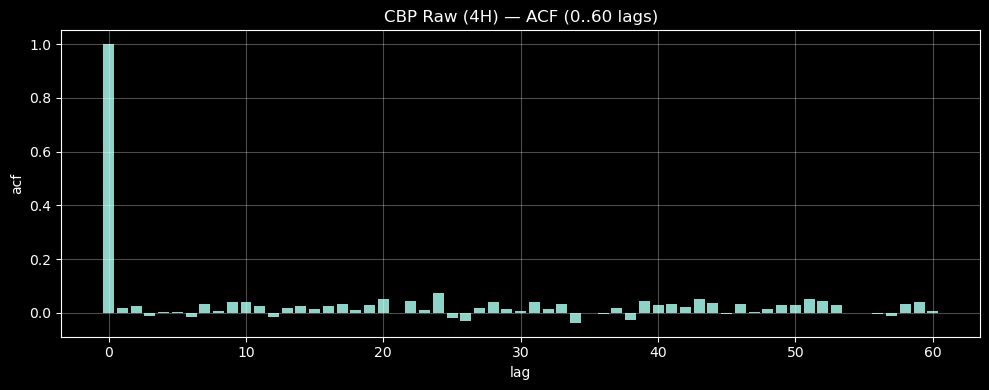

{'n': 1960, 'mean': 0.00022675064127429032, 'std': 0.0043864000128584464, 'min': -0.048708866786289065, 'max': 0.04015583473855952, 'p01': -0.013524807373602494, 'p99': 0.010541646988610542}


In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_cbp_raw_suite(panel_4h: pd.DataFrame,
                       okx_col="okx_close_4h",
                       cb_col="cb_close_4h",
                       out_col="cbp_raw_4h",
                       roll_L=60,          # 60x4H ~= 10 days
                       bins=200,
                       acf_lags=60):

    p = panel_4h.copy().sort_index()

    # compute cbp_raw_4h (your formula)
    p[out_col] = (p[cb_col] - p[okx_col]) / p[okx_col]
    x = p[out_col].dropna().astype(float)

    # ---- 1) Time series ----
    plt.figure(figsize=(14,4))
    plt.plot(x.index, x.values)
    plt.title("CBP Raw (4H) — Time Series")
    plt.xlabel("Time"); plt.ylabel(out_col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- 2) Histogram (density) ----
    mu, med, sd = float(x.mean()), float(x.median()), float(x.std(ddof=0))
    plt.figure(figsize=(10,4))
    plt.hist(x.values, bins=bins, density=True)
    plt.axvline(mu, linewidth=1, linestyle="--")
    plt.axvline(med, linewidth=1, linestyle=":")
    plt.title(f"CBP Raw (4H) — Distribution | mean={mu:.6f}, std={sd:.6f}")
    plt.xlabel(out_col); plt.ylabel("density")
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- 3) ECDF ----
    xs = np.sort(x.values)
    ys = np.arange(1, len(xs)+1) / len(xs)
    plt.figure(figsize=(10,4))
    plt.plot(xs, ys)
    plt.title("CBP Raw (4H) — ECDF")
    plt.xlabel(out_col); plt.ylabel("P(≤x)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- 4) Rolling mean + bands (±2σ) ----
    m = x.rolling(roll_L, min_periods=max(10, roll_L//3)).mean()
    s = x.rolling(roll_L, min_periods=max(10, roll_L//3)).std(ddof=0)
    upper = m + 2*s
    lower = m - 2*s

    plt.figure(figsize=(14,4))
    plt.plot(x.index, x.values, linewidth=0.8)
    plt.plot(m.index, m.values, linewidth=1.2)
    plt.plot(upper.index, upper.values, linewidth=1.0, linestyle="--")
    plt.plot(lower.index, lower.values, linewidth=1.0, linestyle="--")
    plt.title(f"CBP Raw (4H) — Rolling Mean ±2σ (L={roll_L} bars)")
    plt.xlabel("Time"); plt.ylabel(out_col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- 5) QQ-style Normal check (no scipy needed) ----
    # compare empirical quantiles to theoretical N(0,1) quantiles using an approximation
    # We approximate N(0,1) quantiles via numpy using a large normal sample (stable enough for diagnostics).
    n = len(xs)
    u = (np.arange(1, n+1) - 0.5) / n
    z_theory = np.quantile(np.random.normal(size=2_000_000), u)  # diagnostic only
    z_emp = (xs - mu) / (sd + 1e-12)

    plt.figure(figsize=(6,6))
    plt.scatter(z_theory, z_emp, s=6)
    lo = min(z_theory.min(), z_emp.min())
    hi = max(z_theory.max(), z_emp.max())
    plt.plot([lo, hi], [lo, hi], linewidth=1)
    plt.title("CBP Raw (4H) — QQ Check vs Normal (standardized)")
    plt.xlabel("Normal quantiles"); plt.ylabel("Empirical quantiles")
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- 6) Tail / Survival plot (log tail) ----
    # Plot P(|X| > t) for a grid of t
    absx = np.abs(x.values)
    t_grid = np.quantile(absx, np.linspace(0.80, 0.999, 80))  # focus on tail
    surv = np.array([(absx > t).mean() for t in t_grid])

    plt.figure(figsize=(8,5))
    plt.plot(t_grid, surv)
    plt.yscale("log")
    plt.title("CBP Raw (4H) — Tail Survival: P(|X| > t) (log y-scale)")
    plt.xlabel("t"); plt.ylabel("survival prob (log)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # ---- 7) Autocorrelation (ACF) ----
    # simple ACF estimator
    xv = x.values - x.values.mean()
    denom = np.dot(xv, xv) + 1e-12
    acf = [1.0]
    for k in range(1, acf_lags+1):
        acf.append(float(np.dot(xv[k:], xv[:-k]) / denom))
    acf = np.array(acf)

    plt.figure(figsize=(10,4))
    plt.bar(np.arange(len(acf)), acf)
    plt.title(f"CBP Raw (4H) — ACF (0..{acf_lags} lags)")
    plt.xlabel("lag"); plt.ylabel("acf")
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # quick printed stats
    print({
        "n": int(x.shape[0]),
        "mean": float(mu),
        "std": float(sd),
        "min": float(x.min()),
        "max": float(x.max()),
        "p01": float(x.quantile(0.01)),
        "p99": float(x.quantile(0.99)),
    })

    return p  # returns panel with cbp_raw_4h column added

# usage:
panel_4h = plot_cbp_raw_suite(panel_4h)

In [25]:
# ===== RUN =====
panel_4h = build_4h_okx_cbp_excess(
    df,                      # your OKX 1m df
    start="2025-01-01",
    end="2025-12-01",
    roll_L_4h=42,            # 7 days in 4H bars (6 bars/day)
    shift_1bar=True
)

print(panel_4h[["okx_close_4h","cb_close_4h","cbp_raw_4h","cbp_excess_4h","cbp_excess_sig_4h"]].head())
print(panel_4h.columns)

/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/2092619560.py:36: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  d1m.resample("4H", label="right", closed="right")


                           okx_close_4h  cb_close_4h  cbp_raw_4h  \
2025-01-08 00:00:00+00:00       96866.3     97243.86    0.003898   
2025-01-08 04:00:00+00:00       96573.8     96253.00   -0.003322   
2025-01-08 08:00:00+00:00       95663.9     95909.16    0.002564   
2025-01-08 12:00:00+00:00       95135.8     94852.72   -0.002976   
2025-01-08 16:00:00+00:00       95340.0     94740.36   -0.006289   

                           cbp_excess_4h  cbp_excess_sig_4h  
2025-01-08 00:00:00+00:00       0.004375           0.001110  
2025-01-08 04:00:00+00:00      -0.002875           0.004375  
2025-01-08 08:00:00+00:00       0.002835          -0.002875  
2025-01-08 12:00:00+00:00      -0.002590           0.002835  
2025-01-08 16:00:00+00:00      -0.005899          -0.002590  
Index(['open', 'high', 'low', 'okx_close_4h', 'vol', 'vol_ccy', 'vol_quote',
       'cb_close_4h', 'cbp_raw_4h', 'cbp_mu_4h', 'cbp_excess_4h',
       'cbp_excess_sig_4h', 'cbp_raw_sig_4h'],
      dtype='object')


/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/2092619560.py:53: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  .resample("4H", label="right", closed="right")


In [107]:
panel_4h

,open,high,low,okx_close_4h,vol,vol_ccy,vol_quote,cb_close_4h,cbp_raw_4h,cbp_mu_4h,cbp_excess_4h,cbp_excess_sig_4h,cbp_raw_sig_4h
2025-01-08 00:00:00+00:00,96384.7,97217.3,96167.1,96866.3,1348397.10,13483.9710,1.303659e+09,97243.86,0.003898,-0.000478,0.004375,0.001110,0.000687
2025-01-08 04:00:00+00:00,96866.3,97260.0,96228.0,96573.8,1128723.20,11287.2320,1.092343e+09,96253.00,-0.003322,-0.000446,-0.002875,0.004375,0.003898
2025-01-08 08:00:00+00:00,96573.9,96661.9,95251.4,95663.9,1875208.80,18752.0880,1.798272e+09,95909.16,0.002564,-0.000271,0.002835,-0.002875,-0.003322
2025-01-08 12:00:00+00:00,95663.9,96143.1,94532.0,95135.8,1741871.50,17418.7150,1.662541e+09,94852.72,-0.002976,-0.000385,-0.002590,0.002835,0.002564
2025-01-08 16:00:00+00:00,95135.7,96079.9,94618.3,95340.0,2453695.60,24536.9560,2.337838e+09,94740.36,-0.006289,-0.000390,-0.005899,-0.002590,-0.002976
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-30 00:00:00+00:00,90558.6,91022.9,90367.2,90794.6,450514.92,4505.1492,4.089015e+08,90914.65,0.001322,0.000902,0.000420,0.003784,0.004729
2025-11-30 04:00:00+00:00,90794.6,91006.7,90418.0,90863.3,440378.95,4403.7895,3.998006e+08,90876.50,0.000145,0.000842,-0.000697,0.000420,0.001322
2025-11-30 08:00:00+00:00,90863.3,91010.0,90627.6,90893.7,375139.96,3751.3996,3.407471e+08,91194.96,0.003314,0.000826,0.002488,-0.000697,0.000145
2025-11-30 12:00:00+00:00,90893.6,91605.4,90877.7,91026.1,975454.59,9754.5459,8.898676e+08,91485.87,0.005051,0.000886,0.004165,0.002488,0.003314


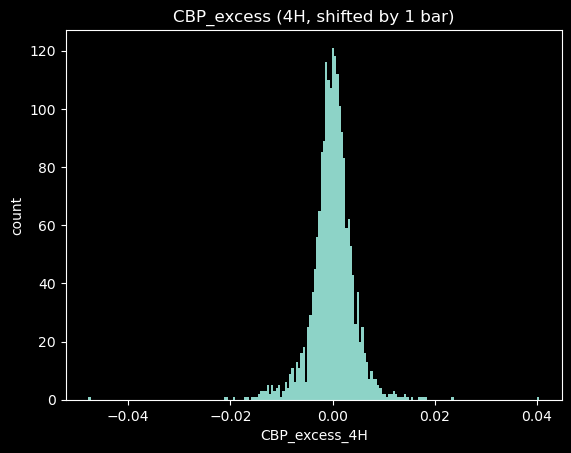

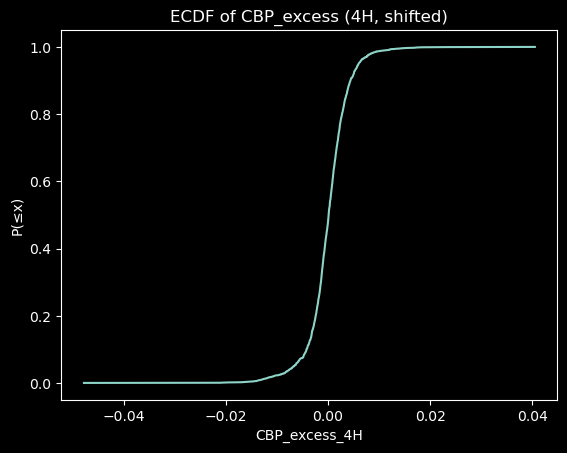


Tail frequencies (CBP_excess 4H shifted):
|excess|>0.20%:  P(>+th)=26.63%,  P(<-th)=23.72%, total=50.36%
|excess|>0.30%:  P(>+th)=18.11%,  P(<-th)=15.92%, total=34.03%
|excess|>0.50%:  P(>+th)=8.06%,  P(<-th)=7.50%, total=15.56%
|excess|>0.75%:  P(>+th)=3.01%,  P(<-th)=4.08%, total=7.09%
|excess|>1.00%:  P(>+th)=1.28%,  P(<-th)=2.30%, total=3.57%
|excess|>1.50%:  P(>+th)=0.36%,  P(<-th)=0.41%, total=0.77%
|excess|>2.00%:  P(>+th)=0.10%,  P(<-th)=0.15%, total=0.26%


In [27]:
p = panel_4h.copy().sort_index()

# use the trading-safe signal (shifted)
x = p["cbp_excess_sig_4h"].dropna()

# --- Histogram ---
plt.figure()
plt.hist(x.values, bins=200)
plt.title("CBP_excess (4H, shifted by 1 bar)")
plt.xlabel("CBP_excess_4H"); plt.ylabel("count")
plt.show()

# --- ECDF ---
xs = np.sort(x.values)
ys = np.arange(1, len(xs)+1)/len(xs)
plt.figure()
plt.plot(xs, ys)
plt.title("ECDF of CBP_excess (4H, shifted)")
plt.xlabel("CBP_excess_4H"); plt.ylabel("P(≤x)")
plt.show()

# --- Tail frequencies ---
thresholds = [0.002,0.003,0.005,0.0075,0.01,0.015,0.02]  # 20..200 bps
print("\nTail frequencies (CBP_excess 4H shifted):")
for th in thresholds:
    p_pos = (x > th).mean()
    p_neg = (x < -th).mean()
    print(f"|excess|>{th:.2%}:  P(>+th)={p_pos:.2%},  P(<-th)={p_neg:.2%}, total={p_pos+p_neg:.2%}")

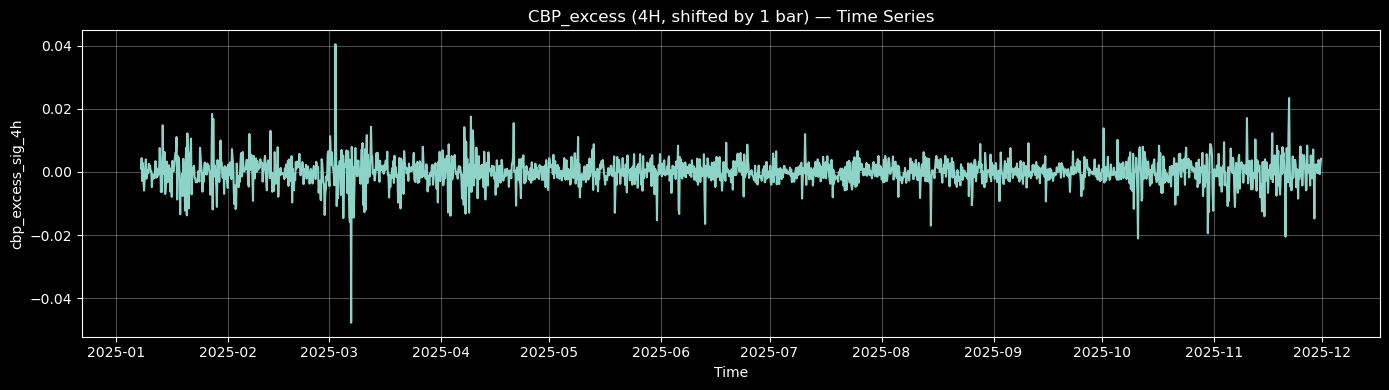

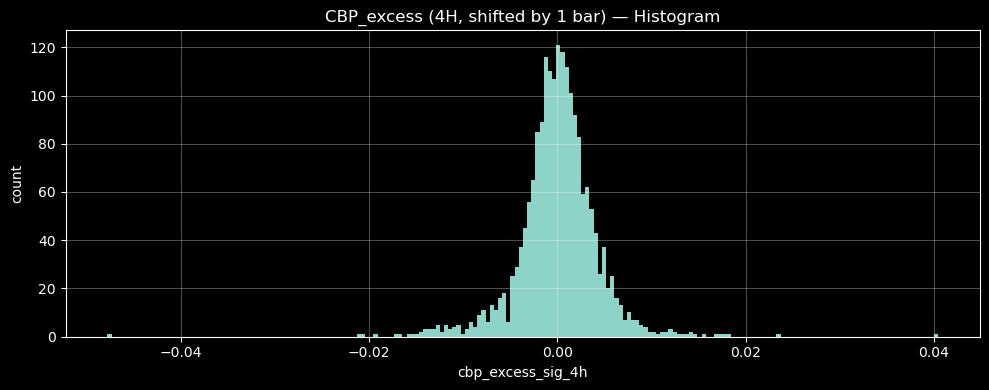

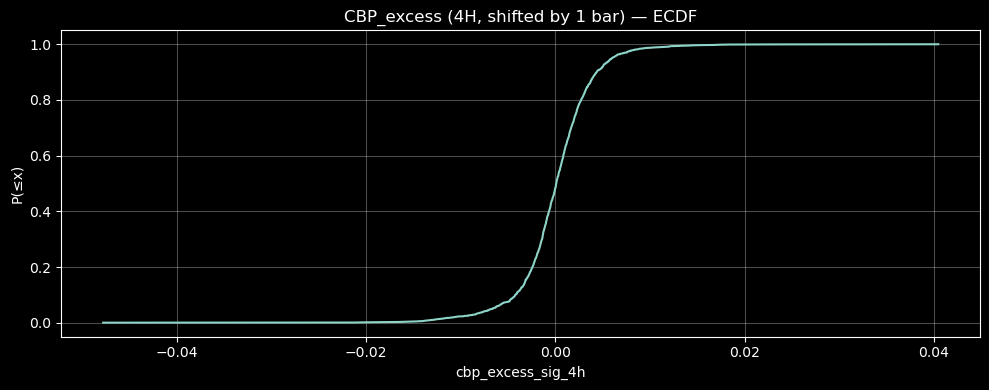


Tail frequencies (CBP_excess 4H shifted):
|excess|>0.20%:  P(>+th)=26.63%,  P(<-th)=23.72%, total=50.36%
|excess|>0.30%:  P(>+th)=18.11%,  P(<-th)=15.92%, total=34.03%
|excess|>0.50%:  P(>+th)=8.06%,  P(<-th)=7.50%, total=15.56%
|excess|>0.75%:  P(>+th)=3.01%,  P(<-th)=4.08%, total=7.09%
|excess|>1.00%:  P(>+th)=1.28%,  P(<-th)=2.30%, total=3.57%
|excess|>1.50%:  P(>+th)=0.36%,  P(<-th)=0.41%, total=0.77%
|excess|>2.00%:  P(>+th)=0.10%,  P(<-th)=0.15%, total=0.26%


In [106]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cbp_excess(panel_4h, col="cbp_excess_sig_4h",
                    bins=200,
                    thresholds=(0.002,0.003,0.005,0.0075,0.01,0.015,0.02),
                    time_figsize=(14,4), hist_figsize=(10,4), ecdf_figsize=(10,4)):

    p = panel_4h.copy().sort_index()
    x = p[col].dropna().astype(float)

    # --- Time series ---
    plt.figure(figsize=time_figsize)
    plt.plot(x.index, x.values)
    plt.title("CBP_excess (4H, shifted by 1 bar) — Time Series")
    plt.xlabel("Time"); plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Histogram ---
    plt.figure(figsize=hist_figsize)
    plt.hist(x.values, bins=bins)
    plt.title("CBP_excess (4H, shifted by 1 bar) — Histogram")
    plt.xlabel(col); plt.ylabel("count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- ECDF ---
    xs = np.sort(x.values)
    ys = np.arange(1, len(xs)+1) / len(xs)
    plt.figure(figsize=ecdf_figsize)
    plt.plot(xs, ys)
    plt.title("CBP_excess (4H, shifted by 1 bar) — ECDF")
    plt.xlabel(col); plt.ylabel("P(≤x)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # --- Tail frequencies ---
    print("\nTail frequencies (CBP_excess 4H shifted):")
    for th in thresholds:
        p_pos = (x > th).mean()
        p_neg = (x < -th).mean()
        print(f"|excess|>{th:.2%}:  P(>+th)={p_pos:.2%},  P(<-th)={p_neg:.2%}, total={p_pos+p_neg:.2%}")

# run
plot_cbp_excess(panel_4h, col="cbp_excess_sig_4h")

In [28]:
def wma(x: pd.Series, n: int) -> pd.Series:
    n = int(n)
    w = np.arange(1, n+1, dtype=float)
    return x.rolling(n).apply(lambda v: np.dot(v, w)/w.sum(), raw=True)

def hma(x: pd.Series, n: int) -> pd.Series:
    n = int(n)
    half = max(1, n//2)
    sqrt_n = max(1, int(np.sqrt(n)))
    return wma(2*wma(x, half) - wma(x, n), sqrt_n)

def add_hma_regime(df: pd.DataFrame, src_col: str, n_fast=19, n_slow=44, prefix="px"):
    out = df.copy()
    src = pd.to_numeric(out[src_col], errors="coerce")
    out[f"hma_{prefix}_fast"] = hma(src, n_fast)
    out[f"hma_{prefix}_slow"] = hma(src, n_slow)
    out[f"trend_{prefix}"] = np.sign(out[f"hma_{prefix}_fast"] - out[f"hma_{prefix}_slow"])\
                              .replace(0, np.nan).ffill().fillna(0.0)
    return out

p = panel_4h.copy().sort_index()

# Price regime
p = add_hma_regime(p, src_col="okx_close_4h", n_fast=19, n_slow=44, prefix="close")

# Volume regime (choose vol_quote if available)
vol_src = "vol_quote" if "vol_quote" in p.columns else ("vol" if "vol" in p.columns else None)
if vol_src is not None:
    p = add_hma_regime(p, src_col=vol_src, n_fast=19, n_slow=44, prefix="vol")
else:
    print("No volume column found for volume HMA regime.")

In [29]:
p["ret_fwd_4h"] = np.log(p["okx_close_4h"]).shift(-1) - np.log(p["okx_close_4h"])
p = p.dropna(subset=["cbp_excess_sig_4h","ret_fwd_4h","trend_close"])

def quadrant_table(df: pd.DataFrame, tau: float, trend_col: str):
    d = df.copy()
    d["event"] = np.where(d["cbp_excess_sig_4h"] > tau, +1,
                 np.where(d["cbp_excess_sig_4h"] < -tau, -1, 0))
    rows=[]
    for tr in [+1,-1]:
        for ev in [+1,-1]:
            mask = (d[trend_col] == tr) & (d["event"] == ev)
            r = d.loc[mask, "ret_fwd_4h"].dropna()
            rows.append({
                "trend": tr,
                "event": ev,
                "n": int(r.shape[0]),
                "mean_ret": float(r.mean()) if len(r) else np.nan,
                "median_ret": float(r.median()) if len(r) else np.nan,
            })
    return pd.DataFrame(rows)

# pick a few taus (4H events should use larger thresholds than 1H usually)
taus = [0.005, 0.0075, 0.01, 0.015]  # 50, 75, 100, 150 bps

for tau in taus:
    print("\n=== Quadrants using PRICE trend regime, tau =", tau, "===")
    print(quadrant_table(p, tau=tau, trend_col="trend_close"))


=== Quadrants using PRICE trend regime, tau = 0.005 ===
   trend  event   n  mean_ret  median_ret
0      1      1  65  0.002070   -0.000079
1      1     -1  62 -0.001895   -0.001274
2     -1      1  90  0.000679    0.001501
3     -1     -1  80 -0.000425   -0.001052

=== Quadrants using PRICE trend regime, tau = 0.0075 ===
   trend  event   n  mean_ret  median_ret
0      1      1  23  0.000712    0.001077
1      1     -1  34 -0.001028   -0.000492
2     -1      1  34 -0.000135    0.002612
3     -1     -1  46  0.000827   -0.000880

=== Quadrants using PRICE trend regime, tau = 0.01 ===
   trend  event   n  mean_ret  median_ret
0      1      1  11  0.001696    0.003602
1      1     -1  16  0.000596   -0.000733
2     -1      1  13 -0.000694    0.002190
3     -1     -1  29  0.001802   -0.001143

=== Quadrants using PRICE trend regime, tau = 0.015 ===
   trend  event  n  mean_ret  median_ret
0      1      1  3 -0.002370    0.004034
1      1     -1  4  0.006222    0.006010
2     -1      1  4 

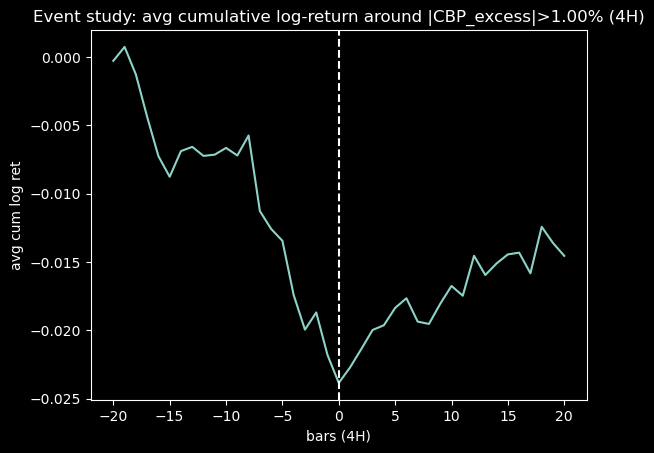

In [30]:
def event_study(df, tau=0.01, k=6):
    # k=6 means 6 bars forward/back => 24 hours each side in 4H bars
    d = df.dropna(subset=["cbp_excess_sig_4h","okx_close_4h"]).copy()
    r = np.log(d["okx_close_4h"]).diff()

    ev_idx = d.index[(d["cbp_excess_sig_4h"].abs() > tau)]
    ev_idx = ev_idx.intersection(r.index)

    mats=[]
    for t in ev_idx:
        loc = r.index.get_loc(t)
        if isinstance(loc, slice): 
            continue
        if loc-k < 1 or loc+k >= len(r): 
            continue
        window = r.iloc[loc-k:loc+k+1].values
        mats.append(window)

    if not mats:
        print("No events found for this tau.")
        return

    M = np.vstack(mats)
    avg = M.mean(axis=0)
    cum = np.cumsum(avg)

    xs = np.arange(-k, k+1)
    plt.figure()
    plt.plot(xs, cum)
    plt.axvline(0, linestyle="--")
    plt.title(f"Event study: avg cumulative log-return around |CBP_excess|>{tau:.2%} (4H)")
    plt.xlabel("bars (4H)"); plt.ylabel("avg cum log ret")
    plt.show()

event_study(p, tau=0.01, k=20)

In [31]:
import numpy as np
import pandas as pd

def wma(x: pd.Series, n: int) -> pd.Series:
    n = int(n)
    w = np.arange(1, n+1, dtype=float)
    return x.rolling(n).apply(lambda v: np.dot(v, w)/w.sum(), raw=True)

def hma(x: pd.Series, n: int) -> pd.Series:
    n = int(n)
    half = max(1, n//2)
    sqrt_n = max(1, int(np.sqrt(n)))
    return wma(2*wma(x, half) - wma(x, n), sqrt_n)

p = panel_4h.copy().sort_index()

# HMA on 4H close
p["hma_fast_close"] = hma(p["okx_close_4h"].astype(float), 19)
p["hma_slow_close"] = hma(p["okx_close_4h"].astype(float), 44)

# regime label
p["trend_close"] = np.sign(p["hma_fast_close"] - p["hma_slow_close"]).replace(0, np.nan).ffill().fillna(0.0)

# (optional) trend strength (helps filtering)
p["hma_gap"] = (p["hma_fast_close"] - p["hma_slow_close"]) / p["okx_close_4h"]

In [32]:
import numpy as np

# returns
p["ret_4h"] = np.log(p["okx_close_4h"]).diff()

tau = 0.005  # start with 0.5%

# event sign (CBP_excess shifted)
p["event"] = np.where(p["cbp_excess_sig_4h"] > tau, +1,
             np.where(p["cbp_excess_sig_4h"] < -tau, -1, 0))

# Rule A: event-only directional (no HMA)
p["pos_A"] = p["event"]

# Rule B: confluence (event must align with trend)
p["pos_B"] = np.where((p["event"] != 0) & (p["event"] == p["trend_close"]), p["event"], 0)

# Rule C: mean-revert within trend regime (fade event when aligned)
p["pos_C"] = np.where((p["event"] != 0) & (p["event"] == p["trend_close"]), -p["event"], 0)

In [33]:
def eval_rule(pos_col, fee_taker=0.0004, slip=0.0003):
    d = p[[pos_col, "ret_4h"]].dropna().copy()
    d["pos_lag"] = d[pos_col].shift(1).fillna(0.0)

    # cost on position change (enter/exit/flip)
    rt = fee_taker + slip
    d["turnover"] = (d["pos_lag"] - d["pos_lag"].shift(1).fillna(0.0)).abs()
    d["cost"] = rt * d["turnover"]

    d["strat_ret"] = d["pos_lag"] * d["ret_4h"] - d["cost"]
    eq = (1 + d["strat_ret"].fillna(0)).cumprod()

    sharpe = d["strat_ret"].mean()/(d["strat_ret"].std(ddof=0)+1e-12) * np.sqrt(365*6)  # 6 bars/day
    return {
        "pos": pos_col,
        "freq_in_pos": float((d["pos_lag"]!=0).mean()),
        "turnover_mean": float(d["turnover"].mean()),
        "mean_net": float(d["strat_ret"].mean()),
        "sharpe_net": float(sharpe),
        "final_equity": float(eq.iloc[-1]),
    }

for col in ["pos_A","pos_B","pos_C"]:
    print(eval_rule(col))

{'pos': 'pos_A', 'freq_in_pos': 0.15569167942827974, 'turnover_mean': 0.262378764675855, 'mean_net': -3.384909250603452e-05, 'sharpe_net': -0.33271838768553186, 'final_equity': 0.9153790156761982}
{'pos': 'pos_B', 'freq_in_pos': 0.07401735579377233, 'turnover_mean': 0.12149055640632976, 'mean_net': 1.009193609190017e-06, 'sharpe_net': 0.013273027956259823, 'final_equity': 0.9897021954131665}
{'pos': 'pos_C', 'freq_in_pos': 0.07401735579377233, 'turnover_mean': 0.12149055640632976, 'mean_net': -0.0001710959725780516, 'sharpe_net': -2.2299876594860706, 'final_equity': 0.706130243565489}


In [34]:
taus = [0.005,0.0075,0.01,0.015,0.02]  # 50,75,100,150,200 bps
rows=[]
for tau in taus:
    p2 = p.copy()
    p2["event"] = np.where(p2["cbp_excess_sig_4h"] > tau, +1,
                  np.where(p2["cbp_excess_sig_4h"] < -tau, -1, 0))
    p2["pos_A"] = p2["event"]
    p2["pos_B"] = np.where((p2["event"]!=0) & (p2["event"]==p2["trend_close"]), p2["event"], 0)

    a = eval_rule("pos_A")
    b = eval_rule("pos_B")
    rows.append([tau, a["freq_in_pos"], a["final_equity"], a["sharpe_net"],
                      b["freq_in_pos"], b["final_equity"], b["sharpe_net"]])

print(pd.DataFrame(rows, columns=[
    "tau","freq_A","eq_A","sh_A","freq_B","eq_B","sh_B"
]))

      tau    freq_A      eq_A      sh_A    freq_B      eq_B      sh_B
0  0.0050  0.155692  0.915379 -0.332718  0.074017  0.989702  0.013273
1  0.0075  0.155692  0.915379 -0.332718  0.074017  0.989702  0.013273
2  0.0100  0.155692  0.915379 -0.332718  0.074017  0.989702  0.013273
3  0.0150  0.155692  0.915379 -0.332718  0.074017  0.989702  0.013273
4  0.0200  0.155692  0.915379 -0.332718  0.074017  0.989702  0.013273


In [35]:
gap_th = p["hma_gap"].abs().quantile(0.7)  # try 0.6~0.85
p["pos_B_strong"] = np.where(
    (p["event"]!=0) &
    (p["event"]==p["trend_close"]) &
    (p["hma_gap"].abs() > gap_th),
    p["event"], 0
)
print(eval_rule("pos_B_strong"))

{'pos': 'pos_B_strong', 'freq_in_pos': 0.03777437468095967, 'turnover_mean': 0.062276671771311895, 'mean_net': -9.151024702853579e-06, 'sharpe_net': -0.1694531305367078, 'final_equity': 0.9760934894705315}


In [36]:
import numpy as np
import pandas as pd

def eval_rule_df(df: pd.DataFrame, pos_col: str, fee_taker=0.0004, slip=0.0003):
    d = df[[pos_col, "ret_4h"]].dropna().copy()
    d["pos_lag"] = d[pos_col].shift(1).fillna(0.0)

    # turnover on position change (enter/exit/flip)
    d["turnover"] = (d["pos_lag"] - d["pos_lag"].shift(1).fillna(0.0)).abs()

    # cost per unit turnover (taker+slip per side approximation)
    rt = fee_taker + slip
    d["cost"] = rt * d["turnover"]

    d["strat_ret"] = d["pos_lag"] * d["ret_4h"] - d["cost"]
    eq = (1.0 + d["strat_ret"].fillna(0.0)).cumprod()

    sharpe = d["strat_ret"].mean() / (d["strat_ret"].std(ddof=0) + 1e-12) * np.sqrt(365*6)
    return {
        "pos": pos_col,
        "freq_in_pos": float((d["pos_lag"] != 0).mean()),
        "turnover_mean": float(d["turnover"].mean()),
        "mean_net": float(d["strat_ret"].mean()),
        "sharpe_net": float(sharpe),
        "final_equity": float(eq.iloc[-1]),
    }

def make_positions(df: pd.DataFrame, tau: float):
    q = df.copy()
    q["event"] = np.where(q["cbp_excess_sig_4h"] > tau, +1,
                 np.where(q["cbp_excess_sig_4h"] < -tau, -1, 0))
    q["pos_A"] = q["event"]
    q["pos_B"] = np.where((q["event"] != 0) & (q["event"] == q["trend_close"]), q["event"], 0)
    q["pos_C"] = np.where((q["event"] != 0) & (q["event"] == q["trend_close"]), -q["event"], 0)
    return q

# ===== sweep (should now change with tau) =====
taus = [0.005,0.0075,0.01,0.015,0.02]
rows=[]
for tau in taus:
    q = make_positions(p, tau)
    a = eval_rule_df(q, "pos_A")
    b = eval_rule_df(q, "pos_B")
    rows.append([tau, a["freq_in_pos"], a["final_equity"], a["sharpe_net"],
                      b["freq_in_pos"], b["final_equity"], b["sharpe_net"]])

print(pd.DataFrame(rows, columns=["tau","freq_A","eq_A","sh_A","freq_B","eq_B","sh_B"]))

      tau    freq_A      eq_A      sh_A    freq_B      eq_B      sh_B
0  0.0050  0.155692  0.915379 -0.332718  0.074017  0.989702  0.013273
1  0.0075  0.070955  0.835500 -1.232106  0.035222  0.893821 -0.975849
2  0.0100  0.035733  0.864065 -1.314396  0.020419  0.912666 -0.964823
3  0.0150  0.007657  0.969382 -0.830200  0.003573  0.998711 -0.036538
4  0.0200  0.002552  1.001193  0.073185  0.001021  1.008283  1.110115


In [37]:
fast_list = [10, 14, 19, 26]
slow_list = [30, 44, 60, 80]
taus = [0.005, 0.0075, 0.01, 0.015]

best = []
for nf in fast_list:
    for ns in slow_list:
        if nf >= ns: 
            continue

        q = p.copy()
        # rebuild trend_close with these params
        q["hma_fast_close"] = hma(q["okx_close_4h"].astype(float), nf)
        q["hma_slow_close"] = hma(q["okx_close_4h"].astype(float), ns)
        q["trend_close"] = np.sign(q["hma_fast_close"] - q["hma_slow_close"]).replace(0, np.nan).ffill().fillna(0.0)

        for tau in taus:
            qq = make_positions(q, tau)
            out = eval_rule_df(qq, "pos_B")
            best.append([nf, ns, tau, out["freq_in_pos"], out["sharpe_net"], out["final_equity"]])

res = pd.DataFrame(best, columns=["n_fast","n_slow","tau","freq","sharpe_net","final_equity"])
print(res.sort_values(["sharpe_net","final_equity"], ascending=False).head(20))

    n_fast  n_slow    tau      freq  sharpe_net  final_equity
23      14      44  0.015  0.003573    1.218775      1.020680
27      14      60  0.015  0.003573    1.218775      1.020680
59      26      60  0.015  0.003573    1.218775      1.020680
15      10      80  0.015  0.003573    1.214386      1.020597
31      14      80  0.015  0.003063    1.177058      1.019875
43      19      60  0.015  0.003063    1.177058      1.019875
47      19      80  0.015  0.003063    1.177058      1.019875
55      26      44  0.015  0.003063    1.177058      1.019875
63      26      80  0.015  0.003063    1.177058      1.019875
24      14      60  0.005  0.075549    0.650441      1.082865
52      26      44  0.005  0.072486    0.610718      1.084668
12      10      80  0.005  0.074528    0.589489      1.070957
40      19      60  0.005  0.074017    0.549979      1.068231
28      14      80  0.005  0.074528    0.500593      1.058756
8       10      60  0.005  0.077080    0.481000      1.057842
44      

#### Add regime filters: high vol / high volume / US cash-session overlap

In [38]:
import numpy as np
import pandas as pd
from zoneinfo import ZoneInfo

def add_filters_4h(p: pd.DataFrame,
                   vol_col="vol_quote",
                   atr_n=14,
                   vol_lookback=42,     # 7 days of 4H bars
                   vol_q=0.7,
                   rvol_span=42):
    d = p.copy().sort_index()

    # --- columns mapping (adjust if needed) ---
    # Expecting OKX 4H OHLC columns exist from resample: open/high/low and okx_close_4h
    if "okx_close_4h" not in d.columns:
        raise ValueError("Missing okx_close_4h")
    if "high" not in d.columns or "low" not in d.columns:
        raise ValueError("Need 4H high/low columns named 'high'/'low' in panel_4h")
    if "open" not in d.columns:
        # if your resample kept 'open' as open, good; otherwise rename accordingly
        print("Warning: no 'open' column; entries will use close instead of next open.")

    close = d["okx_close_4h"].astype(float)
    high  = d["high"].astype(float)
    low   = d["low"].astype(float)
    prev_close = close.shift(1)

    # --- ATR (Wilder) ---
    tr = np.maximum(high - low, np.maximum((high - prev_close).abs(), (low - prev_close).abs()))
    d["atr"] = tr.ewm(alpha=1/atr_n, adjust=False).mean()
    d["atr_pct"] = d["atr"] / close

    # high-vol filter: atr_pct above rolling quantile
    d["high_vol"] = d["atr_pct"] > d["atr_pct"].rolling(vol_lookback).quantile(vol_q)

    # --- high-volume / RVOL ---
    if vol_col in d.columns:
        v = d[vol_col].astype(float)
        d["log_vol"] = np.log1p(v)
        d["rvol"] = d["log_vol"] / (d["log_vol"].ewm(span=rvol_span, adjust=False).mean() + 1e-12)
        d["high_volume"] = d["rvol"] > 1.10  # tune 1.05~1.30
    else:
        d["high_volume"] = True  # fallback

    # --- US cash session overlap (ET 09:30–16:00) ---
    et = ZoneInfo("America/New_York")

    def overlaps_us_cash(t_close_utc: pd.Timestamp) -> bool:
        # bar interval [t_close-4h, t_close)
        t1 = t_close_utc
        t0 = t1 - pd.Timedelta(hours=4)
        # convert endpoints to ET for session construction
        t0_et = t0.tz_convert(et)
        t1_et = t1.tz_convert(et)

        # session windows for each date potentially overlapped (t0 and t1 can cross midnight)
        dates = {t0_et.date(), t1_et.date()}
        for dt in dates:
            sess_start = pd.Timestamp(dt).tz_localize(et) + pd.Timedelta(hours=9, minutes=30)
            sess_end   = pd.Timestamp(dt).tz_localize(et) + pd.Timedelta(hours=16, minutes=0)
            # overlap check in ET then compare
            latest_start = max(t0_et, sess_start)
            earliest_end = min(t1_et, sess_end)
            if latest_start < earliest_end:
                return True
        return False

    d["us_cash_overlap"] = [overlaps_us_cash(t) for t in d.index]

    return d

In [39]:
def build_pos_confluence(df: pd.DataFrame, tau=0.005,
                         use_us=True, use_high_vol=True, use_high_volume=True):
    d = df.copy()

    # event sign from CBP_excess (shifted)
    d["event"] = np.where(d["cbp_excess_sig_4h"] > tau, +1,
                 np.where(d["cbp_excess_sig_4h"] < -tau, -1, 0))

    filt = (d["event"] != 0)
    if use_us:         filt &= d["us_cash_overlap"]
    if use_high_vol:   filt &= d["high_vol"]
    if use_high_volume:filt &= d["high_volume"]

    # confluence: only trade when event aligns with trend
    d["pos"] = np.where(filt & (d["event"] == d["trend_close"]), d["event"], 0.0)
    return d

In [40]:
def compute_atr_wilder(close, high, low, n):
    prev_close = close.shift(1)
    tr = np.maximum(high-low, np.maximum((high-prev_close).abs(), (low-prev_close).abs()))
    return tr.ewm(alpha=1/n, adjust=False).mean()

def backtest_atr_sl_tp(df: pd.DataFrame,
                       fee_taker=0.0004,
                       slip=0.0001,
                       sl_atr_n=2, tp_atr_n=5,
                       sl_mult=1.0, tp_mult=1.0):
    d = df.copy().sort_index()

    close = d["okx_close_4h"].astype(float)
    high  = d["high"].astype(float)
    low   = d["low"].astype(float)
    openp = d["open"].astype(float) if "open" in d.columns else close  # fallback

    d["atr_sl"] = compute_atr_wilder(close, high, low, sl_atr_n)
    d["atr_tp"] = compute_atr_wilder(close, high, low, tp_atr_n)

    # enter at next bar open using signal from previous bar
    sig = d["pos"].shift(1).fillna(0.0)

    equity = 1.0
    eq_curve = []
    in_pos = 0
    entry = np.nan

    # cost per turnover (enter/exit/flip)
    rt = fee_taker + slip

    for i in range(1, len(d)-1):
        t = d.index[i]

        # entry/flip logic at bar open
        desired = int(sig.iloc[i])
        if in_pos != desired:
            # turnover cost on change
            equity *= (1 - rt * abs(desired - in_pos))
            in_pos = desired
            if in_pos != 0:
                entry = openp.iloc[i]
            else:
                entry = np.nan

        # manage position within the bar using high/low
        if in_pos != 0:
            sl = sl_mult * d["atr_sl"].iloc[i]
            tp = tp_mult * d["atr_tp"].iloc[i]

            if np.isnan(sl) or np.isnan(tp) or np.isnan(entry):
                eq_curve.append(equity); 
                continue

            if in_pos == +1:
                stop_px = entry - sl
                take_px = entry + tp
                hit_stop = (low.iloc[i] <= stop_px)
                hit_take = (high.iloc[i] >= take_px)
            else:
                stop_px = entry + sl
                take_px = entry - tp
                hit_stop = (high.iloc[i] >= stop_px)
                hit_take = (low.iloc[i] <= take_px)

            # conservative ordering if both hit
            exit_px = None
            if hit_stop and hit_take:
                exit_px = stop_px
            elif hit_stop:
                exit_px = stop_px
            elif hit_take:
                exit_px = take_px

            if exit_px is not None:
                # exit at exit_px inside bar
                ret = np.log(exit_px / entry) * in_pos
                equity *= np.exp(ret)
                equity *= (1 - rt * 1.0)  # pay cost to exit
                in_pos = 0
                entry = np.nan

        eq_curve.append(equity)

    out = d.iloc[1:1+len(eq_curve)].copy()
    out["equity"] = eq_curve
    return out

In [41]:
p2 = add_filters_4h(p, vol_col="vol_quote", atr_n=14)

# choose your HMA trend already computed into p2["trend_close"]
# choose tau and filters
dpos = build_pos_confluence(p2, tau=0.01, use_us=True, use_high_vol=True, use_high_volume=False)

bt = backtest_atr_sl_tp(dpos, fee_taker=0.00004, slip=0.00001,
                        sl_atr_n=2, tp_atr_n=5, sl_mult=1.0, tp_mult=1.0)

print("Final equity:", float(bt["equity"].iloc[-1]))

Final equity: 1.073372009399963


In [42]:
import numpy as np

d = dpos.copy().sort_index()   # this is the filtered dataframe you fed into backtest
pos_exec = d["pos"].shift(1).fillna(0.0)  # position actually held during the bar

entries = ((pos_exec != 0) & (pos_exec.shift(1).fillna(0.0) == 0)).sum()
exits   = ((pos_exec == 0) & (pos_exec.shift(1).fillna(0.0) != 0)).sum()
flips   = ((pos_exec != 0) & (pos_exec.shift(1).fillna(0.0) != 0) & (pos_exec != pos_exec.shift(1))).sum()

bars_in_pos = (pos_exec != 0).sum()
print("Entries:", int(entries), "Exits:", int(exits), "Flips:", int(flips))
print("Bars in position:", int(bars_in_pos), " (~hours:", int(bars_in_pos)*4, ")")

Entries: 16 Exits: 16 Flips: 0
Bars in position: 16  (~hours: 64 )


In [43]:
import numpy as np
import pandas as pd

def compute_atr_wilder(close, high, low, n):
    prev_close = close.shift(1)
    tr = np.maximum(high-low, np.maximum((high-prev_close).abs(), (low-prev_close).abs()))
    return tr.ewm(alpha=1/n, adjust=False).mean()

def backtest_atr_sl_tp_with_log(df: pd.DataFrame,
                                fee_taker=0.0004, slip=0.0003,
                                sl_atr_n=2, tp_atr_n=5,
                                sl_mult=1.0, tp_mult=1.0):
    d = df.copy().sort_index()

    close = d["okx_close_4h"].astype(float)
    high  = d["high"].astype(float)
    low   = d["low"].astype(float)
    openp = d["open"].astype(float) if "open" in d.columns else close

    d["atr_sl"] = compute_atr_wilder(close, high, low, sl_atr_n)
    d["atr_tp"] = compute_atr_wilder(close, high, low, tp_atr_n)

    # enter at next bar open using previous bar signal
    sig = d["pos"].shift(1).fillna(0.0)

    rt = fee_taker + slip

    equity = 1.0
    eq_curve = []
    trades = []

    in_pos = 0
    entry_px = np.nan
    entry_time = None

    for i in range(1, len(d)):
        t = d.index[i]

        # 1) signal-driven entry/flip at bar open
        desired = int(sig.iloc[i])

        if in_pos != desired:
            # if we are closing an existing position due to flip-to-0 or flip-to-opposite
            if in_pos != 0:
                exit_px = openp.iloc[i]  # exit at open
                gross_logret = np.log(exit_px / entry_px) * in_pos
                equity *= np.exp(gross_logret)
                equity *= (1 - rt)  # pay exit cost

                trades.append({
                    "entry_time": entry_time, "exit_time": t,
                    "side": in_pos,
                    "entry_px": float(entry_px), "exit_px": float(exit_px),
                    "exit_reason": "signal",
                    "gross_logret": float(gross_logret),
                })
                in_pos = 0
                entry_px = np.nan
                entry_time = None

            # open new position if desired != 0
            if desired != 0:
                equity *= (1 - rt)  # pay entry cost
                in_pos = desired
                entry_px = openp.iloc[i]
                entry_time = t

        # 2) manage ATR SL/TP inside the bar (if in position)
        if in_pos != 0:
            atr_sl = d["atr_sl"].iloc[i]
            atr_tp = d["atr_tp"].iloc[i]
            if np.isfinite(atr_sl) and np.isfinite(atr_tp) and np.isfinite(entry_px):
                sl = sl_mult * atr_sl
                tp = tp_mult * atr_tp

                if in_pos == +1:
                    stop_px = entry_px - sl
                    take_px = entry_px + tp
                    hit_stop = (low.iloc[i] <= stop_px)
                    hit_take = (high.iloc[i] >= take_px)
                else:
                    stop_px = entry_px + sl
                    take_px = entry_px - tp
                    hit_stop = (high.iloc[i] >= stop_px)
                    hit_take = (low.iloc[i] <= take_px)

                exit_px = None
                reason = None
                # conservative: stop first if both hit same bar
                if hit_stop and hit_take:
                    exit_px = stop_px
                    reason = "stop_and_take_samebar(stop_first)"
                elif hit_stop:
                    exit_px = stop_px
                    reason = "stop"
                elif hit_take:
                    exit_px = take_px
                    reason = "take"

                if exit_px is not None:
                    gross_logret = np.log(exit_px / entry_px) * in_pos
                    equity *= np.exp(gross_logret)
                    equity *= (1 - rt)  # pay exit cost

                    trades.append({
                        "entry_time": entry_time, "exit_time": t,
                        "side": in_pos,
                        "entry_px": float(entry_px), "exit_px": float(exit_px),
                        "exit_reason": reason,
                        "gross_logret": float(gross_logret),
                    })

                    in_pos = 0
                    entry_px = np.nan
                    entry_time = None

        eq_curve.append((t, equity))

    eq = pd.DataFrame(eq_curve, columns=["ts","equity"]).set_index("ts")
    tr = pd.DataFrame(trades)

    if len(tr):
        tr["net_logret"] = tr["gross_logret"] - (3 * (fee_taker + slip))  # rough: entry+exit(+maybe) cost; conservative-ish
        tr["holding_hours"] = (pd.to_datetime(tr["exit_time"]) - pd.to_datetime(tr["entry_time"])).dt.total_seconds() / 3600

    return eq, tr

# ===== RUN =====
eq, trades = backtest_atr_sl_tp_with_log(dpos, fee_taker=0.0004, slip=0.0003,
                                        sl_atr_n=2, tp_atr_n=5, sl_mult=1.0, tp_mult=1.0)

print("Final equity:", float(eq["equity"].iloc[-1]))
print("Trades:", len(trades))
if len(trades):
    print(trades["exit_reason"].value_counts())
    print("Win rate (gross):", float((trades["gross_logret"] > 0).mean()))
    print("Avg gross logret/trade:", float(trades["gross_logret"].mean()))
    print("Avg holding hours:", float(trades["holding_hours"].mean()))
    print("Median holding hours:", float(trades["holding_hours"].median()))

Final equity: 1.0465922790909712
Trades: 16
exit_reason
signal    13
take       3
Name: count, dtype: int64
Win rate (gross): 0.6875
Avg gross logret/trade: 0.004246705090924448
Avg holding hours: 3.25
Median holding hours: 4.0


In [44]:
import numpy as np
import pandas as pd

def make_pos_hma_cbp(p: pd.DataFrame, tau=0.005, mode="confluence"):
    """
    mode:
      - "confluence": trade when event aligns with trend
      - "event_only": trade purely on event sign (no trend filter)
    """
    d = p.copy().sort_index()

    # event sign from CBP_excess (shifted)
    d["event"] = np.where(d["cbp_excess_sig_4h"] > tau, +1,
                 np.where(d["cbp_excess_sig_4h"] < -tau, -1, 0))

    if mode == "confluence":
        d["pos"] = np.where((d["event"] != 0) & (d["event"] == d["trend_close"]), d["event"], 0.0)
    elif mode == "event_only":
        d["pos"] = d["event"].astype(float)
    else:
        raise ValueError("mode must be 'confluence' or 'event_only'")
    return d

# Example:
tau = 0.005  # start at 0.5% then sweep
dpos_noUS = make_pos_hma_cbp(p, tau=tau, mode="confluence")

In [45]:
eq, trades = backtest_atr_sl_tp_with_log(
    dpos_noUS,
    fee_taker=0.0004, slip=0.0001,
    sl_atr_n=1, tp_atr_n=2, sl_mult=1.0, tp_mult=1.0
)

print("Final equity:", float(eq["equity"].iloc[-1]))
print("Trades:", len(trades))
if len(trades):
    print(trades["exit_reason"].value_counts())
    print("Win rate (gross):", float((trades["gross_logret"] > 0).mean()))
    print("Avg gross logret/trade:", float(trades["gross_logret"].mean()))
    print("Avg holding hours:", float(trades["holding_hours"].mean()))
    print("Median holding hours:", float(trades["holding_hours"].median()))

Final equity: 1.096405673975893
Trades: 131
exit_reason
signal    110
take       18
stop        3
Name: count, dtype: int64
Win rate (gross): 0.4961832061068702
Avg gross logret/trade: 0.0017028245912246798
Avg holding hours: 3.786259541984733
Median holding hours: 4.0


In [46]:
taus = [0.003,0.005,0.0075,0.01]  # 30,50,75,100 bps

rows=[]
for tau in taus:
    dpos = make_pos_hma_cbp(p, tau=tau, mode="confluence")
    eq, tr = backtest_atr_sl_tp_with_log(
        dpos, fee_taker=0.0004, slip=0.0001,
        sl_atr_n=1, tp_atr_n=2, sl_mult=1.0, tp_mult=1.0
    )
    rows.append({
        "tau": tau,
        "final_equity": float(eq["equity"].iloc[-1]),
        "trades": int(len(tr)),
        "winrate_gross": float((tr["gross_logret"]>0).mean()) if len(tr) else np.nan,
        "avg_gross_per_trade": float(tr["gross_logret"].mean()) if len(tr) else np.nan,
        "median_hold_hr": float(tr["holding_hours"].median()) if len(tr) else np.nan,
    })

print(pd.DataFrame(rows).sort_values("final_equity", ascending=False))

      tau  final_equity  trades  winrate_gross  avg_gross_per_trade  \
1  0.0050      1.096406     131       0.496183             0.001703   
3  0.0100      0.937558      38       0.578947            -0.000697   
2  0.0075      0.934990      62       0.500000            -0.000084   
0  0.0030      0.849383     265       0.460377             0.000384   

   median_hold_hr  
1             4.0  
3             4.0  
2             4.0  
0             4.0  


#### So CBP_excess itself is the alpha, and HMA isn’t adding orthogonal information.

In [47]:
rows=[]
for tau in [0.003,0.005,0.0075,0.01]:
    for mode in ["confluence","event_only"]:
        dpos = make_pos_hma_cbp(p, tau=tau, mode=mode)
        eq, tr = backtest_atr_sl_tp_with_log(
            dpos, fee_taker=0.0004, slip=0.0001,
            sl_atr_n=2, tp_atr_n=2, sl_mult=1.0, tp_mult=1.0
        )
        rows.append([mode, tau, float(eq["equity"].iloc[-1]), len(tr)])

print(pd.DataFrame(rows, columns=["mode","tau","final_equity","trades"]).sort_values(["final_equity"], ascending=False))

         mode     tau  final_equity  trades
3  event_only  0.0050      1.162940     277
2  confluence  0.0050      1.081734     131
6  confluence  0.0100      0.932958      38
4  confluence  0.0075      0.923856      62
5  event_only  0.0075      0.913804     130
7  event_only  0.0100      0.903569      67
1  event_only  0.0030      0.834017     564
0  confluence  0.0030      0.819261     263


#### Is edge monotonic in $|CBP_{excess}|$?

In [48]:
q = p.copy().sort_index()
tau = 0.006
q["event"] = np.where(q["cbp_excess_sig_4h"] > tau, +1,
             np.where(q["cbp_excess_sig_4h"] < -tau, -1, 0))

# forward return of next bar
q["ret_fwd_4h"] = np.log(q["okx_close_4h"]).shift(-1) - np.log(q["okx_close_4h"])
q = q.dropna(subset=["cbp_excess_sig_4h","ret_fwd_4h"])

# keep only event bars
e = q[q["event"] != 0].copy()
e["abs_ex"] = e["cbp_excess_sig_4h"].abs()
e["signed_fwd"] = np.sign(e["cbp_excess_sig_4h"]) * e["ret_fwd_4h"]

e["bin"] = pd.qcut(e["abs_ex"], 10, duplicates="drop")
g = e.groupby("bin").agg(
    n=("signed_fwd","size"),
    mean_abs_ex=("abs_ex","mean"),
    mean_signed=("signed_fwd","mean"),
    median_signed=("signed_fwd","median"),
)
print(g)

                     n  mean_abs_ex  mean_signed  median_signed
bin                                                            
(0.00501, 0.00629]  22     0.006165     0.000004      -0.000098
(0.00629, 0.00662]  22     0.006459     0.003056      -0.000316
(0.00662, 0.00711]  21     0.006864     0.006448       0.004476
(0.00711, 0.00765]  22     0.007395     0.000092       0.003190
(0.00765, 0.00825]  22     0.007889     0.000453      -0.000227
(0.00825, 0.00887]  21     0.008506     0.004132       0.004957
(0.00887, 0.0104]   22     0.009555    -0.003017      -0.002137
(0.0104, 0.012]     21     0.011278    -0.001207      -0.002347
(0.012, 0.014]      22     0.012942     0.000298       0.002352
(0.014, 0.0478]     22     0.019265     0.001496       0.003446


/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3951655709.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = e.groupby("bin").agg(


In [49]:
tau_lo = 0.006
tau_hi = 0.010

q = p.copy().sort_index()
ex = q["cbp_excess_sig_4h"]
q["event_band"] = np.where((ex.abs() >= tau_lo) & (ex.abs() <= tau_hi), np.sign(ex), 0.0)

q["pos"] = q["event_band"]  # event-only but band-gated

eq, trades = backtest_atr_sl_tp_with_log(q, fee_taker=0.0004, slip=0.0001,
                                        sl_atr_n=1, tp_atr_n=2)

print("Final equity:", float(eq["equity"].iloc[-1]), "Trades:", len(trades))

Final equity: 1.297840403995094 Trades: 141


### William R% as filter

In [50]:
n = 5  # try 10, 14, 21 for 4H
q["hh"] = q["high"].rolling(n).max()
q["ll"] = q["low"].rolling(n).min()
q["wr"] = -100 * (q["hh"] - q["okx_close_4h"]) / (q["hh"] - q["ll"] + 1e-12)

# example: avoid extremes
gate = (q["wr"] > -80) & (q["wr"] < -20)
q["pos_wr_gate"] = np.where(gate, q["pos"], 0.0)

eq2, tr2 = backtest_atr_sl_tp_with_log(q.assign(pos=q["pos_wr_gate"]),
                                       fee_taker=0.0004, slip=0.0001,
                                       sl_atr_n=1, tp_atr_n=2)

print("WR-gated equity:", float(eq2["equity"].iloc[-1]), "Trades:", len(tr2))

WR-gated equity: 1.3130761106436146 Trades: 85


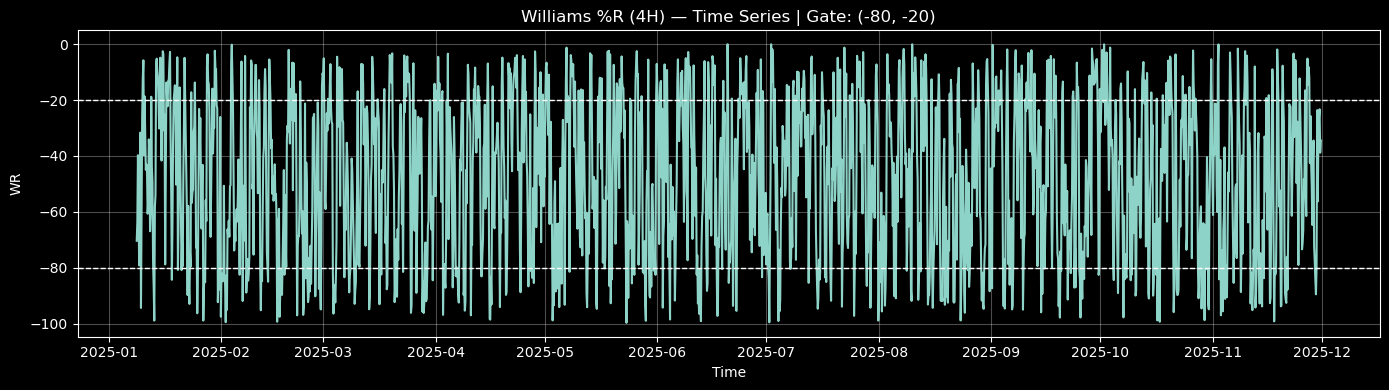

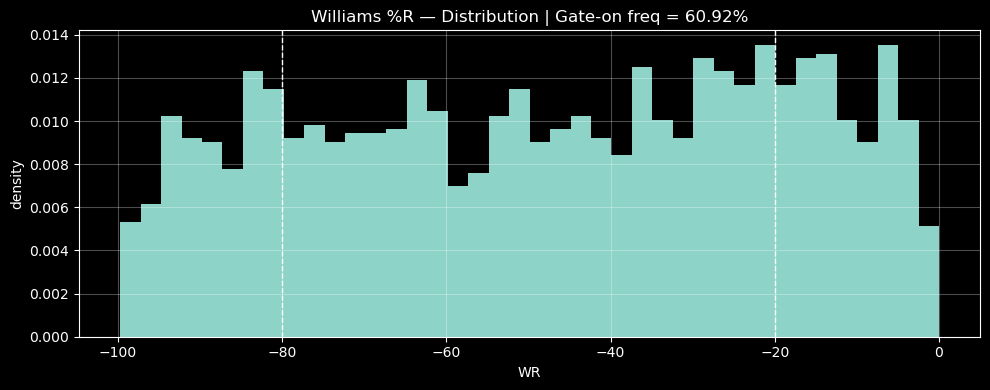

/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/2993072485.py:62: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = df.groupby("bin")["ret_fwd"].agg(["count", "mean", "std"])


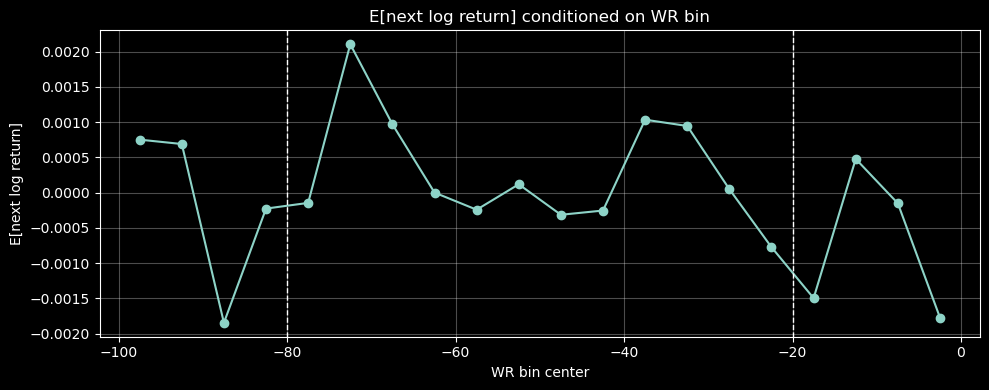

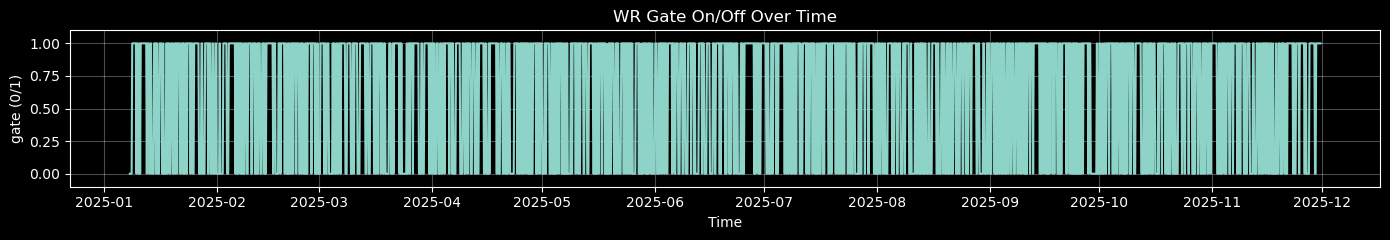

In [117]:
import numpy as np

# --- compute Williams %R on panel_4h ---
n_wr = 5 # try 10, 14, 21 for 4H
p = panel_4h.copy().sort_index()

p["hh"] = p["high"].rolling(n_wr, min_periods=n_wr).max()
p["ll"] = p["low"].rolling(n_wr, min_periods=n_wr).min()

den = (p["hh"] - p["ll"]).replace(0, np.nan)
p["wr"] = -100.0 * (p["hh"] - p["okx_close_4h"]) / (den + 1e-12)

# now it will work
gate, wr_cond = plot_wr_suite(
    p,
    wr_col="wr",
    price_col="okx_close_4h",
    pos_col="pos_cbp_wr",   # or None if you don't want position overlay
    gate_lo=-80, gate_hi=-20
)

In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_wr_suite(q: pd.DataFrame,
                  wr_col="wr",
                  price_col="okx_close_4h",
                  pos_col=None,                 # <- optional now
                  gate_lo=-80, gate_hi=-20,
                  bins=40):

    q = q.copy().sort_index()

    if wr_col not in q.columns:
        raise KeyError(f"Missing '{wr_col}'. Available: {list(q.columns)[:8]} ...")
    if price_col not in q.columns:
        raise KeyError(f"Missing '{price_col}'. Available: {list(q.columns)[:8]} ...")

    wr = q[wr_col].astype(float)
    gate = (wr > gate_lo) & (wr < gate_hi)

    # 1) WR time series + band
    plt.figure(figsize=(14,4))
    plt.plot(wr.index, wr.values)
    plt.axhline(gate_lo, linestyle="--", linewidth=1)
    plt.axhline(gate_hi, linestyle="--", linewidth=1)
    plt.title(f"Williams %R (4H) — Time Series | Gate: ({gate_lo}, {gate_hi})")
    plt.xlabel("Time"); plt.ylabel("WR")
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # (optional) overlay when in-position (very useful)
    if (pos_col is not None) and (pos_col in q.columns):
        in_pos = (q[pos_col].astype(float) != 0).reindex(wr.index).fillna(False)
        plt.figure(figsize=(14,2.5))
        plt.plot(in_pos.index, in_pos.astype(int).values)
        plt.title(f"In-position indicator from '{pos_col}' (0/1)")
        plt.xlabel("Time"); plt.ylabel("in_pos")
        plt.ylim(-0.1, 1.1)
        plt.grid(True, alpha=0.3)
        plt.tight_layout(); plt.show()

    # 2) WR distribution + gate freq
    plt.figure(figsize=(10,4))
    plt.hist(wr.dropna().values, bins=bins, density=True)
    plt.axvline(gate_lo, linestyle="--", linewidth=1)
    plt.axvline(gate_hi, linestyle="--", linewidth=1)
    plt.title(f"Williams %R — Distribution | Gate-on freq = {gate.mean():.2%}")
    plt.xlabel("WR"); plt.ylabel("density")
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # next-bar log return for conditional analysis
    px = q[price_col].astype(float)
    ret_fwd = np.log(px).diff().shift(-1)

    df = pd.DataFrame({"wr": wr, "ret_fwd": ret_fwd}).dropna()

    # 3) Conditional mean next-bar return by WR bins
    wr_bins = np.linspace(-100, 0, 21)
    df["bin"] = pd.cut(df["wr"], wr_bins, include_lowest=True)
    g = df.groupby("bin")["ret_fwd"].agg(["count", "mean", "std"])

    centers = np.array([(b.left + b.right)/2 for b in g.index.categories])
    plt.figure(figsize=(10,4))
    plt.plot(centers, g["mean"].values, marker="o")
    plt.axvline(gate_lo, linestyle="--", linewidth=1)
    plt.axvline(gate_hi, linestyle="--", linewidth=1)
    plt.title("E[next log return] conditioned on WR bin")
    plt.xlabel("WR bin center"); plt.ylabel("E[next log return]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    # 4) Gate on/off timeline
    plt.figure(figsize=(14,2.5))
    plt.plot(gate.index, gate.astype(int).values)
    plt.title("WR Gate On/Off Over Time")
    plt.xlabel("Time"); plt.ylabel("gate (0/1)")
    plt.ylim(-0.1, 1.1)
    plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    return gate, g

In [51]:
q = p.copy().sort_index()
ex = q["cbp_excess_sig_4h"]

# base direction
dir_ = np.sign(ex)

# bucketed leverage (tune bins based on your bin table)
lev = np.zeros(len(q))
absx = ex.abs().values

lev[(absx >= 0.006) & (absx < 0.0075)] = 1.0
lev[(absx >= 0.0075) & (absx <= 0.010)] = 1.5

# position
q["pos"] = dir_ * lev

eq, trades = backtest_atr_sl_tp_with_log(
    q, fee_taker=0.0004, slip=0.0001,
    sl_atr_n=1, tp_atr_n=2, sl_mult=1.0, tp_mult=1.0
)
print("Final equity:", float(eq["equity"].iloc[-1]), "Trades:", len(trades))

Final equity: 1.297840403995094 Trades: 141


In [52]:
import numpy as np
import pandas as pd

# eq is the equity curve DF returned by backtest_atr_sl_tp_with_log
# eq index should be tz-aware timestamps (UTC) at 4H bar times.
# eq has column "equity"

eq2 = eq.copy().sort_index()
eq2["ret"] = eq2["equity"].pct_change().fillna(0.0)

# Monthly returns (compounded)
monthly_ret = (1.0 + eq2["ret"]).resample("M").prod() - 1.0

# Monthly end equity
monthly_equity = eq2["equity"].resample("M").last()

# Monthly max drawdown (within month)
def max_drawdown(x):
    peak = x.cummax()
    dd = (x/peak - 1.0)
    return float(dd.min())

monthly_mdd = eq2["equity"].resample("M").apply(max_drawdown)

# Summary table
report = pd.DataFrame({
    "month_end_equity": monthly_equity,
    "monthly_return": monthly_ret,
    "monthly_max_drawdown": monthly_mdd,
})

print(report)

# Extra diagnostics
print("\nDiagnostics:")
print("Months:", report.shape[0])
print("Positive months:", int((report["monthly_return"] > 0).sum()))
print("Hit rate:", float((report["monthly_return"] > 0).mean()))
print("Best month:", float(report["monthly_return"].max()))
print("Worst month:", float(report["monthly_return"].min()))
print("Avg monthly:", float(report["monthly_return"].mean()))
print("Median monthly:", float(report["monthly_return"].median()))

                           month_end_equity  monthly_return  \
ts                                                            
2025-01-31 00:00:00+00:00          1.002801        0.002801   
2025-02-28 00:00:00+00:00          1.044582        0.041664   
2025-03-31 00:00:00+00:00          1.139237        0.090616   
2025-04-30 00:00:00+00:00          1.127860       -0.009987   
2025-05-31 00:00:00+00:00          1.132895        0.004464   
2025-06-30 00:00:00+00:00          1.115745       -0.015138   
2025-07-31 00:00:00+00:00          1.134439        0.016755   
2025-08-31 00:00:00+00:00          1.135380        0.000829   
2025-09-30 00:00:00+00:00          1.159282        0.021052   
2025-10-31 00:00:00+00:00          1.322511        0.140802   
2025-11-30 00:00:00+00:00          1.297840       -0.018654   

                           monthly_max_drawdown  
ts                                               
2025-01-31 00:00:00+00:00             -0.068753  
2025-02-28 00:00:00+00:00     

/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/1051541502.py:12: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ret = (1.0 + eq2["ret"]).resample("M").prod() - 1.0
/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/1051541502.py:15: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_equity = eq2["equity"].resample("M").last()
/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/1051541502.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mdd = eq2["equity"].resample("M").apply(max_drawdown)


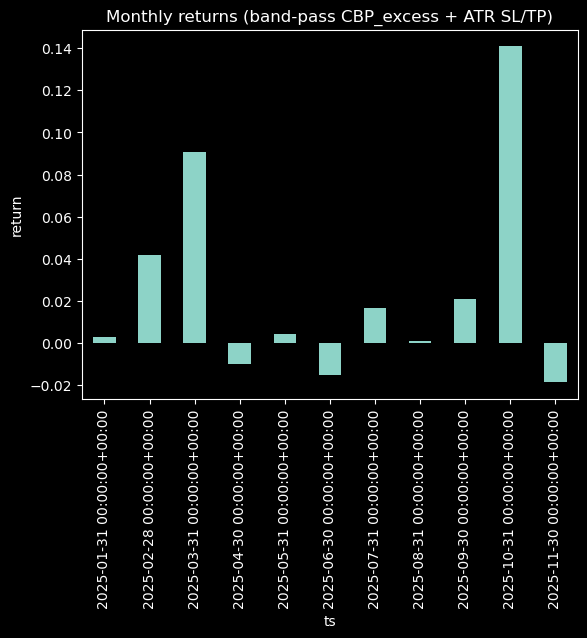

In [53]:
import matplotlib.pyplot as plt

plt.figure()
report["monthly_return"].plot(kind="bar")
plt.title("Monthly returns (band-pass CBP_excess + ATR SL/TP)")
plt.ylabel("return")
plt.show()

In [54]:
# 0) Start from CBP band-pass pos (your best)
q_base = p.copy().sort_index()
ex = q_base["cbp_excess_sig_4h"]

tau_lo, tau_hi = 0.006, 0.010
q_base["pos_cbp"] = np.where((ex.abs() >= tau_lo) & (ex.abs() <= tau_hi), np.sign(ex), 0.0)

# 1) Add WR gate on top of CBP pos
n = 5
q_base["hh"] = q_base["high"].rolling(n).max()
q_base["ll"] = q_base["low"].rolling(n).min()
q_base["wr"] = -100 * (q_base["hh"] - q_base["okx_close_4h"]) / (q_base["hh"] - q_base["ll"] + 1e-12)

gate = (q_base["wr"] > -80) & (q_base["wr"] < -20)
q_base["pos_cbp_wr"] = np.where(gate, q_base["pos_cbp"], 0.0)

# 2) WR-only (mean reversion example)
q_base["pos_wr_only"] = np.where(q_base["wr"] < -80, +1.0,
                        np.where(q_base["wr"] > -20, -1.0, 0.0))

# Backtest all 3
def run_pos(col):
    eqx, trx = backtest_atr_sl_tp_with_log(q_base.assign(pos=q_base[col]),
                                          fee_taker=0.0004, slip=0.0001,
                                          sl_atr_n=1, tp_atr_n=2)
    return float(eqx["equity"].iloc[-1]), len(trx)

for col in ["pos_cbp", "pos_cbp_wr", "pos_wr_only"]:
    eqv, ntr = run_pos(col)
    print(col, "equity:", eqv, "trades:", ntr)

pos_cbp equity: 1.297840403995094 trades: 141
pos_cbp_wr equity: 1.3130761106436146 trades: 85
pos_wr_only equity: 0.6821781203493953 trades: 483


In [55]:
# eq2, tr2 = backtest_atr_sl_tp_with_log(q_base.assign(pos=q_base["pos_cbp_wr"]), ...)

eq_cbp_wr = eq2.copy().sort_index()
eq_cbp_wr["ret"] = eq_cbp_wr["equity"].pct_change().fillna(0.0)

# --- 2) Monthly returns bar plot ---
monthly_ret = (1.0 + eq_cbp_wr["ret"]).resample("M").prod() - 1.0


# --- Optional: monthly end equity + summary table ---
monthly_equity = eq_cbp_wr["equity"].resample("M").last()

def max_drawdown(x):
    peak = x.cummax()
    dd = x / peak - 1.0
    return float(dd.min())

monthly_mdd = eq_cbp_wr["equity"].resample("M").apply(max_drawdown)

/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3450535655.py:7: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ret = (1.0 + eq_cbp_wr["ret"]).resample("M").prod() - 1.0
/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3450535655.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_equity = eq_cbp_wr["equity"].resample("M").last()
/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3450535655.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_mdd = eq_cbp_wr["equity"].resample("M").apply(max_drawdown)


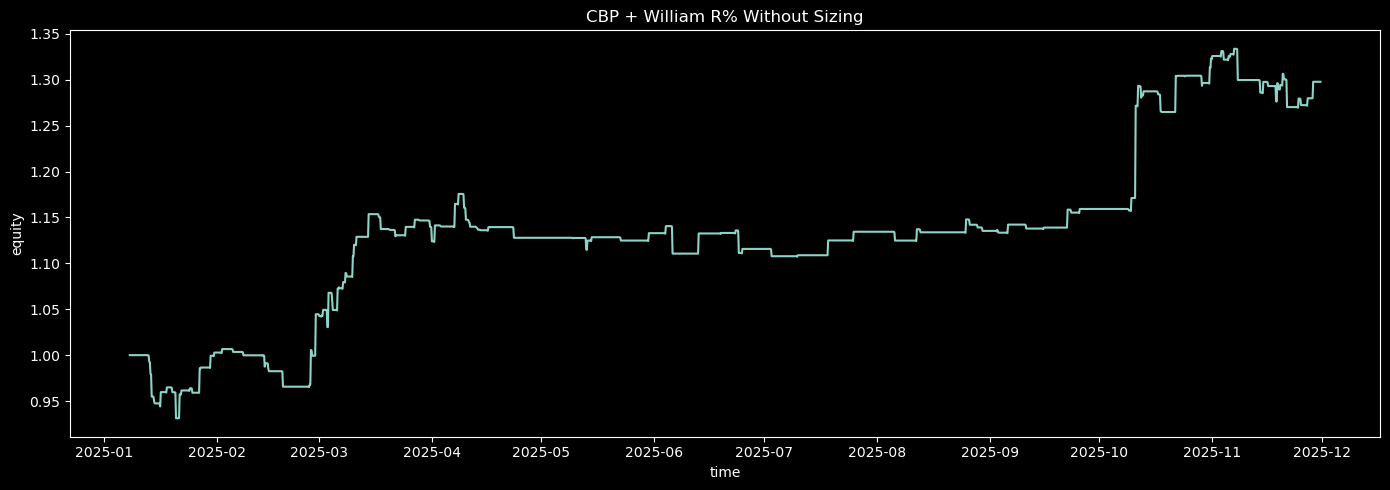

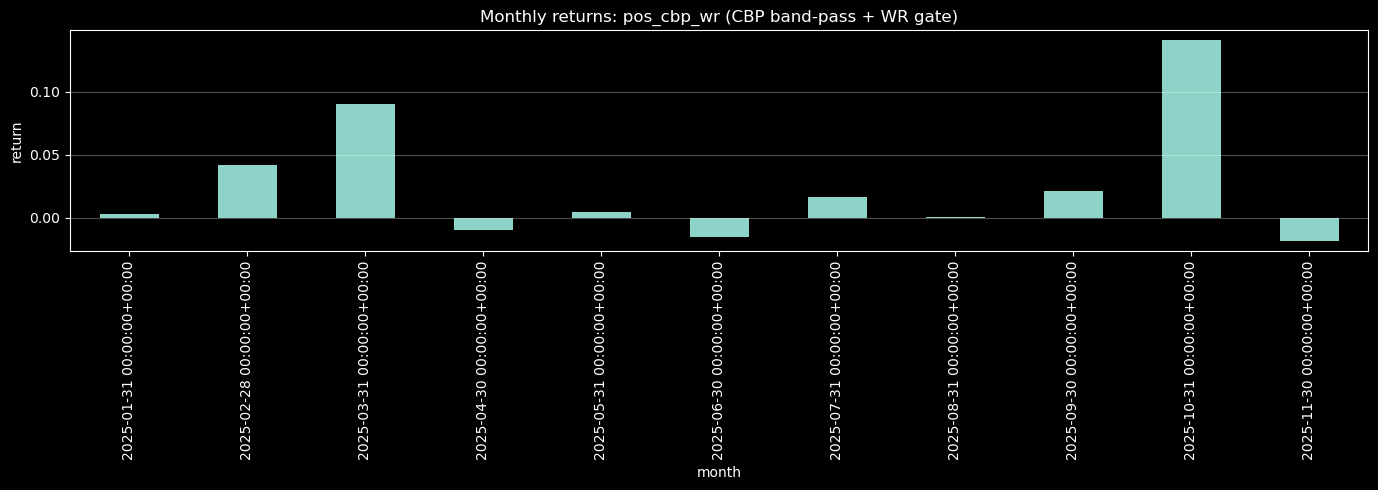

In [92]:
import matplotlib.pyplot as plt

# bigger equity curve
plt.figure(figsize=(14, 5))
plt.plot(eq_cbp_wr.index, eq_cbp_wr["equity"].values)
plt.title("CBP + William R% Without Sizing")
plt.xlabel("time")
plt.ylabel("equity")
plt.grid(True, alpha=0.0)
plt.tight_layout()
plt.show()

# bigger monthly returns bar chart
plt.figure(figsize=(14, 5))
monthly_ret.plot(kind="bar")
plt.title("Monthly returns: pos_cbp_wr (CBP band-pass + WR gate)")
plt.xlabel("month")
plt.ylabel("return")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.style.use("dark_background")

def _final_equity_from_params(q_base,
                              L=20, floor=0.3, alpha=2.5, thr=0.2, L0=1.0, Lmax=4.0,
                              fee_taker=0.0004, slip=0.0001, sl_atr_n=1, tp_atr_n=2):
    # build position with your exact BTC structure
    q = build_pos_ztanh_leverage(q_base, L=L, floor=floor, alpha=alpha, thr=thr, L0=L0, Lmax=Lmax)
    eq, tr = backtest_atr_sl_tp_with_log_float(
        q, fee_taker=fee_taker, slip=slip, sl_atr_n=sl_atr_n, tp_atr_n=tp_atr_n
    )
    return float(eq["equity"].iloc[-1])

def plot_param_surface_thr_Lmax_BTC(
    q_base,
    thr_grid=None,
    Lmax_grid=None,
    *,
    # keep all your other parameters fixed (BTC structure)
    L=20, floor=0.3, alpha=2.5, L0=1.0,
    fee_taker=0.0004, slip=0.0001, sl_atr_n=1, tp_atr_n=2,
    title="Parameter Surface (Final Equity of BTCUSDT) — thr × Lmax",
):
    if thr_grid is None:
        thr_grid = np.linspace(0.05, 1.2, 17)
    if Lmax_grid is None:
        Lmax_grid = np.linspace(1.0, 6.0, 17)

    Z = np.full((len(Lmax_grid), len(thr_grid)), np.nan)

    # brute force grid (start small then increase resolution)
    for i, Lmax_ in enumerate(Lmax_grid):
        for j, thr_ in enumerate(thr_grid):
            Z[i, j] = _final_equity_from_params(
                q_base,
                L=L, floor=floor, alpha=alpha, thr=float(thr_), L0=L0, Lmax=float(Lmax_),
                fee_taker=fee_taker, slip=slip, sl_atr_n=sl_atr_n, tp_atr_n=tp_atr_n
            )

    T, Lm = np.meshgrid(thr_grid, Lmax_grid)

    fig = plt.figure(figsize=(14, 7), facecolor="black")
    ax = fig.add_subplot(111, projection="3d", facecolor="black")

    # grey panes + white grid = “quant terminal” vibe
    try:
        ax.xaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
        ax.yaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
        ax.zaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
    except Exception:
        pass

    ax.grid(True, alpha=0.35)

    surf = ax.plot_surface(
        T, Lm, Z,
        cmap=cm.viridis,      # continuous gradient looks great on black
        linewidth=0,
        antialiased=True,
        alpha=0.98
    )

    ax.set_title(title, pad=16)
    ax.set_xlabel("thr (z threshold)")
    ax.set_ylabel("Lmax (max leverage)")
    ax.set_zlabel("Final Equity")

    cbar = fig.colorbar(surf, shrink=0.65, aspect=14, pad=0.08)
    cbar.set_label("Final Equity", rotation=90)

    plt.tight_layout()
    plt.show()

    return (thr_grid, Lmax_grid, Z)

In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.style.use("dark_background")

def _ztanh_leverage_pos_from_qbase(q_base, L=20, floor=0.3, alpha=2.5, thr=0.2, L0=1.0, Lmax=4.0,
                                  cbp_excess_col="cbp_excess_4h", gate_col="gate", dir_col=None):
    """
    Rebuild pos like your BTC structure:
      - zscore on cbp_excess
      - z–tanh size -> leverage
      - direction = sign(cbp_excess.shift(1)) unless dir_col provided
      - pos = gate * direction * leverage
    """
    q = q_base.copy()

    x = q[cbp_excess_col].astype(float)
    m = x.rolling(L, min_periods=L).mean()
    s = x.rolling(L, min_periods=L).std(ddof=0)
    z = (x - m) / s

    a = (z.abs() - thr).clip(lower=0.0)
    size = floor + (1.0 - floor) * np.tanh(alpha * a)
    lev = L0 + (Lmax - L0) * size

    if dir_col is None:
        direction = np.sign(x.shift(1)).replace(0, np.nan)
    else:
        direction = q[dir_col].astype(float)

    gate = q[gate_col].astype(float) if gate_col in q.columns else 1.0

    q["pos"] = (gate * direction * lev).fillna(0.0)
    return q

def plot_param_surface_thr_Lmax_BTC_fallback(
    q_base,
    thr_grid=None,
    Lmax_grid=None,
    *,
    L=20, floor=0.3, alpha=2.5, L0=1.0,
    fee_taker=0.0004, slip=0.0001, sl_atr_n=1, tp_atr_n=2,
    title="Parameter Surface (Final Equity of BTCUSDT) — thr × Lmax"
):
    if thr_grid is None:
        thr_grid = np.linspace(0.05, 1.2, 17)
    if Lmax_grid is None:
        Lmax_grid = np.linspace(1.0, 6.0, 17)

    Z = np.full((len(Lmax_grid), len(thr_grid)), np.nan)

    for i, Lmax_ in enumerate(Lmax_grid):
        for j, thr_ in enumerate(thr_grid):
            q = _ztanh_leverage_pos_from_qbase(
                q_base, L=L, floor=floor, alpha=alpha, thr=float(thr_), L0=L0, Lmax=float(Lmax_)
            )
            eq, tr = backtest_atr_sl_tp_with_log_float(
                q, fee_taker=fee_taker, slip=slip, sl_atr_n=sl_atr_n, tp_atr_n=tp_atr_n
            )
            Z[i, j] = float(eq["equity"].iloc[-1])

    T, Lm = np.meshgrid(thr_grid, Lmax_grid)

    fig = plt.figure(figsize=(14, 7), facecolor="black")
    ax = fig.add_subplot(111, projection="3d", facecolor="black")

    # quanty grey panes
    try:
        ax.xaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
        ax.yaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
        ax.zaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
    except Exception:
        pass

    ax.grid(True, alpha=0.35)

    surf = ax.plot_surface(T, Lm, Z, cmap=cm.viridis, linewidth=0, antialiased=True, alpha=0.98)

    ax.set_title(title, pad=16)
    ax.set_xlabel("thr (z threshold)")
    ax.set_ylabel("Lmax (max leverage)")
    ax.set_zlabel("Final Equity")

    cbar = fig.colorbar(surf, shrink=0.65, aspect=14, pad=0.08)
    cbar.set_label("Final Equity", rotation=90)

    plt.tight_layout()
    plt.show()

    return thr_grid, Lmax_grid, Z


In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.style.use("dark_background")

# ---------- 1) normalize OHLC names ----------
def ensure_ohlc(df: pd.DataFrame) -> pd.DataFrame:
    d = df.copy()

    # CLOSE
    if "close" not in d.columns:
        for c in ["okx_close_4h", "okx_close_1h", "okx_close", "Close", "close_4h", "close_1h"]:
            if c in d.columns:
                d = d.rename(columns={c: "close"})
                break

    # OPEN/HIGH/LOW
    for base in ["open", "high", "low"]:
        if base not in d.columns:
            for alt in [f"okx_{base}_4h", f"{base}_4h", base.capitalize()]:
                if alt in d.columns:
                    d = d.rename(columns={alt: base})
                    break

    missing = [c for c in ["open","high","low","close"] if c not in d.columns]
    if missing:
        raise ValueError(f"Missing OHLC columns after normalization: {missing}\nColumns: {list(df.columns)}")
    return d


# ---------- 2) ATR + backtest (self-contained) ----------
def atr_wilder(df: pd.DataFrame, n: int = 14) -> pd.Series:
    h, l, c = df["high"], df["low"], df["close"]
    pc = c.shift(1)
    tr = pd.concat([(h-l), (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1/n, adjust=False, min_periods=n).mean()

def backtest_atr_sl_tp_with_log_float(
    q: pd.DataFrame,
    fee_taker=0.0004,
    slip=0.0001,
    atr_n=14,
    sl_atr_n=1.0,
    tp_atr_n=2.0,
):
    d = ensure_ohlc(q).copy()
    if "pos" not in d.columns:
        raise ValueError("Backtest expects column 'pos' (executed position series).")

    d = d.dropna(subset=["open","high","low","close","pos"]).sort_index()
    d["atr"] = atr_wilder(d, atr_n)

    equity = 1.0
    eq_list = []
    trades = []

    pos = 0.0
    ref_px = np.nan  # mark price reference for MTM
    entry_px = np.nan

    for ts, r in d.iterrows():
        o, h, l, c = float(r["open"]), float(r["high"]), float(r["low"]), float(r["close"])
        atr = float(r["atr"]) if np.isfinite(r["atr"]) else np.nan
        target = float(r["pos"])

        # init reference
        if not np.isfinite(ref_px):
            ref_px = o

        # rebalance at open
        if target != pos:
            # close old at open
            if pos != 0.0:
                exit_px = o * (1.0 - slip*np.sign(pos))
                equity *= (1.0 + pos * (exit_px/ref_px - 1.0))
                equity *= (1.0 - fee_taker*abs(pos))
                trades.append({"ts": ts, "type": "signal_exit", "pos": pos, "px": exit_px, "equity": equity})
                pos = 0.0
                ref_px = exit_px
                entry_px = np.nan

            # open new at open
            if target != 0.0:
                entry_px = o * (1.0 + slip*np.sign(target))
                equity *= (1.0 - fee_taker*abs(target))
                trades.append({"ts": ts, "type": "signal_entry", "pos": target, "px": entry_px, "equity": equity})
                pos = target
                ref_px = entry_px

        # SL/TP intrabar (conservative: if both hit, take SL)
        if pos != 0.0 and np.isfinite(entry_px) and np.isfinite(atr) and atr > 0:
            if pos > 0:
                sl = entry_px - sl_atr_n*atr
                tp = entry_px + tp_atr_n*atr
                hit_sl = (l <= sl)
                hit_tp = (h >= tp)
                trig = sl if hit_sl else (tp if hit_tp else None)
                reason = "stop" if hit_sl else ("take" if hit_tp else None)
            else:
                sl = entry_px + sl_atr_n*atr
                tp = entry_px - tp_atr_n*atr
                hit_sl = (h >= sl)
                hit_tp = (l <= tp)
                trig = sl if hit_sl else (tp if hit_tp else None)
                reason = "stop" if hit_sl else ("take" if hit_tp else None)

            if trig is not None:
                exit_px = float(trig) * (1.0 - slip*np.sign(pos))
                equity *= (1.0 + pos * (exit_px/ref_px - 1.0))
                equity *= (1.0 - fee_taker*abs(pos))
                trades.append({"ts": ts, "type": reason, "pos": pos, "px": exit_px, "equity": equity})
                pos = 0.0
                entry_px = np.nan
                ref_px = exit_px

        # MTM to close
        if pos != 0.0:
            equity *= (1.0 + pos * (c/ref_px - 1.0))
            ref_px = c

        eq_list.append(equity)

    eq = pd.DataFrame({"equity": eq_list}, index=d.index)
    tr = pd.DataFrame(trades)
    return eq, tr


# ---------- 3) build z–tanh leverage pos (BTC structure) ----------
def build_pos_ztanh_leverage_from_qbase(
    q_base: pd.DataFrame,
    L=20, floor=0.3, alpha=2.5, thr=0.2,
    L0=1.0, Lmax=4.0,
    gate_col="gate",
    # Prefer your already-shifted signal if present:
    sig_col_prefer=("cbp_excess_sig_4h", "cbp_excess_sig", "cbp_sig"),
    # For zscore base:
    z_base_col_prefer=("cbp_excess_4h", "cbp_excess", "cbp_raw_4h", "cbp_raw"),
):
    q = ensure_ohlc(q_base).copy()

    # pick signal col (already shifted) if exists, else derive from z_base
    sig_col = next((c for c in sig_col_prefer if c in q.columns), None)
    z_base_col = next((c for c in z_base_col_prefer if c in q.columns), None)
    if z_base_col is None:
        raise ValueError(f"Can't find CBP column for zscore. Have: {list(q.columns)}")

    if sig_col is None:
        sig = q[z_base_col].astype(float).shift(1)
    else:
        sig = q[sig_col].astype(float)

    # gate (optional)
    gate = q[gate_col].astype(float) if gate_col in q.columns else 1.0

    # zscore on unshifted base, then shift(1) to trade next bar
    x = q[z_base_col].astype(float)
    m = x.rolling(L, min_periods=L).mean()
    s = x.rolling(L, min_periods=L).std(ddof=0)
    z = ((x - m) / s).shift(1)

    a = (z.abs() - thr).clip(lower=0.0)
    size = floor + (1.0 - floor) * np.tanh(alpha * a)
    lev = L0 + (Lmax - L0) * size

    direction = np.sign(sig).replace(0, np.nan)

    q["z"] = z
    q["pos"] = (gate * direction * lev).fillna(0.0)
    return q


# ---------- 4) black quant 3D surface thr × Lmax ----------
def plot_param_surface_thr_Lmax_BTC(
    q_base,
    thr_grid=np.linspace(0.05, 1.2, 17),
    Lmax_grid=np.linspace(1.0, 6.0, 17),
    *,
    L=20, floor=0.3, alpha=2.5, L0=1.0,
    fee_taker=0.0004, slip=0.0001, sl_atr_n=1, tp_atr_n=2,
    title="Parameter Surface (Final Equity of BTCUSDT PERP) — thr × Lmax"
):
    Z = np.full((len(Lmax_grid), len(thr_grid)), np.nan)

    for i, Lmax_ in enumerate(Lmax_grid):
        for j, thr_ in enumerate(thr_grid):
            q = build_pos_ztanh_leverage_from_qbase(
                q_base, L=L, floor=floor, alpha=alpha, thr=float(thr_),
                L0=L0, Lmax=float(Lmax_)
            )
            eq, tr = backtest_atr_sl_tp_with_log_float(
                q, fee_taker=fee_taker, slip=slip, sl_atr_n=sl_atr_n, tp_atr_n=tp_atr_n
            )
            Z[i, j] = float(eq["equity"].iloc[-1])

    T, Lm = np.meshgrid(thr_grid, Lmax_grid)

    fig = plt.figure(figsize=(14, 7), facecolor="black")
    ax = fig.add_subplot(111, projection="3d", facecolor="black")

    # quant grey panes + clean grid
    ax.xaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
    ax.yaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
    ax.zaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
    ax.grid(True, alpha=0.35)

    surf = ax.plot_surface(
        T, Lm, Z,
        cmap=cm.viridis,
        linewidth=0,
        antialiased=True,
        alpha=0.98
    )

    ax.set_title(title, pad=16)
    ax.set_xlabel("thr (z threshold)")
    ax.set_ylabel("Lmax (max leverage)")
    ax.set_zlabel("Final Equity")

    cbar = fig.colorbar(surf, shrink=0.65, aspect=14, pad=0.08)
    cbar.set_label("Final Equity", rotation=90)

    plt.tight_layout()
    plt.show()

    return thr_grid, Lmax_grid, Z

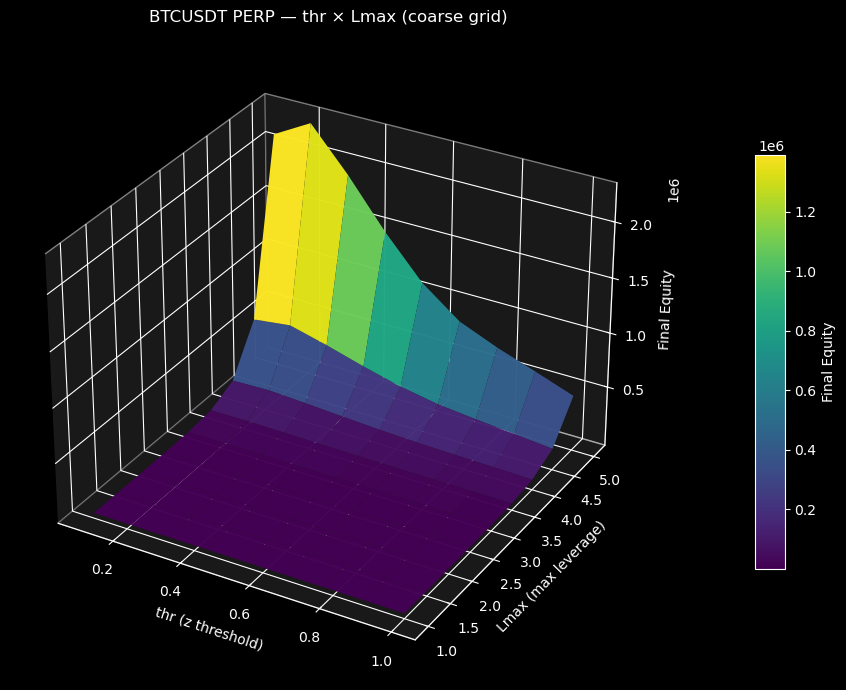

In [60]:
thr_grid  = np.linspace(0.1, 1.0, 9)      # 9
Lmax_grid = np.linspace(1.0, 5.0, 9)      # 9  -> 81 runs total

thr_grid, Lmax_grid, Z = plot_param_surface_thr_Lmax_BTC(
    q_base,
    thr_grid=thr_grid,
    Lmax_grid=Lmax_grid,
    L=20, floor=0.3, alpha=2.5, L0=1.0,
    fee_taker=0.0004, slip=0.0001, sl_atr_n=1, tp_atr_n=2,
    title="BTCUSDT PERP — thr × Lmax (coarse grid)"
)

In [61]:
def backtest_mtm_fast(q, fee_taker=0.0004, slip=0.0001):
    d = ensure_ohlc(q).copy()
    d = d.dropna(subset=["close","pos"]).sort_index()
    ret = d["close"].pct_change().fillna(0.0).to_numpy()
    pos = d["pos"].fillna(0.0).to_numpy()

    # cost on exposure changes (rebalance)
    dpos = np.abs(np.diff(pos, prepend=0.0))
    cost = dpos * (fee_taker + slip)

    eq = np.empty(len(d))
    e = 1.0
    for i in range(len(d)):
        e *= (1.0 + pos[i] * ret[i])
        e *= (1.0 - cost[i])
        eq[i] = e
    out = pd.DataFrame({"equity": eq}, index=d.index)
    return out

def plot_param_surface_thr_Lmax_BTC_FAST(
    q_base,
    thr_grid,
    Lmax_grid,
    *,
    L=20, floor=0.3, alpha=2.5, L0=1.0,
    fee_taker=0.0004, slip=0.0001,
    title="BTCUSDT PERP — thr × Lmax (FAST MTM surface)"
):
    Z = np.full((len(Lmax_grid), len(thr_grid)), np.nan)
    for i, Lmax_ in enumerate(Lmax_grid):
        for j, thr_ in enumerate(thr_grid):
            q = build_pos_ztanh_leverage_from_qbase(
                q_base, L=L, floor=floor, alpha=alpha, thr=float(thr_),
                L0=L0, Lmax=float(Lmax_)
            )
            eq = backtest_mtm_fast(q, fee_taker=fee_taker, slip=slip)
            Z[i, j] = float(eq["equity"].iloc[-1])

    T, Lm = np.meshgrid(thr_grid, Lmax_grid)
    fig = plt.figure(figsize=(13, 7), facecolor="black")
    ax = fig.add_subplot(111, projection="3d", facecolor="black")
    ax.xaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
    ax.yaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
    ax.zaxis.pane.set_facecolor((0.20, 0.20, 0.20, 1.0))
    ax.grid(True, alpha=0.35)

    surf = ax.plot_surface(T, Lm, Z, cmap=cm.viridis, linewidth=0, antialiased=True, alpha=0.98)
    ax.set_title(title, pad=16)
    ax.set_xlabel("thr")
    ax.set_ylabel("Lmax")
    ax.set_zlabel("Final Equity")
    fig.colorbar(surf, shrink=0.65, aspect=14, pad=0.08)
    plt.tight_layout()
    plt.show()
    return Z

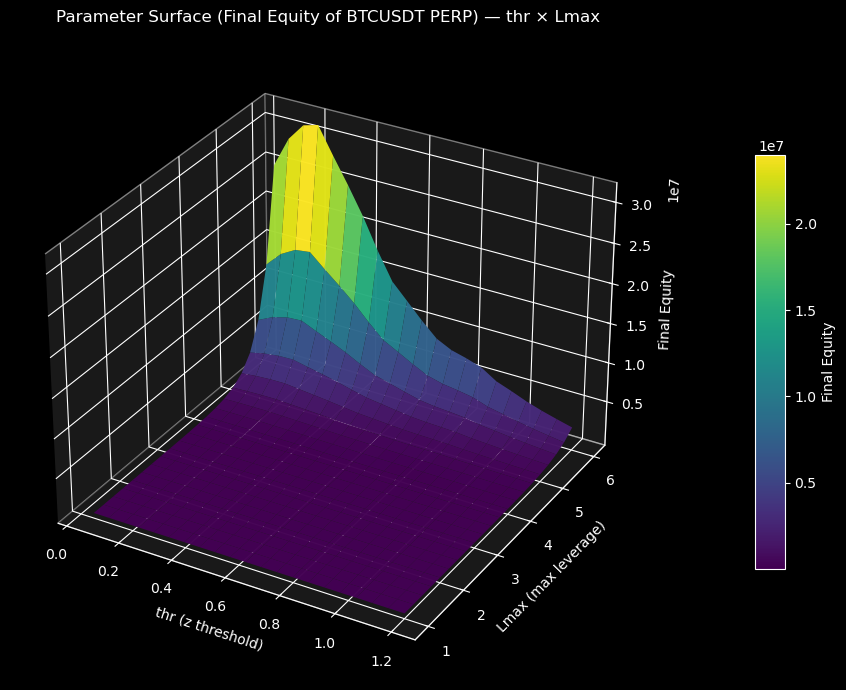

In [62]:
thr_grid = np.linspace(0.05, 1.2, 21)
Lmax_grid = np.linspace(1.0, 6.0, 21)

thr_grid, Lmax_grid, Z = plot_param_surface_thr_Lmax_BTC(
    q_base,
    thr_grid=thr_grid,
    Lmax_grid=Lmax_grid,
    L=20, floor=0.3, alpha=2.5, L0=1.0,
    fee_taker=0.0004, slip=0.0001, sl_atr_n=1, tp_atr_n=2,
    title="Parameter Surface (Final Equity of BTCUSDT PERP) — thr × Lmax"
)

### Position Sizing

- $\text{size}(z)=\text{floor}+(1-\text{floor})\cdot\tanh\Big(\alpha\cdot\max(|z|-\text{thr},0)\Big)$

In [70]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_eq_and_monthly(eq, title="Equity curve", figsize=(14, 5)):
    """
    eq: DataFrame with DatetimeIndex and an 'equity' column (your backtest output).
    Plots equity curve + monthly returns.
    """
    if "equity" not in eq.columns:
        raise KeyError("eq must contain an 'equity' column.")

    e = eq["equity"].astype(float).copy()

    # ensure datetime index
    if not isinstance(e.index, pd.DatetimeIndex):
        e.index = pd.to_datetime(e.index)

    # monthly returns from end-of-month equity
    e_m = e.resample("M").last()
    r_m = e_m.pct_change().dropna()

    fig, ax = plt.subplots(1, 2, figsize=figsize)

    ax[0].plot(e.index, e.values)
    ax[0].set_title(f"{title} — Equity")
    ax[0].grid(True, alpha=0.3)

    ax[1].bar(r_m.index, r_m.values)
    ax[1].axhline(0.0, linewidth=1)
    ax[1].set_title("Monthly Returns (pct)")
    ax[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    return fig

Nonzero pos bars: 89
pos abs quantiles: 0.10    0.500000
0.50    0.500000
0.90    0.992481
0.99    0.999444
Name: pos, dtype: float64
z abs quantiles: 0.10    0.174847
0.50    0.755029
0.90    2.156336
0.99    2.934637
Name: z, dtype: float64
Z–tanh sizing | Final equity: 1.3363365413446575 Trades: 178


/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3574657910.py:24: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.0)


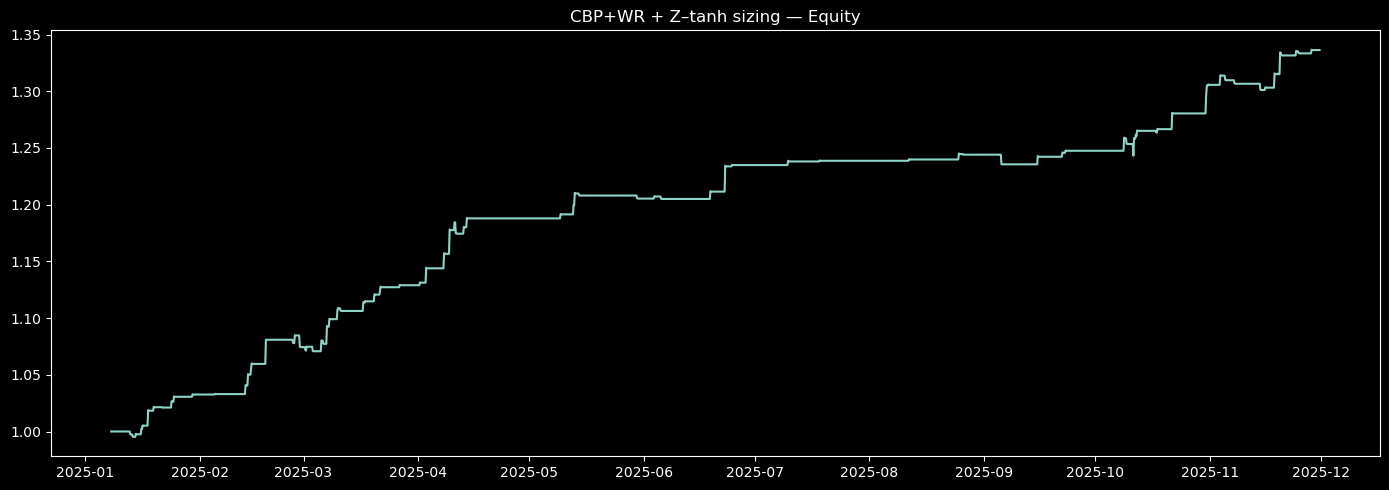

/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3574657910.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  e_m = e.resample("M").last()


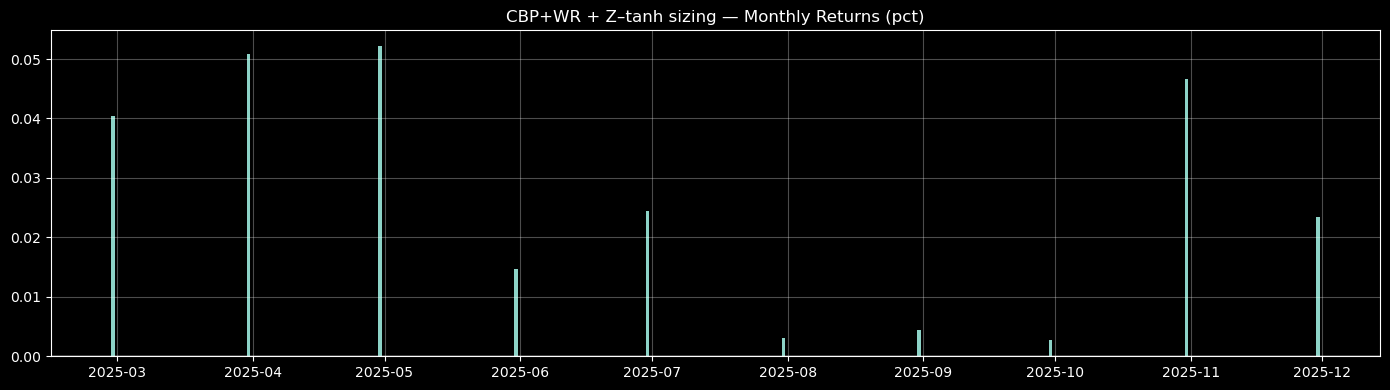

In [82]:
import numpy as np
import pandas as pd

def build_pos_ztanh(q_base,
                    # gates (your proven signal)
                    tau_lo=0.006, tau_hi=0.010,
                    wr_lo=-80, wr_hi=-20,
                    # z-score
                    L=30,   # rolling window in 4H bars (60=10 days)
                    # sizing params
                    floor=0.2, alpha=1.2, thr=0.8):
    q = q_base.copy().sort_index()

    # ensure UTC-aware index to avoid bugs
    if q.index.tz is None:
        q.index = q.index.tz_localize("UTC")
    else:
        q.index = q.index.tz_convert("UTC")

    ex = q["cbp_excess_sig_4h"].astype(float)
    dir_ = np.sign(ex)

    # gates
    band_gate = (ex.abs() >= tau_lo) & (ex.abs() <= tau_hi)
    wr_gate   = (q["wr"] > wr_lo) & (q["wr"] < wr_hi)
    gate = band_gate & wr_gate

    # z-score (shifted to avoid lookahead)
    mu = ex.rolling(L, min_periods=max(20, L//3)).mean()
    sd = ex.rolling(L, min_periods=max(20, L//3)).std(ddof=0)
    z = ((ex - mu) / (sd + 1e-12)).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    z_sig = z.shift(1).fillna(0.0)

    # z–tanh sizing
    az = np.abs(z_sig)
    size = floor + (1.0 - floor) * np.tanh(alpha * np.maximum(az - thr, 0.0))

    q["z"] = z_sig
    q["size"] = size

    q["pos"] = np.where(gate, dir_ * size, 0.0)
    return q


# ---- run ----
qZ = build_pos_ztanh(
    q_base,
    L=20,
    floor=0.5,
    alpha=1.8,
    thr=0.8
)

print("Nonzero pos bars:", int((qZ["pos"] != 0).sum()))
print("pos abs quantiles:", qZ.loc[qZ["pos"]!=0, "pos"].abs().quantile([0.1,0.5,0.9,0.99]))
print("z abs quantiles:", qZ.loc[qZ["pos"]!=0, "z"].abs().quantile([0.1,0.5,0.9,0.99]))

eqZ, trZ = backtest_atr_sl_tp_with_log_float(
    qZ, fee_taker=0.0004, slip=0.0001,
    sl_atr_n=1, tp_atr_n=2
)

print("Z–tanh sizing | Final equity:", float(eqZ["equity"].iloc[-1]), "Trades:", len(trZ))
plot_eq_and_monthly(eqZ, "CBP+WR + Z–tanh sizing", figsize=(14,5))

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_eq_and_monthly(eq, title="Equity curve", figsize=(14, 5), bar_figsize=(14, 4)):
    """
    eq: DataFrame with DatetimeIndex and an 'equity' column.
    Produces TWO separate plots:
      1) Equity curve
      2) Monthly returns bar chart
    """
    if "equity" not in eq.columns:
        raise KeyError("eq must contain an 'equity' column.")

    e = eq["equity"].astype(float).copy()

    # ensure datetime index
    if not isinstance(e.index, pd.DatetimeIndex):
        e.index = pd.to_datetime(e.index)

    # --- Plot 1: Equity curve (top) ---
    plt.figure(figsize=figsize)
    plt.plot(e.index, e.values)
    plt.title(f"{title} — Equity")
    plt.grid(False, alpha=0.0)
    plt.tight_layout()
    plt.show()

    # --- Plot 2: Monthly returns (bottom) ---
    e_m = e.resample("M").last()
    r_m = e_m.pct_change().dropna()

    plt.figure(figsize=bar_figsize)
    plt.bar(r_m.index, r_m.values)
    plt.axhline(0.0, linewidth=1)
    plt.title(f"{title} — Monthly Returns (pct)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [83]:
import numpy as np
import pandas as pd

# ---- metrics ----
def ann_sharpe_from_equity(eq, bars_per_year=365*6):  # 4H bars ~6 per day
    eq = eq.sort_index()
    r = np.log(eq["equity"]).diff().dropna()
    if len(r) < 10:
        return np.nan
    sd = r.std(ddof=0)
    if sd == 0:
        return np.nan
    return float(r.mean() / sd * np.sqrt(bars_per_year))


def eval_ztanh_once(q_base, L, floor, alpha, thr,
                    fee_taker=0.0004, slip=0.0001,
                    sl_atr_n=1, tp_atr_n=2,
                    min_trades=30):
    qZ = build_pos_ztanh(
        q_base,
        L=int(L),
        floor=float(floor),
        alpha=float(alpha),
        thr=float(thr)
    )

    eq, tr = backtest_atr_sl_tp_with_log_float(
        qZ,
        fee_taker=fee_taker, slip=slip,
        sl_atr_n=sl_atr_n, tp_atr_n=tp_atr_n
    )

    ntr = len(tr)
    if ntr < min_trades:
        return None

    final_eq = float(eq["equity"].iloc[-1])
    out = {
        "L": int(L),
        "floor": float(floor),
        "alpha": float(alpha),
        "thr": float(thr),
        "final_equity": final_eq,
        "total_return": final_eq - 1.0,
        "sharpe_ann": ann_sharpe_from_equity(eq),
        "trades": ntr
    }
    return out


# ---- parameter grids (edit as you like) ----
L_grid     = [20, 25, 30, 40, 60, 80]          # rolling window in 4H bars
floor_grid = [0.1, 0.2, 0.3, 0.5, 0.7]         # minimum size when gate on
alpha_grid = [0.6, 1.0, 1.4, 1.8, 2.5]         # tanh steepness
thr_grid   = [0.2, 0.5, 0.8, 1.0, 1.2, 1.5]    # z threshold

rows = []
for L in L_grid:
    for floor in floor_grid:
        for alpha in alpha_grid:
            for thr in thr_grid:
                out = eval_ztanh_once(
                    q_base, L, floor, alpha, thr,
                    fee_taker=0.0004, slip=0.0001,
                    sl_atr_n=1, tp_atr_n=2,
                    min_trades=30
                )
                if out is not None:
                    rows.append(out)

resZ = pd.DataFrame(rows).sort_values(["final_equity", "sharpe_ann"], ascending=False)


BEST: {'L': 40.0, 'floor': 0.7, 'alpha': 2.5, 'thr': 0.2, 'final_equity': 1.4388333040096914, 'total_return': 0.43883330400969145, 'sharpe_ann': 4.853585346156303, 'trades': 178.0}
Best Z–tanh | Final equity: 1.485394945492548 Trades: 178


/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3574657910.py:24: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.0)


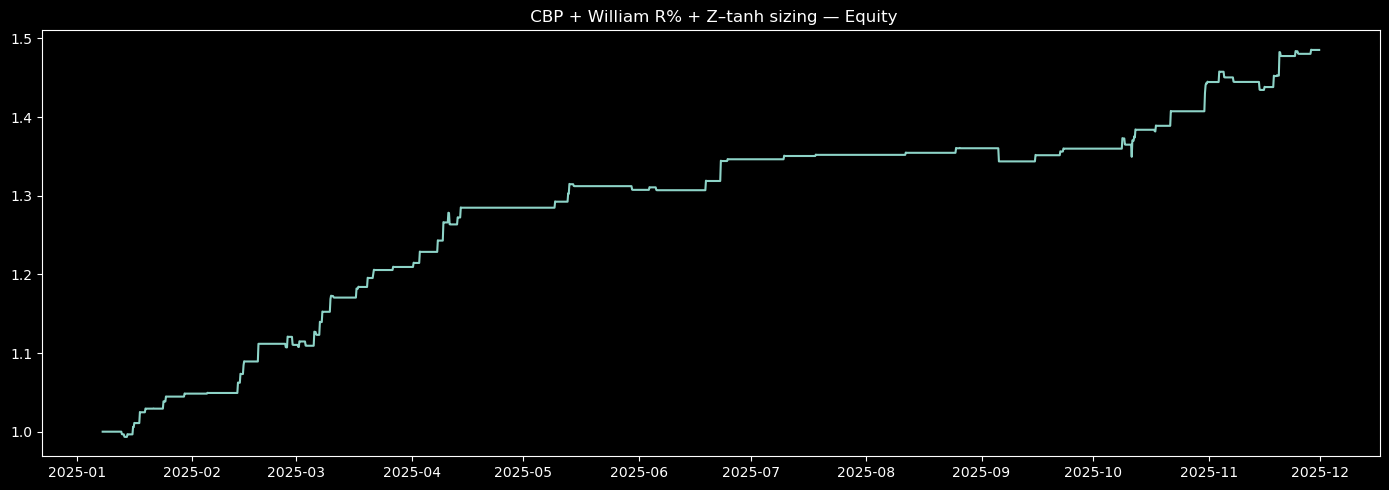

/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3574657910.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  e_m = e.resample("M").last()


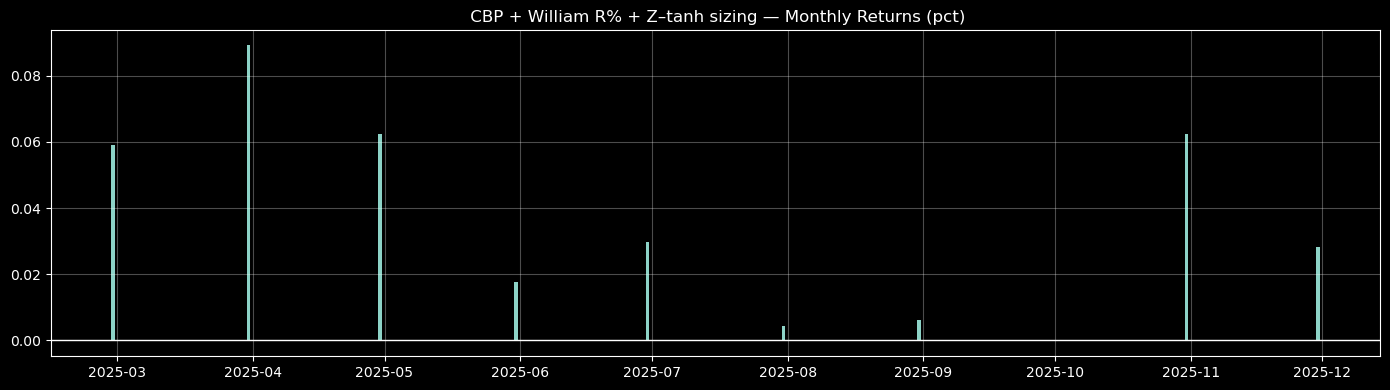

In [90]:
best = resZ.iloc[0].to_dict()
print("BEST:", best)

qBest = build_pos_ztanh(
    q_base,
    L=int(best["L"]),
    floor=float(best["floor"]),
    alpha=float(best["alpha"]),
    thr=float(best["thr"])
)

eqB, trB = backtest_atr_sl_tp_with_log_float(
    qBest, fee_taker=0.0002, slip=0.0001,
    sl_atr_n=1, tp_atr_n=2
)

print("Best Z–tanh | Final equity:", float(eqB["equity"].iloc[-1]), "Trades:", len(trB))
plot_eq_and_monthly(eqB, " CBP + William R% + Z–tanh sizing", figsize=(14,5))

In [86]:
q = q_base.copy().sort_index()
ex = q["cbp_excess_sig_4h"].astype(float)
dir_ = np.sign(ex)

# your gate
tau_lo, tau_hi = 0.006, 0.010
gate = (ex.abs() >= tau_lo) & (ex.abs() <= tau_hi) & (q["wr"] > -80) & (q["wr"] < -20)

# forward bet return x_t = sign(ex_t) * logret_{t+1}
ret_fwd = np.log(q["okx_close_4h"]).shift(-1) - np.log(q["okx_close_4h"])
x = (dir_ * ret_fwd)

# your z (match your best: L=20)
L=20
mu = ex.rolling(L, min_periods=10).mean()
sd = ex.rolling(L, min_periods=10).std(ddof=0)
z = ((ex - mu) / (sd + 1e-12)).shift(1)

tmp = pd.DataFrame({"zabs": z.abs(), "x": x}).loc[gate].dropna()

# Bin test: does higher |z| mean higher mean(x)?
bins = pd.qcut(tmp["zabs"], 5, duplicates="drop")
print(tmp.groupby(bins)["x"].agg(["count","mean","std"]))

# IC check (rank corr): should be >0 if z is a good strength proxy
print("Spearman corr(|z|, x):", tmp["zabs"].corr(tmp["x"], method="spearman"))

                 count      mean       std
zabs                                      
(0.0173, 0.288]     18  0.000344  0.010746
(0.288, 0.494]      18  0.001938  0.011619
(0.494, 0.889]      17  0.007080  0.010549
(0.889, 1.567]      18  0.003488  0.012454
(1.567, 3.563]      18  0.005425  0.014023
Spearman corr(|z|, x): 0.12432754511406198


/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/2966609867.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(tmp.groupby(bins)["x"].agg(["count","mean","std"]))


In [95]:
def build_pos_ztanh_leverage(q_base, L=20, floor=0.7, alpha=2.5, thr=0.2, L0=2.0, Lmax=2.0):
    q = q_base.copy().sort_index()
    if q.index.tz is None:
        q.index = q.index.tz_localize("UTC")
    else:
        q.index = q.index.tz_convert("UTC")

    ex = q["cbp_excess_sig_4h"].astype(float)
    dir_ = np.sign(ex)

    gate = (ex.abs() >= 0.006) & (ex.abs() <= 0.010) & (q["wr"] > -80) & (q["wr"] < -20)

    mu = ex.rolling(L, min_periods=10).mean()
    sd = ex.rolling(L, min_periods=10).std(ddof=0)
    z = ((ex - mu) / (sd + 1e-12)).shift(1).fillna(0.0)

    az = z.abs()
    # size in [floor, Lmax/L0]
    size = floor + (Lmax / L0 - floor) * np.tanh(alpha * np.maximum(az - thr, 0.0))
    lev = L0 * size

    q["pos"] = np.where(gate, dir_ * lev, 0.0)
    return q

Final equity: 3.6356647689535153 Trades: 178


/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3574657910.py:24: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.0)


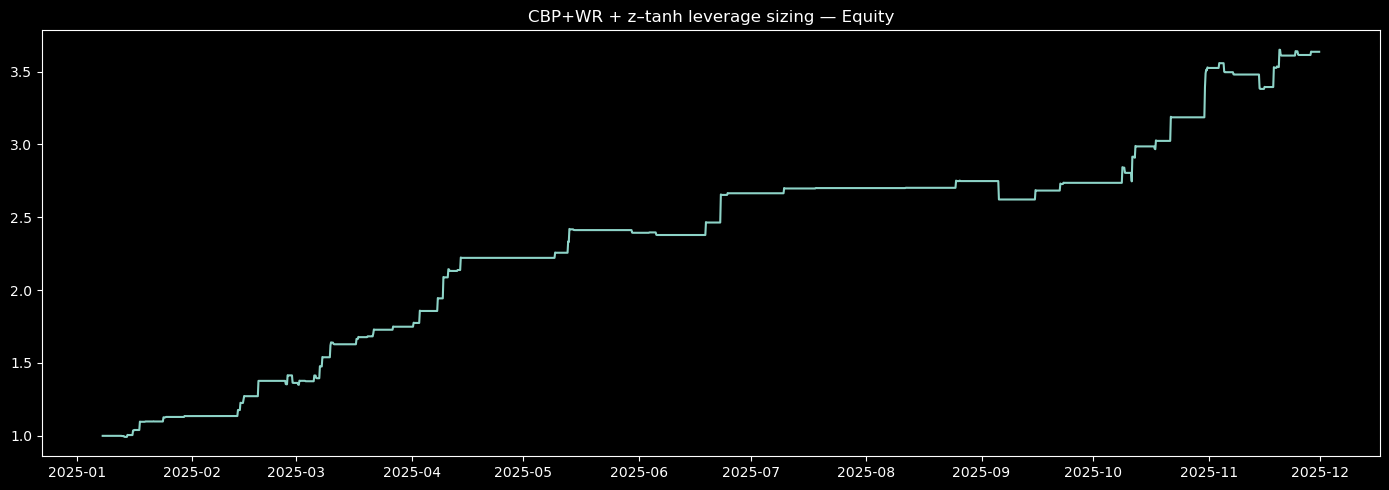

/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3574657910.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  e_m = e.resample("M").last()


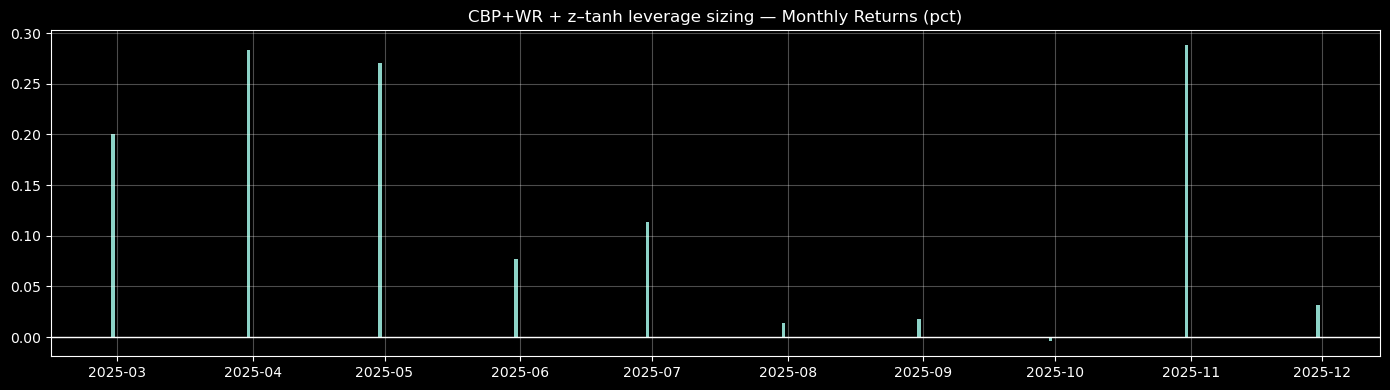

In [94]:
qZL = build_pos_ztanh_leverage(q_base, L=20, floor=0.3, alpha=2.5, thr=0.2, L0=1.0, Lmax=4.0)
eqZL, trZL = backtest_atr_sl_tp_with_log_float(qZL, fee_taker=0.0002, slip=0.0001, sl_atr_n=1, tp_atr_n=2)
print("Final equity:", float(eqZL["equity"].iloc[-1]), "Trades:", len(trZL))
plot_eq_and_monthly(eqZL, "CBP+WR + z–tanh leverage sizing", figsize=(14,5))

In [103]:
# --- benchmark close for Jensen alpha (OKX buy&hold) ---
bench = qZL["okx_close_4h"]   # your q has okx_close_4h, not "close"

# --- metrics (4H bars -> 6*365 per year) ---
print_metrics(
    eqZL,
    benchmark_close=bench,
    bars_per_year=6*365,
    rf_annual=0.0
)

Bars: 1959
Final equity: 3.635665
Sharpe (ann): 5.061
Sortino (ann): 17.543
Jensen alpha (ann): 1.445
Beta vs benchmark: 0.033
MDD: -4.982%


Final equity: 3.6356647689535153 Trades: 178


/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3574657910.py:24: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  plt.grid(False, alpha=0.0)


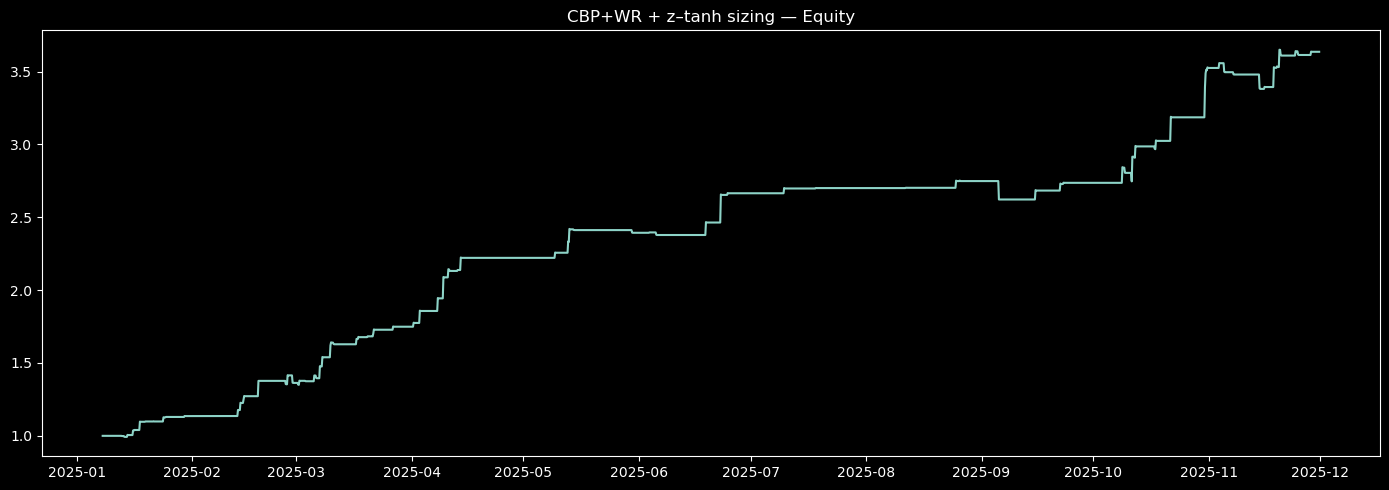

/var/folders/b6/fb60dc_d6bx6dt630rrghmbc0000gn/T/ipykernel_7050/3574657910.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  e_m = e.resample("M").last()


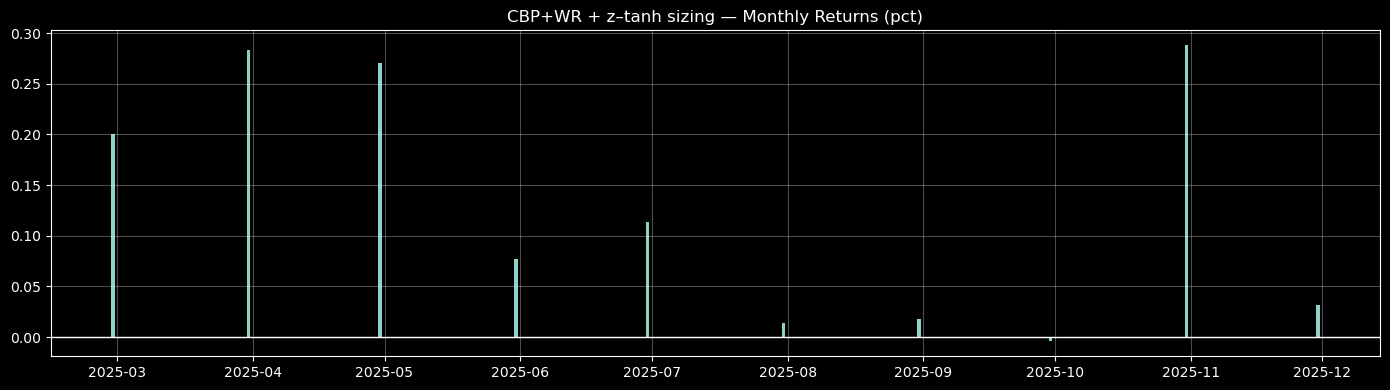

Bars: 1959
Final equity: 3.635665
Sharpe (ann): 5.061
Sortino (ann): 17.543
Jensen alpha (ann): 1.445
Beta vs benchmark: 0.033
MDD: -4.982%


In [105]:
print("Final equity:", float(eqZL["equity"].iloc[-1]), "Trades:", len(trZL))
plot_eq_and_monthly(eqZL, "CBP+WR + z–tanh sizing", figsize=(14,5))
print_metrics(eqZL, benchmark_close=qZL["okx_close_4h"], bars_per_year=6*365, rf_annual=0.0)

In [123]:
import matplotlib as mpl
import matplotlib.pyplot as plt

# IMPORTANT: do NOT use system LaTeX
mpl.rcParams["text.usetex"] = False

# Make math look more "LaTeX-y"
mpl.rcParams["mathtext.fontset"] = "stix"
mpl.rcParams["font.family"] = "STIXGeneral"

# Optional: default dark style for plots
mpl.rcParams["figure.facecolor"] = "black"
mpl.rcParams["axes.facecolor"]   = "black"
mpl.rcParams["axes.labelcolor"]  = "white"
mpl.rcParams["xtick.color"]      = "white"
mpl.rcParams["ytick.color"]      = "white"
mpl.rcParams["text.color"]       = "white"

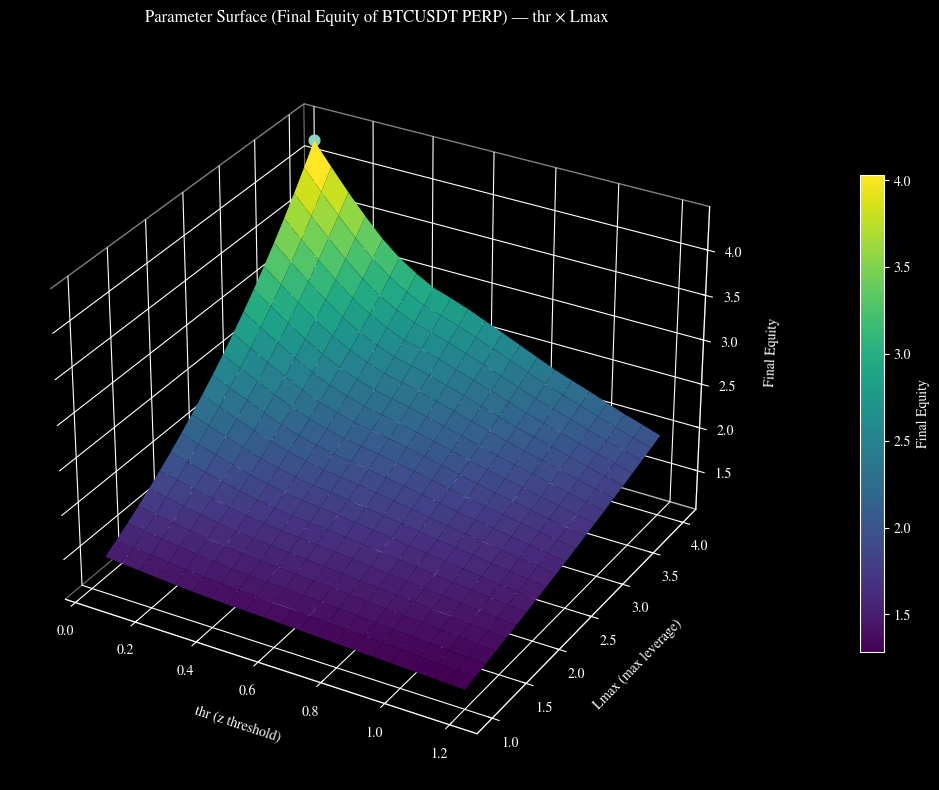

BEST: thr=0.0500, Lmax=4.00, final_equity=4.255907, trades=178


In [129]:
import numpy as np
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def plot_param_surface_thr_Lmax(
    q_base,
    thr_grid,
    Lmax_grid,
    *,
    L=20,
    floor=0.3,
    alpha=2.5,
    L0=1.0,
    fee_taker=0.0002,
    slip=0.0001,
    sl_atr_n=1,
    tp_atr_n=2,
    title="Parameter Surface (Final Equity) — thr × Lmax",
):
    thr_grid = np.asarray(thr_grid, dtype=float)
    Lmax_grid = np.asarray(Lmax_grid, dtype=float)

    Z = np.full((len(Lmax_grid), len(thr_grid)), np.nan, dtype=float)
    trades = np.zeros_like(Z)

    for i, Lmax in enumerate(Lmax_grid):
        for j, thr in enumerate(thr_grid):
            qZL = build_pos_ztanh_leverage(
                q_base, L=L, floor=floor, alpha=alpha, thr=float(thr), L0=L0, Lmax=float(Lmax)
            )
            eq, tr = backtest_atr_sl_tp_with_log_float(
                qZL, fee_taker=fee_taker, slip=slip, sl_atr_n=sl_atr_n, tp_atr_n=tp_atr_n
            )
            Z[i, j] = float(eq["equity"].iloc[-1])
            trades[i, j] = len(tr)

    # Mesh for plotting (X=thr, Y=Lmax)
    X, Y = np.meshgrid(thr_grid, Lmax_grid)

    # ---- Plot (dark theme) ----
    fig = plt.figure(figsize=(12, 8), facecolor="black")
    ax = fig.add_subplot(111, projection="3d", facecolor="black")

    surf = ax.plot_surface(X, Y, Z, cmap="viridis", linewidth=0, antialiased=True)

    ax.set_title(title, color="white", pad=18)
    ax.set_xlabel("thr (z threshold)", color="white", labelpad=10)
    ax.set_ylabel("Lmax (max leverage)", color="white", labelpad=10)
    ax.set_zlabel("Final Equity", color="white", labelpad=10)

    ax.tick_params(colors="white")

    # Make 3D panes black (not gray)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((0, 0, 0, 1.0))
        axis.pane.set_edgecolor((1, 1, 1, 0.25))

    cbar = fig.colorbar(surf, shrink=0.65, pad=0.1)
    cbar.set_label("Final Equity", color="white")
    cbar.ax.yaxis.set_tick_params(color="white")
    plt.setp(cbar.ax.get_yticklabels(), color="white")

    # Mark best point
    i_best, j_best = np.unravel_index(np.nanargmax(Z), Z.shape)
    best_thr = thr_grid[j_best]
    best_Lmax = Lmax_grid[i_best]
    best_eq = Z[i_best, j_best]
    ax.scatter([best_thr], [best_Lmax], [best_eq], s=60)

    plt.tight_layout()
    plt.show()

    print(f"BEST: thr={best_thr:.4f}, Lmax={best_Lmax:.2f}, final_equity={best_eq:.6f}, trades={int(trades[i_best,j_best])}")
    return X, Y, Z, trades


# --- Example usage (match your screenshot idea) ---
thr_grid  = np.linspace(0.05, 1.2, 21)
Lmax_grid = np.linspace(1.0, 4.0, 21)

X, Y, Z, trades = plot_param_surface_thr_Lmax(
    q_base,
    thr_grid,
    Lmax_grid,
    L=20, floor=0.3, alpha=2.5, L0=1.0,
    fee_taker=0.0002, slip=0.0001, sl_atr_n=1, tp_atr_n=2,
    title="Parameter Surface (Final Equity of BTCUSDT PERP) — thr × Lmax",
)

In [98]:
print(eqZ.columns)

Index(['equity'], dtype='object')


In [127]:
import numpy as np
import pandas as pd

def compute_metrics_from_equity(eq: pd.DataFrame,
                                benchmark_close: pd.Series = None,   # pass qZ["close"] (OKX close) for Jensen alpha
                                equity_col: str = "equity",
                                bars_per_year: int = 6*365,          # 4H bars in crypto
                                rf_annual: float = 0.0):             # set 0 unless you model rf
    if equity_col not in eq.columns:
        raise KeyError(f"eq must contain '{equity_col}' column, got {list(eq.columns)}")

    e = eq[equity_col].astype(float).copy()
    if not isinstance(e.index, pd.DatetimeIndex):
        e.index = pd.to_datetime(e.index)

    # --- per-bar log returns ---
    r = np.log(e).diff().dropna()

    # --- risk-free per bar ---
    rf_bar = rf_annual / bars_per_year
    ex = r - rf_bar

    # --- Sharpe (annualized) ---
    sharpe = np.nan
    vol = ex.std(ddof=0)
    if vol > 0:
        sharpe = (ex.mean() / vol) * np.sqrt(bars_per_year)

    # --- Sortino (annualized) ---
    sortino = np.nan
    downside = np.minimum(ex, 0.0)
    dd = np.sqrt(np.mean(downside**2))
    if dd > 0:
        sortino = (ex.mean() / dd) * np.sqrt(bars_per_year)

    # --- Max Drawdown (MDD) ---
    peak = e.cummax()
    dd_curve = e / peak - 1.0
    mdd = float(dd_curve.min())

    # --- Jensen alpha (annualized) + beta ---
    jensen_alpha = np.nan
    beta = np.nan
    if benchmark_close is not None:
        m = benchmark_close.astype(float).copy()
        if not isinstance(m.index, pd.DatetimeIndex):
            m.index = pd.to_datetime(m.index)
        rm = np.log(m).diff()

        df = pd.concat([r.rename("rp"), rm.rename("rm")], axis=1).dropna()
        if len(df) >= 20:
            y = (df["rp"] - rf_bar).values
            x = (df["rm"] - rf_bar).values
            x_var = np.mean((x - x.mean())**2)
            if x_var > 0:
                beta = np.mean((x - x.mean()) * (y - y.mean())) / x_var
                alpha_bar = y.mean() - beta * x.mean()
                jensen_alpha = float(alpha_bar * bars_per_year)

    return {
        "bars": int(len(r)),
        "final_equity": float(e.iloc[-1]),
        "Sharpe_ann": float(sharpe) if sharpe == sharpe else np.nan,
        "Sortino_ann": float(sortino) if sortino == sortino else np.nan,
        "MDD": mdd,
        "Jensen_alpha_ann": float(jensen_alpha) if jensen_alpha == jensen_alpha else np.nan,
        "beta_vs_benchmark": float(beta) if beta == beta else np.nan,
    }

def print_metrics(eq, benchmark_close=None, **kwargs):
    m = compute_metrics_from_equity(eq, benchmark_close=benchmark_close, **kwargs)
    print(f"Bars: {m['bars']}")
    print(f"Final equity: {m['final_equity']:.6f}")
    print(f"Sharpe (ann): {m['Sharpe_ann']:.3f}")
    print(f"Sortino (ann): {m['Sortino_ann']:.3f}")
    if benchmark_close is not None:
        print(f"Jensen alpha (ann): {m['Jensen_alpha_ann']:.3f}")
        print(f"Beta vs benchmark: {m['beta_vs_benchmark']:.3f}")
    print(f"MDD: {m['MDD']:.3%}")

In [101]:
print(qZ.columns)

Index(['open', 'high', 'low', 'okx_close_4h', 'vol', 'vol_ccy', 'vol_quote',
       'cb_close_4h', 'cbp_raw_4h', 'cbp_mu_4h', 'cbp_excess_4h',
       'cbp_excess_sig_4h', 'cbp_raw_sig_4h', 'hma_fast_close',
       'hma_slow_close', 'trend_close', 'hma_gap', 'ret_4h', 'event', 'pos_A',
       'pos_B', 'pos_C', 'pos_B_strong', 'pos_cbp', 'hh', 'll', 'wr',
       'pos_cbp_wr', 'pos_wr_only', 'z', 'size', 'pos'],
      dtype='object')


In [128]:
import numpy as np
import pandas as pd

def _infer_bar_returns_from_eq(eq: pd.DataFrame, equity_col="equity") -> pd.Series:
    if equity_col not in eq.columns:
        raise KeyError(f"eq must contain '{equity_col}' column.")
    e = eq[equity_col].astype(float).copy()
    if not isinstance(e.index, pd.DatetimeIndex):
        e.index = pd.to_datetime(e.index)
    # use log returns (stable for compounding)
    r = np.log(e).diff()
    return r.dropna()

def _infer_benchmark_returns(benchmark_close: pd.Series) -> pd.Series:
    px = benchmark_close.astype(float).copy()
    if not isinstance(px.index, pd.DatetimeIndex):
        px.index = pd.to_datetime(px.index)
    r = np.log(px).diff()
    return r.dropna()

def perf_metrics(eq: pd.DataFrame,
                 benchmark_close: pd.Series = None,
                 equity_col="equity",
                 bars_per_year=6*365,   # 4H bars in crypto: 6/day * 365
                 rf_annual=0.0,         # risk-free annual (set 0 unless you model it)
                 target_return=0.0      # Sortino target per-bar (0 is common)
                ) -> dict:

    r = _infer_bar_returns_from_eq(eq, equity_col=equity_col)

    # per-bar risk-free (approx)
    rf_bar = rf_annual / bars_per_year
    excess = r - rf_bar

    # Sharpe (annualized)
    sharpe = np.nan
    if excess.std(ddof=0) > 0:
        sharpe = (excess.mean() / excess.std(ddof=0)) * np.sqrt(bars_per_year)

    # Sortino (annualized) — downside deviation relative to target_return
    downside = np.minimum(r - target_return, 0.0)
    dd = np.sqrt(np.mean(downside**2))
    sortino = np.nan
    if dd > 0:
        sortino = ((r.mean() - target_return) / dd) * np.sqrt(bars_per_year)

    # Max Drawdown from equity curve
    e = eq[equity_col].astype(float).copy()
    if not isinstance(e.index, pd.DatetimeIndex):
        e.index = pd.to_datetime(e.index)
    peak = e.cummax()
    dd_curve = e / peak - 1.0
    mdd = float(dd_curve.min())

    # Jensen's alpha (CAPM regression vs benchmark) — annualized
    jensen_alpha = np.nan
    beta = np.nan
    if benchmark_close is not None:
        rm = _infer_benchmark_returns(benchmark_close)

        # align timestamps
        df = pd.concat([r.rename("rp"), rm.rename("rm")], axis=1).dropna()
        if len(df) >= 20:
            y = (df["rp"] - rf_bar).values
            x = (df["rm"] - rf_bar).values

            # OLS for y = a + b x
            x_mean = x.mean()
            y_mean = y.mean()
            var_x = np.mean((x - x_mean)**2)
            if var_x > 0:
                beta = np.mean((x - x_mean)*(y - y_mean)) / var_x
                alpha_bar = y_mean - beta * x_mean
                jensen_alpha = float(alpha_bar * bars_per_year)

    return {
        "Sharpe (ann.)": float(sharpe) if sharpe == sharpe else np.nan,
        "Sortino (ann.)": float(sortino) if sortino == sortino else np.nan,
        "Jensen alpha (ann.)": float(jensen_alpha) if jensen_alpha == jensen_alpha else np.nan,
        "Beta vs benchmark": float(beta) if beta == beta else np.nan,
        "Max Drawdown": mdd,
        "Bars": int(len(r)),
    }

def print_perf(eq, benchmark_close=None, **kwargs):
    m = perf_metrics(eq, benchmark_close=benchmark_close, **kwargs)
    print(f"Bars: {m['Bars']}")
    print(f"Sharpe (ann.): {m['Sharpe (ann.)']:.3f}")
    print(f"Sortino (ann.): {m['Sortino (ann.)']:.3f}")
    if benchmark_close is not None:
        print(f"Jensen alpha (ann.): {m['Jensen alpha (ann.)']:.3f}")
        print(f"Beta vs benchmark: {m['Beta vs benchmark']:.3f}")
    print(f"Max Drawdown: {m['Max Drawdown']:.3%}")

In [102]:
def pick_benchmark_close(df):
    for c in ["okx_close_4h", "okx_close_1h", "close", "okx_close"]:
        if c in df.columns:
            return df[c]
    raise KeyError(f"No close-like column found. Have: {list(df.columns)}")

bench = pick_benchmark_close(qZ)
print_metrics(eqZ, benchmark_close=bench, bars_per_year=6*365, rf_annual=0.0)

Bars: 1959
Final equity: 1.336337
Sharpe (ann): 4.831
Sortino (ann): 15.971
Jensen alpha (ann): 0.325
Beta vs benchmark: 0.007
MDD: -1.311%


#### Save to csv

In [287]:
# --- 1) Build one output table: qZL + equity curve ---
out = qZL.copy()
out = out.sort_index()

# merge equity (align on index)
eq = eqZL.copy().sort_index()
out = out.join(eq[["equity"]], how="left")

# optional: strategy log return per bar (from equity)
out["strat_logret"] = np.log(out["equity"]).diff()

# --- 2) Add trade markers (if your trZL is a DataFrame of trades) ---
# This block tries to be robust to different column names.
if isinstance(trZL, pd.DataFrame) and len(trZL) > 0:
    # guess entry/exit timestamp columns
    possible_entry_cols = ["entry_ts","entry_time","entry_dt","entry_time_utc","entry"]
    possible_exit_cols  = ["exit_ts","exit_time","exit_dt","exit_time_utc","exit"]

    entry_col = next((c for c in possible_entry_cols if c in trZL.columns), None)
    exit_col  = next((c for c in possible_exit_cols  if c in trZL.columns), None)

    if entry_col and exit_col:
        t = trZL.copy()

        # ensure timestamps are datetime (UTC)
        t[entry_col] = pd.to_datetime(t[entry_col], utc=True, errors="coerce")
        t[exit_col]  = pd.to_datetime(t[exit_col],  utc=True, errors="coerce")

        out["trade_entry"] = 0
        out["trade_exit"] = 0

        out.loc[out.index.isin(t[entry_col].dropna()), "trade_entry"] = 1
        out.loc[out.index.isin(t[exit_col].dropna()),  "trade_exit"] = 1

# --- 3) Save ---
save_path = "BTCUSDT-PERP backtest.csv"
out.to_csv(save_path, index=True, encoding="utf-8-sig")
print("Saved:", save_path, "| rows:", len(out), "| cols:", out.shape[1])

Saved: BTCUSDT-PERP backtest.csv | rows: 1960 | cols: 34


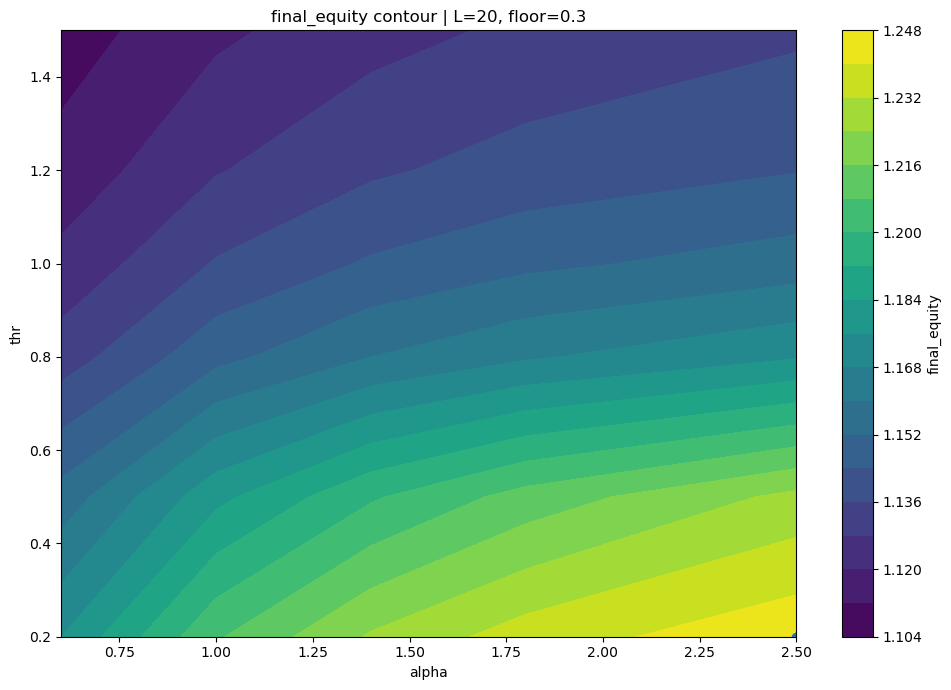

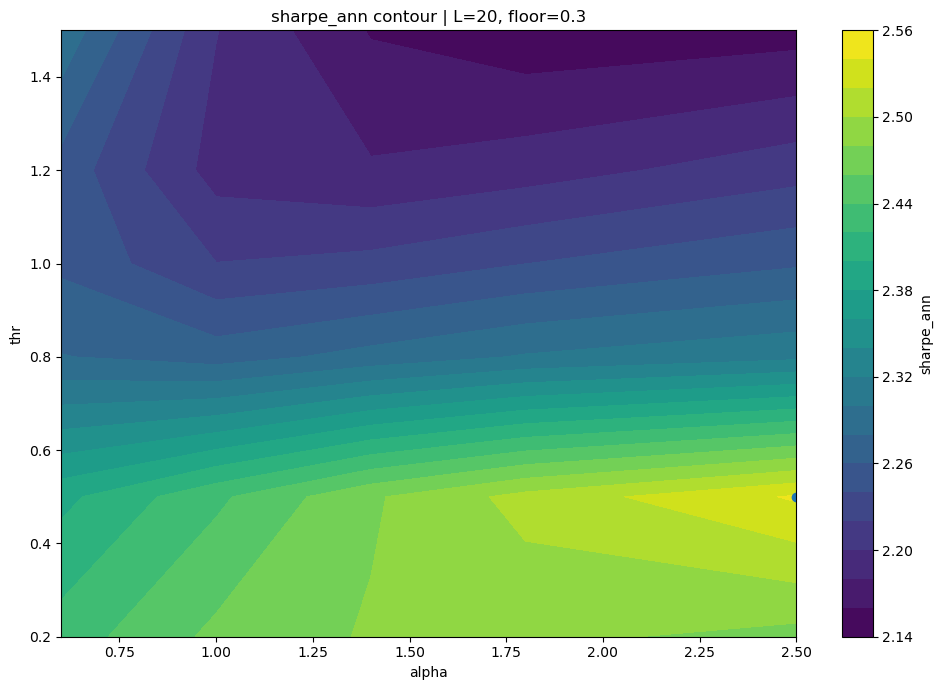

In [281]:
def contour_alpha_thr(resZ, L=20, floor=0.3, metric="final_equity"):
    d = resZ[(resZ["L"]==L) & (np.isclose(resZ["floor"], floor))].copy()
    if d.empty:
        print("No rows for L,floor =", L, floor); return

    piv = d.pivot(index="alpha", columns="thr", values=metric).sort_index().sort_index(axis=1)
    A = piv.index.values.astype(float)
    T = piv.columns.values.astype(float)
    AA, TT = np.meshgrid(A, T, indexing="ij")
    Z = piv.values.astype(float)

    plt.figure(figsize=(10, 7))
    cs = plt.contourf(AA, TT, Z, levels=20)
    plt.colorbar(cs, label=metric)

    best = np.nanargmax(Z)
    i, j = np.unravel_index(best, Z.shape)
    plt.scatter(AA[i, j], TT[i, j], marker="o")
    plt.xlabel("alpha"); plt.ylabel("thr")
    plt.title(f"{metric} contour | L={L}, floor={floor}")
    plt.tight_layout()
    plt.show()

contour_alpha_thr(resZ, L=20, floor=0.3, metric="final_equity")
contour_alpha_thr(resZ, L=20, floor=0.3, metric="sharpe_ann")


In [278]:
def stability_over_L(resZ, floor=0.7, metric="final_equity"):
    d = resZ[np.isclose(resZ["floor"], floor)].copy()
    if d.empty:
        print("No rows for floor =", floor); return

    # for each (alpha,thr), look at mean and std across L
    g = d.groupby(["alpha","thr"])[metric].agg(["mean","std","count"]).reset_index()
    g = g[g["count"] >= 3]  # require multiple L values

    # pick best by mean - lambda*std (robust objective)
    lam = 0.5
    g["robust_score"] = g["mean"] - lam*g["std"]
    g = g.sort_values("robust_score", ascending=False)

    print("Top robust candidates (mean - 0.5*std):")
    print(g.head(10))

stability_over_L(resZ, floor=0.7, metric="final_equity")


Top robust candidates (mean - 0.5*std):
    alpha  thr      mean       std  count  robust_score
24    2.5  0.2  1.270476  0.002645      6      1.269154
18    1.8  0.2  1.266466  0.001971      6      1.265480
25    2.5  0.5  1.263947  0.003817      6      1.262039
12    1.4  0.2  1.261735  0.001756      6      1.260857
19    1.8  0.5  1.256719  0.003488      6      1.254975
6     1.0  0.2  1.253847  0.001658      6      1.253018
13    1.4  0.5  1.250798  0.003112      6      1.249242
7     1.0  0.5  1.242979  0.002536      6      1.241711
0     0.6  0.2  1.240839  0.001238      6      1.240221
26    2.5  0.8  1.240081  0.005201      6      1.237480
